In [48]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.append(f"./../")

from qiskit import QuantumCircuit, transpile
import itertools
from qiskit.circuit.library import PauliEvolutionGate
from qiskit.quantum_info import Operator, Pauli, SparsePauliOp
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import expm
import os
import pandas as pd

from src.qwalk_dictionary import getOpsCirc
from src.graphs import StaticGraph
from src.misc import reduce_graph_space, graph_matchings_with_relabeling, graph_matchings_no_relabeling 
from src.graph_simplifier import build_matching_circuit_iteratively

import importlib # for reloading functions. can rid of later.
import src.graph_simplifier
import src.qwalk_dictionary
importlib.reload(src.graph_simplifier)
importlib.reload(src.qwalk_dictionary)
from src.graph_simplifier import build_matching_circuit_iteratively
from src.qwalk_dictionary import getOpsCirc


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [49]:
# Create output directory for plots
output_dir = "trotterization_plots"
os.makedirs(output_dir, exist_ok=True)

# Set up publication-quality plotting style
plt.rcParams.update({
    'font.size': 12,
    'font.family': 'serif',
    'axes.labelsize': 14,
    'axes.titlesize': 16,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 12,
    'figure.figsize': (8, 6),
    'lines.linewidth': 2,
    'lines.markersize': 8,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'text.usetex': False  # Set to True if you have LaTeX installed
})

In [ ]:


# Global storage for gate count data
gate_count_data = []


def build_matching_circuit_with_reduction(n_qubits, n_steps, delta_t, matchings):
    """
    Build quantum circuit using matching-based decomposition with space reduction.
    
    For each Trotter step:
        For each matching:
            1. Reduce the matching space
            2. For each reduced edge, get circuit and append to main circuit
    
    Args:
        n_qubits: Number of qubits
        n_steps: Number of Trotter steps
        delta_t: Time step size
        matchings: List of matchings, where each matching is a list of edges
        
    Returns:
        QuantumCircuit: Complete matching-based circuit with space reduction
    """    
    qc = QuantumCircuit(n_qubits)
    
    # Time per step
    dt = delta_t / n_steps
    
    for step in range(n_steps):
        for matching in matchings:
            # Convert matching to set of edges with proper string format
            edges_set = set()
            
            for edge in matching:
                node1, node2 = edge
                
                # Ensure they are strings
                if isinstance(node1, int):
                    z1 = format(node1, f'0{n_qubits}b')
                else:
                    z1 = str(node1).zfill(n_qubits)
                    
                if isinstance(node2, int):
                    z2 = format(node2, f'0{n_qubits}b')
                else:
                    z2 = str(node2).zfill(n_qubits)
                
                edges_set.add((z1, z2))
            
            # Reduce space for this matching
            reduced_edges, active_qubits = reduce_graph_space(edges_set)
            
            # For each reduced edge, get circuit and append
            for z1_reduced, z2_reduced in reduced_edges:
                # Handle single qubit case: just an RX gate
                if len(z1_reduced) == 1:
                    # Single qubit case: ('0', '1') or ('1', '0')
                    # This is a simple RX gate on the active qubit
                    # active_qubits[0] is the qubit index in the full register
                    target_qubit = active_qubits[0]
                    
                    # Apply RX gate to the target qubit
                    qc.rx(2 * dt, target_qubit)  # Factor of 2 matches getOpsCirc convention
                    # qc.barrier(label=f'M{matchings.index(matching)+1}')
                    
                elif len(z1_reduced) == 0:
                    # Edge case: no active qubits (shouldn't happen, but handle it)
                    continue
                    
                else:
                    # Multi-qubit case: use getOpsCirc
                    reduced_circ = getOpsCirc(z1_reduced, z2_reduced, 
                                             little_endian=True, param=dt)
                    
                    # Compose onto main circuit at active qubit positions
                    qc.compose(reduced_circ, qubits=active_qubits, inplace=True)
            # qc.barrier(label=f'M{matchings.index(matching)+1}')
    
    return qc


def build_pauli_circuit(n_qubits, n_steps, delta_t, hamiltonian):
    """
    Build quantum circuit using Pauli decomposition.
    
    Args:
        n_qubits: Number of qubits
        n_steps: Number of Trotter steps
        delta_t: Time step size
        hamiltonian: Hamiltonian matrix
        
    Returns:
        QuantumCircuit: Complete Pauli-based circuit
    """
    qc = QuantumCircuit(n_qubits)
    
    # Decompose Hamiltonian into Pauli basis
    pauli_strings = []
    coeffs = []
    
    for pauli_string in ["".join(p) for p in itertools.product("IXYZ", repeat=n_qubits)]:
        P = Pauli(pauli_string)
        P_op = Operator(P).data
        coeff = np.trace(P_op.conj().T @ hamiltonian) / (2**n_qubits)
        
        real_coeff = float(np.real(coeff))
        if not np.isclose(real_coeff, 0, atol=1e-10):
            pauli_strings.append(pauli_string)
            coeffs.append(real_coeff)
    
    # Build circuit with accumulated steps
    if coeffs:
        dt = delta_t / n_steps
        
        for step in range(n_steps):
            for pauli_string, coeff in zip(pauli_strings, coeffs):
                single_pauli_op = SparsePauliOp([pauli_string], [coeff])
                evo_gate = PauliEvolutionGate(single_pauli_op, time=dt)
                qc.append(evo_gate, range(n_qubits))
    
    return qc


def build_exact_circuit(n_qubits, delta_t, hamiltonian):
    """
    Build exact quantum circuit using matrix exponential.
    
    Args:
        n_qubits: Number of qubits
        delta_t: Total time
        hamiltonian: Hamiltonian matrix
        
    Returns:
        QuantumCircuit: Exact evolution circuit
    """
    qc = QuantumCircuit(n_qubits)
    
    # Compute exact evolution operator
    exact_op = expm(-1j * hamiltonian * delta_t)
    exact_operator = Operator(exact_op)
    
    # Add as unitary gate
    qc.unitary(exact_operator, range(n_qubits), label='exact_evolution')
    
    return qc


def analyze_and_plot(edges, title, output_dir="trotterization_plots", delta_t=0.1):
    """
    Analyze quantum time evolution errors and plot results.
    Compares matching with relabeling, matching without relabeling, and Pauli decomposition.
    
    Args:
        edges: Original graph edges (set of tuples of binary strings)
               Example: {('00','01'), ('00','10'), ('00','11')}
        title: Plot title
        output_dir: Directory to save plots (default: "trotterization_plots")
        delta_t: Time step size (default: 0.1)
        
    Example:
        edges = {('00','01'), ('00','10'), ('00','11')}
        analyze_and_plot(edges, "Tree Graph T4")
    """
    global gate_count_data
    
    # Create output directory if it doesn't exist
    import os
    os.makedirs(output_dir, exist_ok=True)
    
    n_steps_list = [1, 2, 5, 10, 20, 50, 100]
    
    print(f"\n{title}")
    print("="*60)
    print(f"Original edges: {edges}")
    
    # Create graph
    G = StaticGraph(edges)
    print(f"Number of qubits: {G.n_qubits}")
    
    # Display original graph
    print("\nOriginal Graph:")
    try:
        display(G.draw())
    except:
        print("(Graph display not available)")
    
    # Get matchings WITH relabeling
    matchings_with_relabel = graph_matchings_with_relabeling(edges)
    relabeled_edges = set()
    for m in matchings_with_relabel:
        relabeled_edges = relabeled_edges.union(m)
    
    print(f"\nMatchings WITH relabeling: {len(matchings_with_relabel)}")
    print(f"Matchings: {matchings_with_relabel}")
    print(f"Relabeled edges: {relabeled_edges}")
    
    # Get matchings WITHOUT relabeling
    matchings_no_relabel = graph_matchings_no_relabeling(edges)
    
    print(f"\nMatchings WITHOUT relabeling: {len(matchings_no_relabel)}")
    print(f"Matchings: {matchings_no_relabel}")

    # Infer number of qubits
    if relabeled_edges:
        first_edge = next(iter(relabeled_edges))
        n_qubits = len(first_edge[0])
    else:
        raise ValueError("No edges provided")
    
    print(f"Number of qubits: {n_qubits}")
    
    # Calculate total Hamming costs
    def calculate_total_hamming_cost(edge_set):
        """Calculate total Hamming distance for all edges in the set"""
        total_cost = 0
        for edge in edge_set:
            v1, v2 = edge
            hamming_dist = sum(c1 != c2 for c1, c2 in zip(v1, v2))
            total_cost += hamming_dist
        return total_cost
    
    hamming_cost_relabel = calculate_total_hamming_cost(relabeled_edges)
    hamming_cost_no_relabel = calculate_total_hamming_cost(edges)
    
    # Calculate per-edge costs
    num_edges_relabel = len(relabeled_edges)
    num_edges_no_relabel = len(edges)
    
    hamming_per_edge_relabel = hamming_cost_relabel / num_edges_relabel if num_edges_relabel > 0 else 0
    hamming_per_edge_no_relabel = hamming_cost_no_relabel / num_edges_no_relabel if num_edges_no_relabel > 0 else 0
    
    print(f"\nHamming Cost Analysis:")
    print(f"With Relabeling: Total = {hamming_cost_relabel}, Edges = {num_edges_relabel}, Per Edge = {hamming_per_edge_relabel:.3f}")
    print(f"No Relabeling: Total = {hamming_cost_no_relabel}, Edges = {num_edges_no_relabel}, Per Edge = {hamming_per_edge_no_relabel:.3f}")
    
    # Display relabeled graph
    G_relabeled = StaticGraph(relabeled_edges)
    print("\nRelabeled Graph:")
    try:
        display(G_relabeled.draw())
    except:
        print("(Graph display not available)")
    
    # Get Hamiltonian from ORIGINAL graph (for no relabeling)
    H_original = G.get_adj_mat()
    # Get Hamiltonian from RELABELED graph (for with relabeling)
    H_relabeled = G_relabeled.get_adj_mat()
    
    # Display sample circuits (with n_steps=1)
    sample_qc_relabel = build_matching_circuit_with_reduction(n_qubits, 1, delta_t, matchings_with_relabel)
    print("\nSample Circuit - Matching WITH Relabeling (n_steps=1):")
    try:
        display(sample_qc_relabel.draw('mpl'))
    except:
        print(sample_qc_relabel.draw('text'))
    
    sample_qc_no_relabel = build_matching_circuit_iteratively(n_qubits, 1, delta_t, matchings_no_relabel)
    print("\nSample Circuit - Matching WITHOUT Relabeling (n_steps=1):")
    try:
        display(sample_qc_no_relabel.draw('mpl'))
    except:
        print(sample_qc_no_relabel.draw('text'))
    
    # Build exact circuits
    exact_qc_relabeled = build_exact_circuit(n_qubits, delta_t, H_relabeled)
    exact_operator_relabeled = Operator(expm(-1j * H_relabeled * delta_t))
    
    exact_qc_original = build_exact_circuit(n_qubits, delta_t, H_original)
    exact_operator_original = Operator(expm(-1j * H_original * delta_t))
    
    # Storage for results
    matching_relabel_vs_exact_errors = []
    matching_no_relabel_vs_exact_errors = []
    pauli_vs_exact_errors = []
    
    matching_relabel_gates_no_opt = []
    matching_relabel_gates_opt = []
    matching_no_relabel_gates_no_opt = []
    matching_no_relabel_gates_opt = []
    pauli_gates_no_opt = []
    pauli_gates_opt = []
    
    # Analyze each n_steps
    for n_steps in n_steps_list:        
        # Build matching circuit WITH relabeling
        matching_qc_relabel = build_matching_circuit_with_reduction(n_qubits, n_steps, delta_t, matchings_with_relabel)
        transpiled_relabel_no_opt = transpile(matching_qc_relabel, basis_gates=['u3', 'cx'], optimization_level=0)
        transpiled_relabel_opt = transpile(matching_qc_relabel, basis_gates=['u3', 'cx'], optimization_level=3)
        matching_relabel_operator = Operator(transpiled_relabel_opt)
        
        relabel_counts_no_opt = transpiled_relabel_no_opt.count_ops()
        relabel_counts_opt = transpiled_relabel_opt.count_ops()
        
        matching_relabel_gates_no_opt.append(relabel_counts_no_opt.get('cx', 0))
        matching_relabel_gates_opt.append(relabel_counts_opt.get('cx', 0))
        
        # Build matching circuit WITHOUT relabeling
        matching_qc_no_relabel = build_matching_circuit_iteratively(n_qubits, n_steps, delta_t, matchings_no_relabel)
        transpiled_no_relabel_no_opt = transpile(matching_qc_no_relabel, basis_gates=['u3', 'cx'], optimization_level=0)
        transpiled_no_relabel_opt = transpile(matching_qc_no_relabel, basis_gates=['u3', 'cx'], optimization_level=3)
        matching_no_relabel_operator = Operator(transpiled_no_relabel_opt)
        
        no_relabel_counts_no_opt = transpiled_no_relabel_no_opt.count_ops()
        no_relabel_counts_opt = transpiled_no_relabel_opt.count_ops()
        
        matching_no_relabel_gates_no_opt.append(no_relabel_counts_no_opt.get('cx', 0))
        matching_no_relabel_gates_opt.append(no_relabel_counts_opt.get('cx', 0))
        
        # Build Pauli circuit (using original Hamiltonian)
        pauli_qc = build_pauli_circuit(n_qubits, n_steps, delta_t, H_original)
        transpiled_pauli_no_opt = transpile(pauli_qc, basis_gates=['u3', 'cx'], optimization_level=0)
        transpiled_pauli_opt = transpile(pauli_qc, basis_gates=['u3', 'cx'], optimization_level=3)
        pauli_operator = Operator(transpiled_pauli_opt)
        
        pauli_counts_no_opt = transpiled_pauli_no_opt.count_ops()
        pauli_counts_opt = transpiled_pauli_opt.count_ops()
        
        pauli_gates_no_opt.append(pauli_counts_no_opt.get('cx', 0))
        pauli_gates_opt.append(pauli_counts_opt.get('cx', 0))
        
        # Store gate count data
        gate_count_data.extend([
            {
                'Case': title,
                'Method': 'Matching (with relabeling)',
                'n_steps': n_steps,
                'Optimization': 'No',
                'CX_gates': matching_relabel_gates_no_opt[-1]
            },
            {
                'Case': title,
                'Method': 'Matching (with relabeling)',
                'n_steps': n_steps,
                'Optimization': 'Yes',
                'CX_gates': matching_relabel_gates_opt[-1]
            },
            {
                'Case': title,
                'Method': 'Matching (no relabeling)',
                'n_steps': n_steps,
                'Optimization': 'No',
                'CX_gates': matching_no_relabel_gates_no_opt[-1]
            },
            {
                'Case': title,
                'Method': 'Matching (no relabeling)',
                'n_steps': n_steps,
                'Optimization': 'Yes',
                'CX_gates': matching_no_relabel_gates_opt[-1]
            },
            {
                'Case': title,
                'Method': 'Pauli',
                'n_steps': n_steps,
                'Optimization': 'No',
                'CX_gates': pauli_gates_no_opt[-1]
            },
            {
                'Case': title,
                'Method': 'Pauli',
                'n_steps': n_steps,
                'Optimization': 'Yes',
                'CX_gates': pauli_gates_opt[-1]
            }
        ])
        
        # Calculate errors (compare to appropriate exact operator)
        matching_relabel_vs_exact = np.linalg.norm(matching_relabel_operator - exact_operator_relabeled, ord=2)
        matching_no_relabel_vs_exact = np.linalg.norm(matching_no_relabel_operator - exact_operator_original, ord=2)
        pauli_vs_exact = np.linalg.norm(pauli_operator - exact_operator_original, ord=2)
        
        matching_relabel_vs_exact_errors.append(matching_relabel_vs_exact)
        matching_no_relabel_vs_exact_errors.append(matching_no_relabel_vs_exact)
        pauli_vs_exact_errors.append(pauli_vs_exact)
    
    # Print CX gate count summary with Hamming cost per edge
    print(f"\nCX Gate Count Summary for {title}:")
    print("="*100)
    print(f"{'n_steps':<8} | {'Matching w/ Relabel (No Opt/Opt)':^37} | {'Matching No Relabel (No Opt/Opt)':^33} | {'Pauli (No Opt/Opt)':^19}")
    print("-"*100)
    
    for i, n_steps in enumerate(n_steps_list):
        print(f"{n_steps:<8} | "
              f"{matching_relabel_gates_no_opt[i]:>4}/{matching_relabel_gates_opt[i]:<4}"
              f"{'':<29} | "
              f"{matching_no_relabel_gates_no_opt[i]:>4}/{matching_no_relabel_gates_opt[i]:<4}"
              f"{'':<25} | "
              f"{pauli_gates_no_opt[i]:>4}/{pauli_gates_opt[i]:<4}")
    
    print("-"*100)
    print(f"{'Ham cost / edge:':<8} | "
          f"{hamming_per_edge_relabel:^37.3f} | "
          f"{hamming_per_edge_no_relabel:^33.3f} | "
          f"{'-':^19}")
    print("="*100)
    
    # Create error plot
    fig, ax = plt.subplots(figsize=(10, 6))
    
    ax.loglog(n_steps_list, matching_relabel_vs_exact_errors, 'o-', 
              label='Matching (with relabeling)', linewidth=2.5, markersize=8, 
              color='#1f77b4', markerfacecolor='white', 
              markeredgewidth=2, markeredgecolor='#1f77b4')
    ax.loglog(n_steps_list, matching_no_relabel_vs_exact_errors, '^-', 
              label='Matching (no relabeling)', linewidth=2.5, markersize=8, 
              color='#2ca02c', markerfacecolor='white',
              markeredgewidth=2, markeredgecolor='#2ca02c')
    ax.loglog(n_steps_list, pauli_vs_exact_errors, 's-', 
              label='Pauli decomposition', linewidth=2.5, markersize=8, 
              color='#d62728', markerfacecolor='white',
              markeredgewidth=2, markeredgecolor='#d62728')
    
    ax.set_xlabel('Number of Trotter steps', fontsize=14)
    ax.set_ylabel('2-norm Operator Difference (vs exact CTQW)', fontsize=14)
    
    plot_title = title.split(":")[1].strip() if ":" in title else title
    ax.set_title(plot_title, fontsize=16, pad=20)
    
    ax.grid(True, alpha=0.3, linestyle='-', linewidth=0.5)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    # Move legend outside the plot (below)
    ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), frameon=True, 
              fancybox=True, shadow=True, ncol=3)
    
    plt.tight_layout()
    
    # Save plot
    filename_base = title.lower().replace(" ", "_").replace(":", "").replace(
        "(", "").replace(")", "").replace("-", "_")
    filename_base = "_".join([part for part in filename_base.split("_") if part])
    filename = f"{output_dir}/{filename_base}_error_analysis.pdf"
    plt.savefig(filename, format='pdf', dpi=300, bbox_inches='tight')
    print(f"Error plot saved as: {filename}")
    
    plt.show()
    
def create_gate_count_summary_table():
    """Create comprehensive summary table of all gate counts."""
    global gate_count_data
    
    if not gate_count_data:
        print("No gate count data available.")
        return
    
    df = pd.DataFrame(gate_count_data)
    
    print("\n" + "="*100)
    print("COMPREHENSIVE GATE COUNT SUMMARY")
    print("="*100)
    
    for case in df['Case'].unique():
        print(f"\nCase: {case}")
        print("-" * 80)
        case_data = df[df['Case'] == case]
        
        for method in ['Exact', 'Matching', 'Pauli']:
            method_data = case_data[case_data['Method'] == method]
            if not method_data.empty:
                print(f"\n{method} Method:")
                print("n_steps | No Opt (U3/CX/Total) | Optimized (U3/CX/Total) | "
                      "Reduction (%)")
                print("-" * 75)
                
                for n_steps in sorted(method_data['n_steps'].unique()):
                    no_opt = method_data[(method_data['n_steps'] == n_steps) & 
                                       (method_data['Optimization'] == 'No')]
                    opt = method_data[(method_data['n_steps'] == n_steps) & 
                                    (method_data['Optimization'] == 'Yes')]
                    
                    if not no_opt.empty and not opt.empty:
                        no_opt_row = no_opt.iloc[0]
                        opt_row = opt.iloc[0]
                        
                        reduction = (100 * (1 - opt_row['Total_gates'] / 
                                           no_opt_row['Total_gates']) 
                                    if no_opt_row['Total_gates'] > 0 else 0)
                        
                        print(f"{n_steps:7d} | "
                              f"{no_opt_row['U3_gates']:3d}/"
                              f"{no_opt_row['CX_gates']:3d}/"
                              f"{no_opt_row['Total_gates']:6d}      | "
                              f"{opt_row['U3_gates']:3d}/"
                              f"{opt_row['CX_gates']:3d}/"
                              f"{opt_row['Total_gates']:6d}        | "
                              f"{reduction:8.1f}")
        
        print("-" * 80)


Cycle Graph C4
Original edges: {('00', '10'), ('00', '01'), ('01', '11'), ('10', '11')}
Number of qubits: 2

Original Graph:


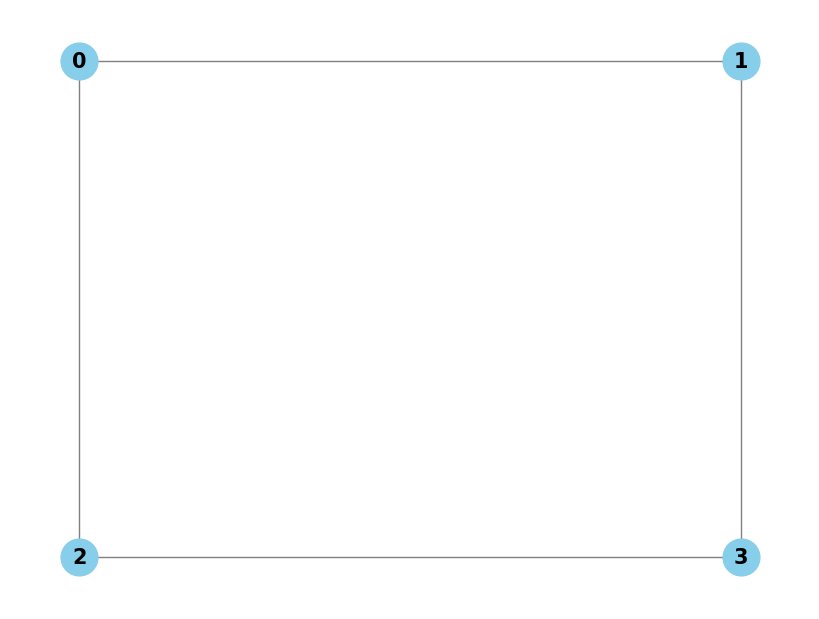

None


Matchings WITH relabeling: 2
Matchings: [{('01', '00'), ('11', '10')}, {('00', '10'), ('01', '11')}]
Relabeled edges: {('01', '00'), ('00', '10'), ('11', '10'), ('01', '11')}

Matchings WITHOUT relabeling: 2
Matchings: [{('00', '10'), ('01', '11')}, {('00', '01'), ('10', '11')}]
Number of qubits: 2

Hamming Cost Analysis:
With Relabeling: Total = 4, Edges = 4, Per Edge = 1.000
No Relabeling: Total = 4, Edges = 4, Per Edge = 1.000

Relabeled Graph:


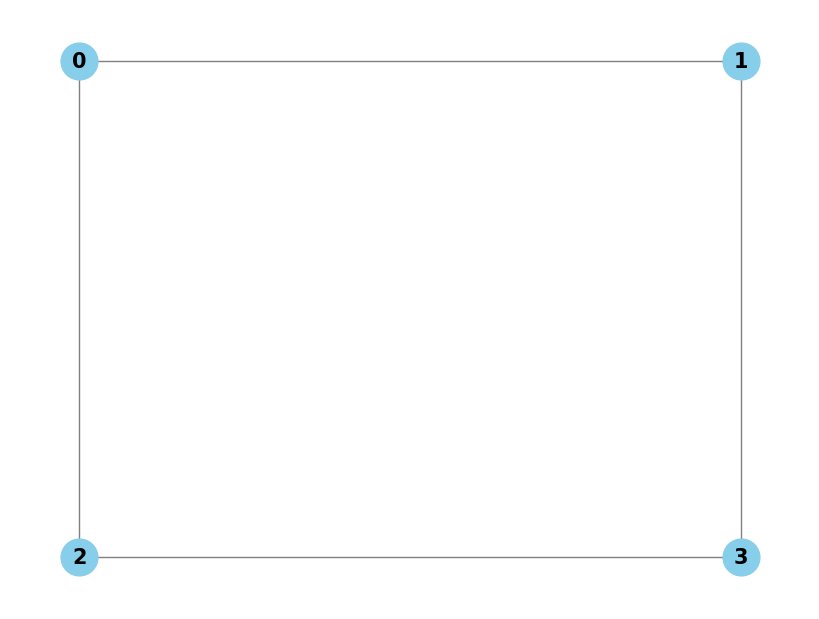

None


Sample Circuit - Matching WITH Relabeling (n_steps=1):


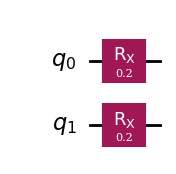


Sample Circuit - Matching WITHOUT Relabeling (n_steps=1):


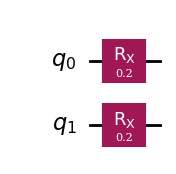


CX Gate Count Summary for Cycle Graph C4:
n_steps  |   Matching w/ Relabel (No Opt/Opt)    | Matching No Relabel (No Opt/Opt)  | Pauli (No Opt/Opt) 
----------------------------------------------------------------------------------------------------
1        |    0/0                                 |    0/0                             |    0/0   
2        |    0/0                                 |    0/0                             |    0/0   
5        |    0/0                                 |    0/0                             |    0/0   
10       |    0/0                                 |    0/0                             |    0/0   
20       |    0/0                                 |    0/0                             |    0/0   
50       |    0/0                                 |    0/0                             |    0/0   
100      |    0/0                                 |    0/0                             |    0/0   
--------------------------------------------------------

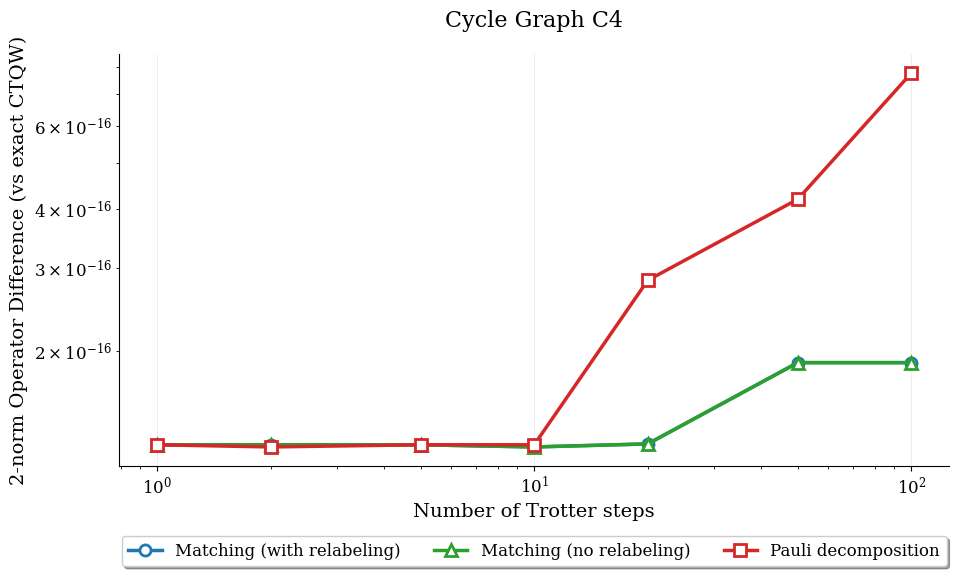

In [51]:
edges = {('00', '10'), ('01', '11'), ('10', '11'), ('00', '01')}
analyze_and_plot(edges, "Cycle Graph C4")


Complete Graph K4 - C2
Original edges: {('00', '01'), ('00', '11'), ('01', '10'), ('00', '10'), ('01', '11')}
Number of qubits: 2

Original Graph:


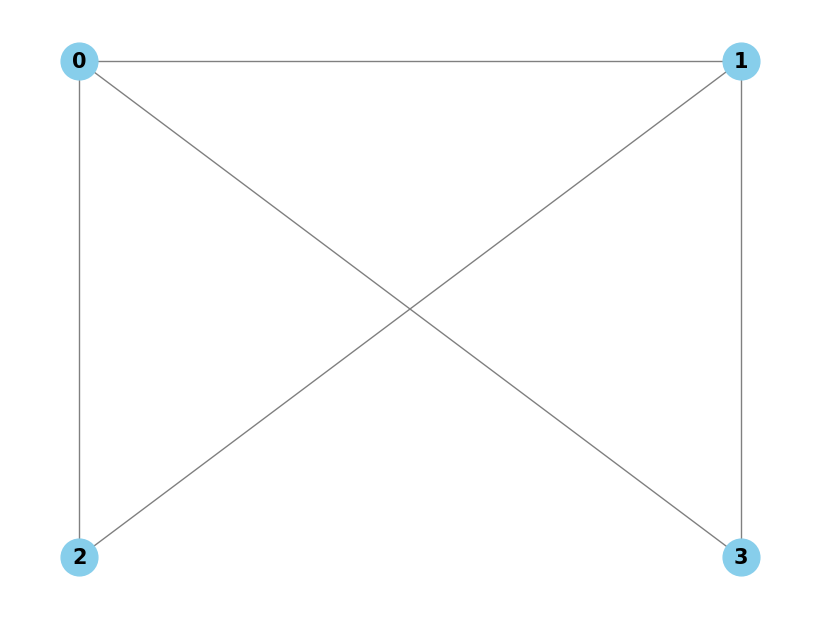

None


Matchings WITH relabeling: 3
Matchings: [{('00', '11')}, {('11', '10'), ('00', '01')}, {('00', '10'), ('11', '01')}]
Relabeled edges: {('00', '01'), ('00', '11'), ('00', '10'), ('11', '10'), ('11', '01')}

Matchings WITHOUT relabeling: 3
Matchings: [{('00', '01')}, {('01', '10'), ('00', '11')}, {('00', '10'), ('01', '11')}]
Number of qubits: 2

Hamming Cost Analysis:
With Relabeling: Total = 6, Edges = 5, Per Edge = 1.200
No Relabeling: Total = 7, Edges = 5, Per Edge = 1.400

Relabeled Graph:


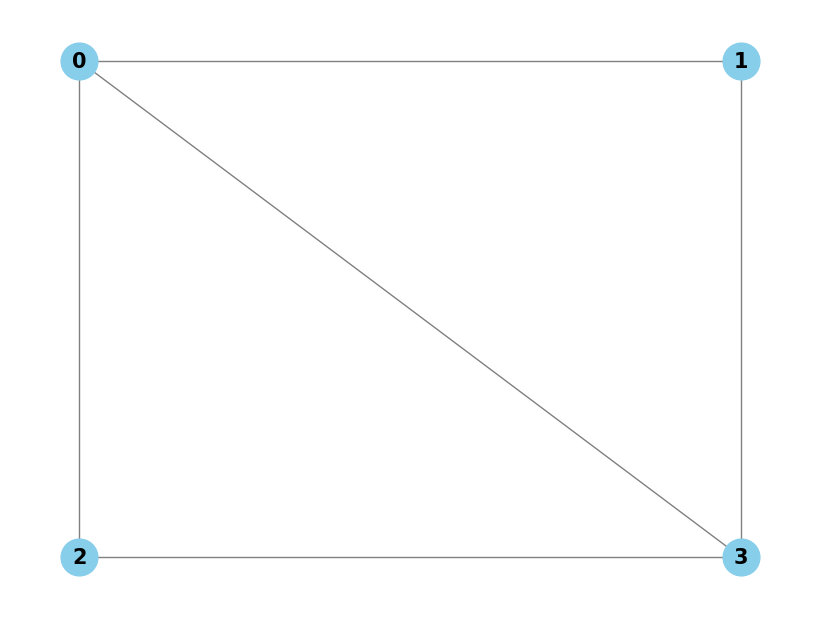

None


Sample Circuit - Matching WITH Relabeling (n_steps=1):


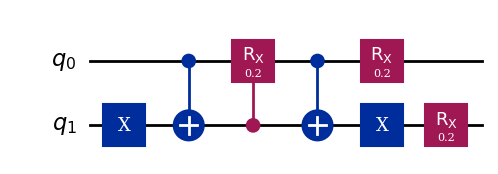


Sample Circuit - Matching WITHOUT Relabeling (n_steps=1):


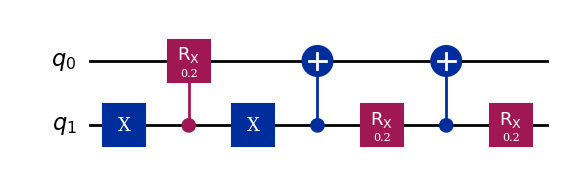


CX Gate Count Summary for Complete Graph K4 - C2:
n_steps  |   Matching w/ Relabel (No Opt/Opt)    | Matching No Relabel (No Opt/Opt)  | Pauli (No Opt/Opt) 
----------------------------------------------------------------------------------------------------
1        |    4/2                                 |   10/2                             |    4/2   
2        |    8/3                                 |   20/2                             |    8/2   
5        |   20/3                                 |   50/2                             |   20/2   
10       |   40/3                                 |  100/2                             |   40/2   
20       |   80/3                                 |  200/2                             |   80/2   
50       |  200/3                                 |  500/2                             |  200/2   
100      |  400/3                                 | 1000/2                             |  400/2   
------------------------------------------------

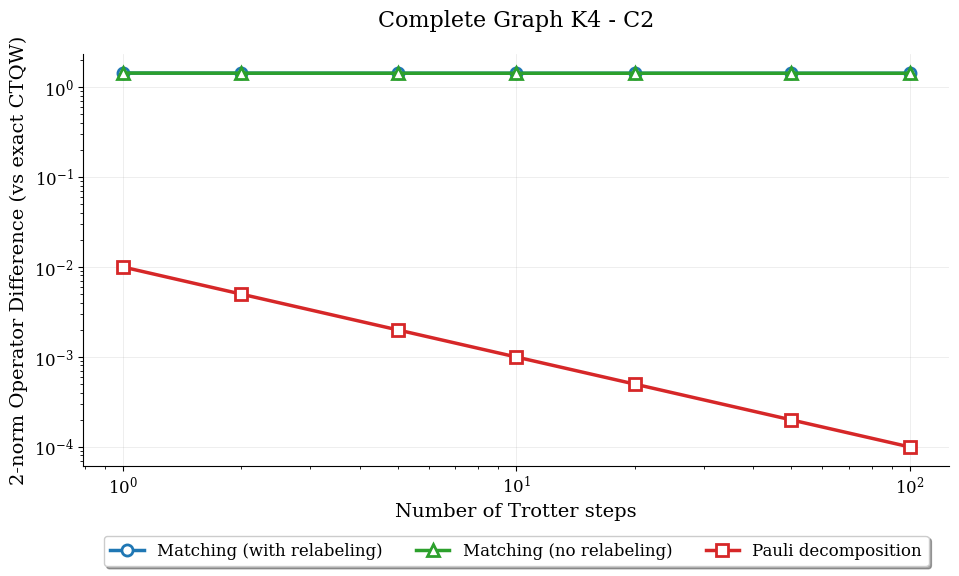

In [52]:
edges = {('00', '11'), ('01', '10'), ('00', '10'), ('01', '11'), ('00', '01')}
analyze_and_plot(edges, "Complete Graph K4 - C2")


Path Graph P3
Original edges: {('01', '10'), ('00', '01'), ('10', '11')}
Number of qubits: 2

Original Graph:


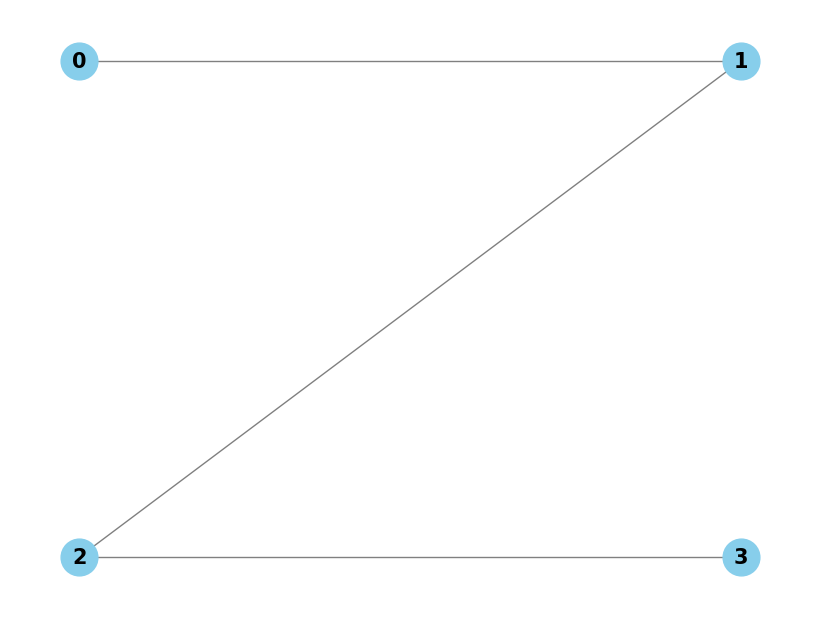

None


Matchings WITH relabeling: 2
Matchings: [{('11', '01')}, {('01', '00'), ('10', '11')}]
Relabeled edges: {('01', '00'), ('10', '11'), ('11', '01')}

Matchings WITHOUT relabeling: 2
Matchings: [{('01', '10')}, {('00', '01'), ('10', '11')}]
Number of qubits: 2

Hamming Cost Analysis:
With Relabeling: Total = 3, Edges = 3, Per Edge = 1.000
No Relabeling: Total = 4, Edges = 3, Per Edge = 1.333

Relabeled Graph:


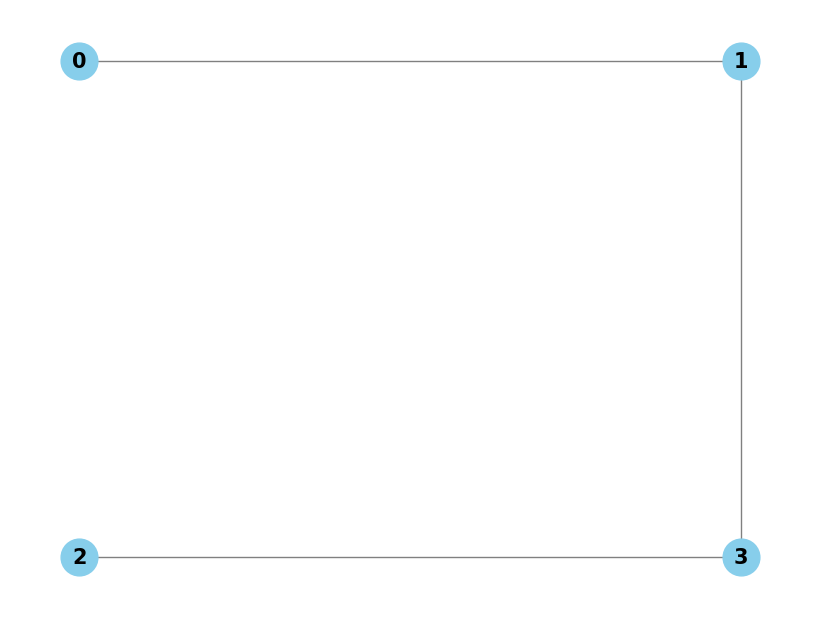

None


Sample Circuit - Matching WITH Relabeling (n_steps=1):


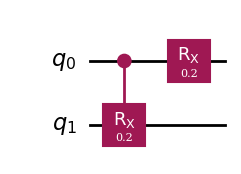


Sample Circuit - Matching WITHOUT Relabeling (n_steps=1):


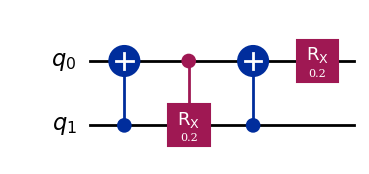


CX Gate Count Summary for Path Graph P3:
n_steps  |   Matching w/ Relabel (No Opt/Opt)    | Matching No Relabel (No Opt/Opt)  | Pauli (No Opt/Opt) 
----------------------------------------------------------------------------------------------------
1        |    2/2                                 |    4/2                             |    4/2   
2        |    4/2                                 |    8/2                             |    8/2   
5        |   10/2                                 |   20/2                             |   20/2   
10       |   20/2                                 |   40/2                             |   40/2   
20       |   40/2                                 |   80/2                             |   80/2   
50       |  100/2                                 |  200/2                             |  200/2   
100      |  200/2                                 |  400/2                             |  400/2   
---------------------------------------------------------

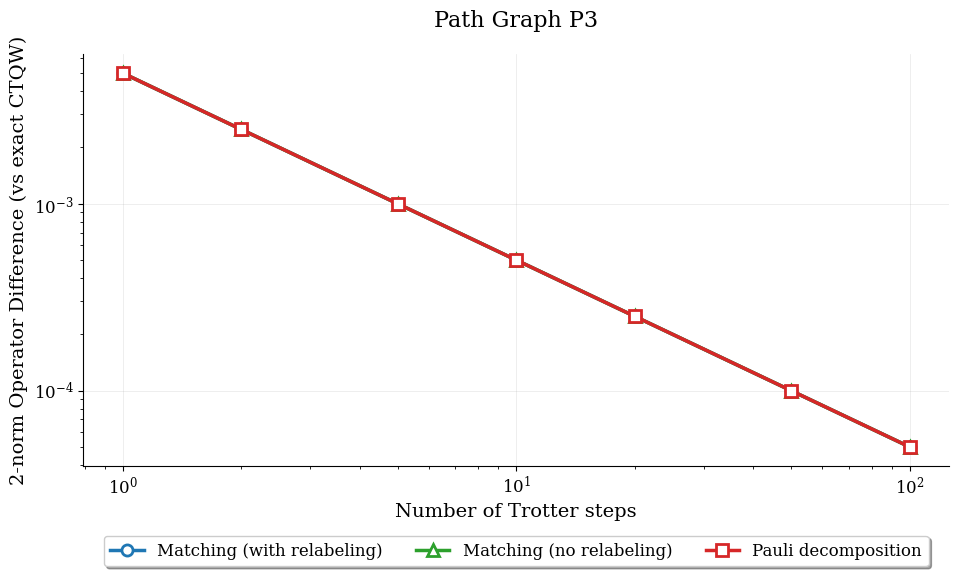

In [53]:
edges = {('00', '01'), ('01', '10'), ('10', '11')}
analyze_and_plot(edges, "Path Graph P3")


Tree Graph (2 qubits)
Original edges: {('00', '10'), ('00', '01'), ('00', '11')}
Number of qubits: 2

Original Graph:


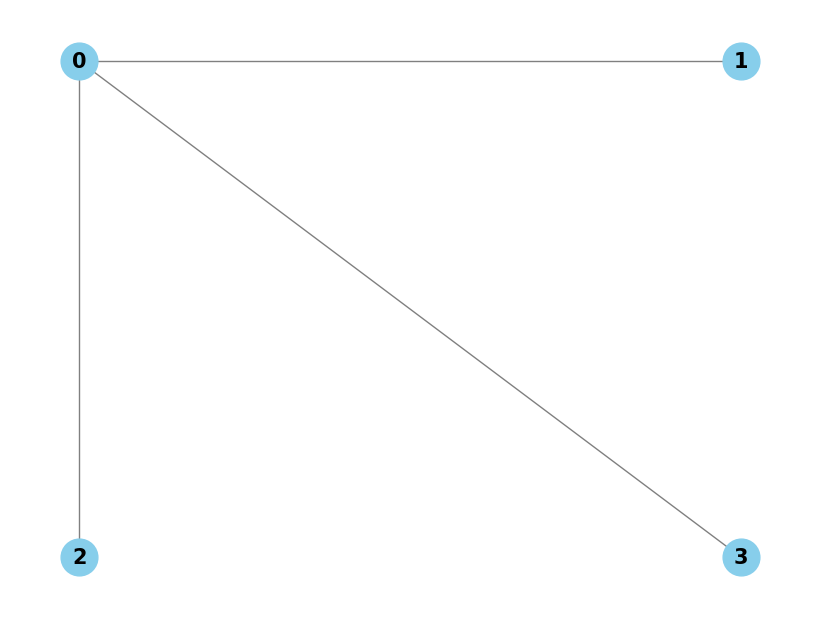

None


Matchings WITH relabeling: 3
Matchings: [{('01', '11')}, {('01', '10')}, {('01', '00')}]
Relabeled edges: {('01', '10'), ('01', '00'), ('01', '11')}

Matchings WITHOUT relabeling: 3
Matchings: [{('00', '10')}, {('00', '01')}, {('00', '11')}]
Number of qubits: 2

Hamming Cost Analysis:
With Relabeling: Total = 4, Edges = 3, Per Edge = 1.333
No Relabeling: Total = 4, Edges = 3, Per Edge = 1.333

Relabeled Graph:


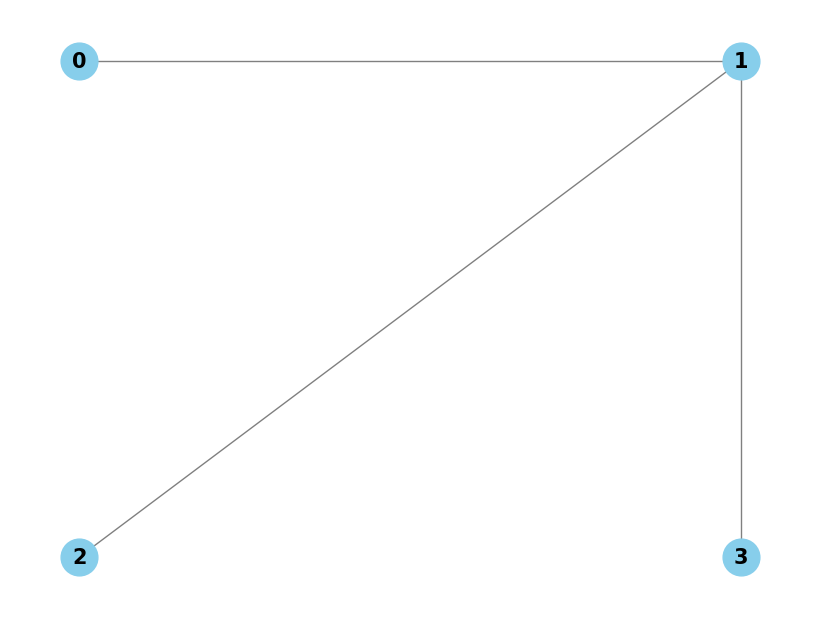

None


Sample Circuit - Matching WITH Relabeling (n_steps=1):


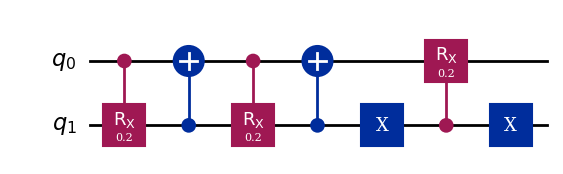


Sample Circuit - Matching WITHOUT Relabeling (n_steps=1):


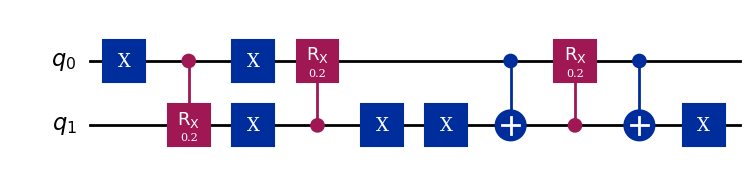


CX Gate Count Summary for Tree Graph (2 qubits):
n_steps  |   Matching w/ Relabel (No Opt/Opt)    | Matching No Relabel (No Opt/Opt)  | Pauli (No Opt/Opt) 
----------------------------------------------------------------------------------------------------
1        |    8/3                                 |    8/3                             |    8/3   
2        |   16/3                                 |   16/3                             |   16/3   
5        |   40/3                                 |   40/3                             |   40/3   
10       |   80/3                                 |   80/3                             |   80/3   
20       |  160/3                                 |  160/3                             |  160/3   
50       |  400/3                                 |  400/3                             |  400/3   
100      |  800/3                                 |  800/3                             |  800/3   
-------------------------------------------------

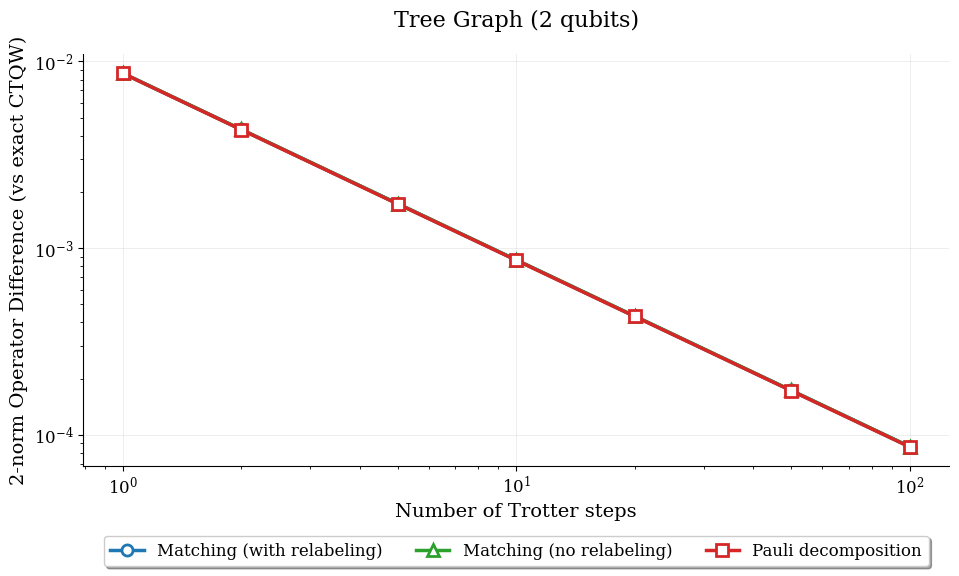

In [54]:
edges = {('00','01'), ('00','10'), ('00','11')}
analyze_and_plot(edges, "Tree Graph (2 qubits)")


Tree Graph (3 qubits)
Original edges: {('000', '101'), ('000', '011'), ('000', '001'), ('000', '111'), ('000', '100'), ('000', '010'), ('000', '110')}
Number of qubits: 3

Original Graph:


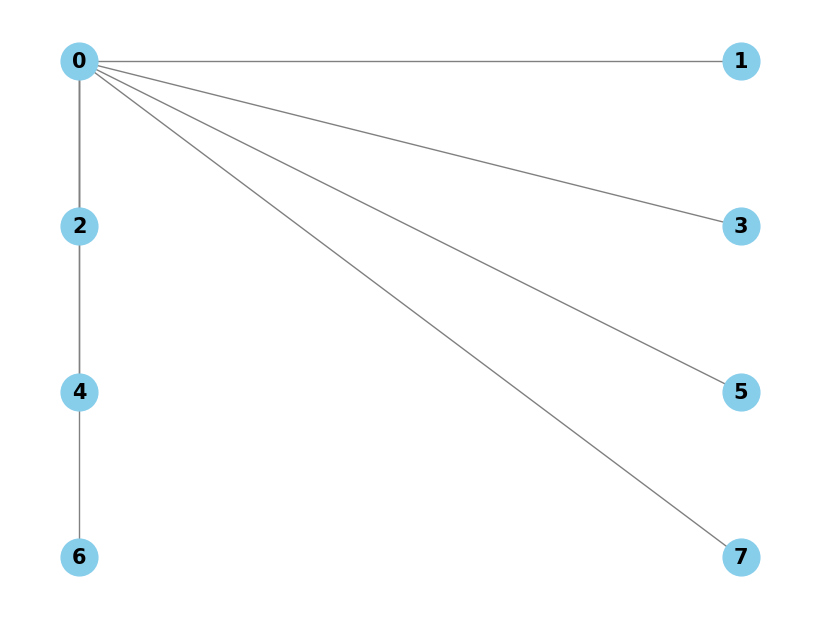

None


Matchings WITH relabeling: 7
Matchings: [{('001', '111')}, {('001', '110')}, {('001', '010')}, {('001', '100')}, {('001', '101')}, {('001', '011')}, {('001', '000')}]
Relabeled edges: {('001', '110'), ('001', '000'), ('001', '100'), ('001', '101'), ('001', '111'), ('001', '010'), ('001', '011')}

Matchings WITHOUT relabeling: 7
Matchings: [{('000', '101')}, {('000', '011')}, {('000', '111')}, {('000', '110')}, {('000', '001')}, {('000', '100')}, {('000', '010')}]
Number of qubits: 3

Hamming Cost Analysis:
With Relabeling: Total = 12, Edges = 7, Per Edge = 1.714
No Relabeling: Total = 12, Edges = 7, Per Edge = 1.714

Relabeled Graph:


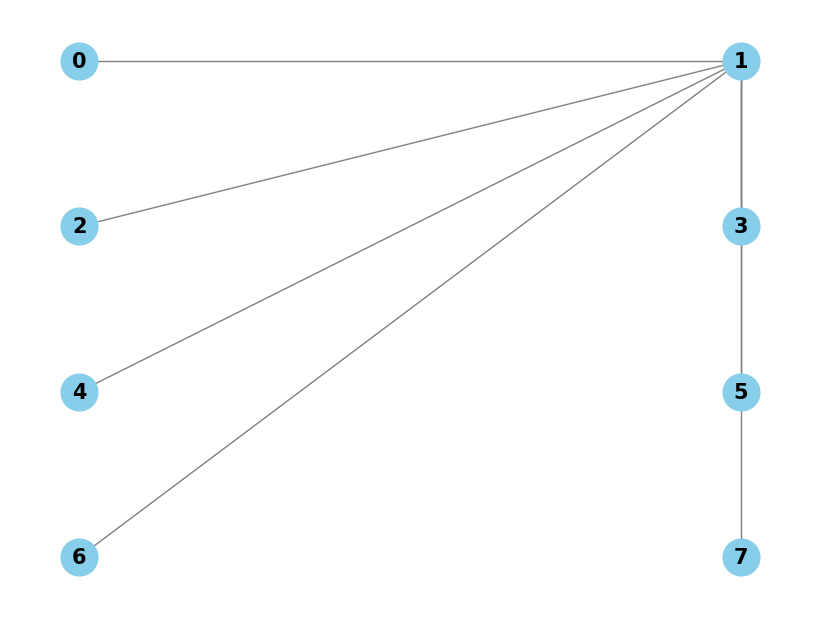

None


Sample Circuit - Matching WITH Relabeling (n_steps=1):


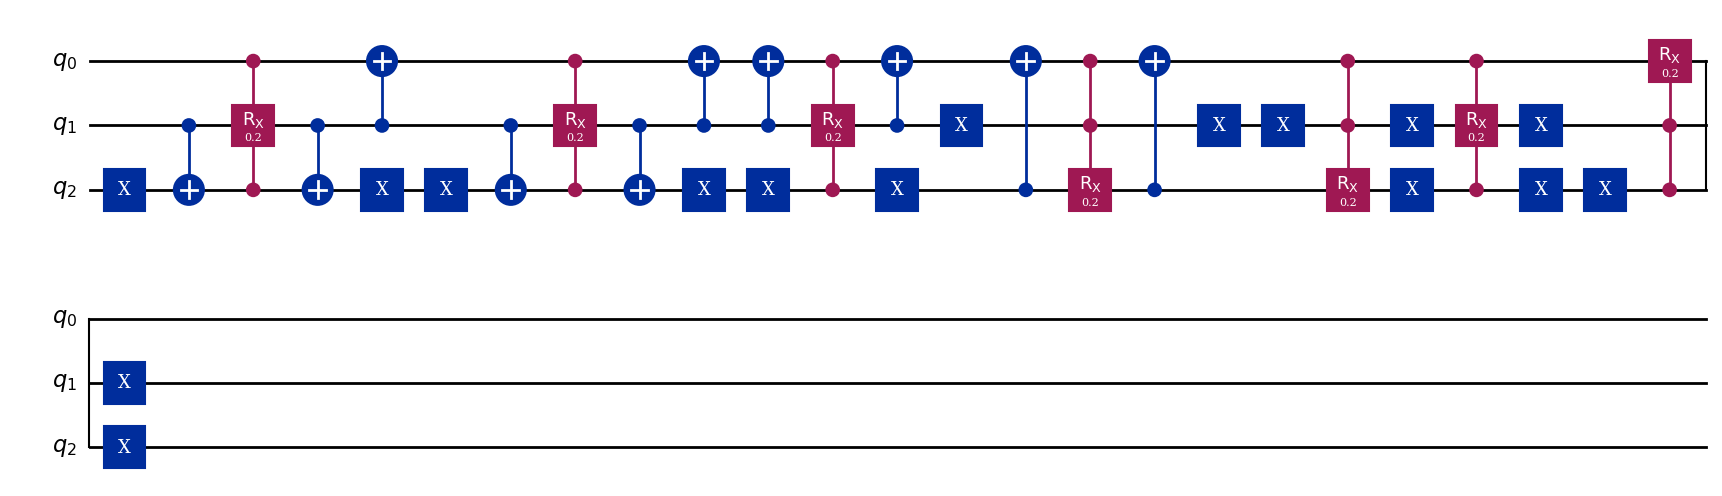


Sample Circuit - Matching WITHOUT Relabeling (n_steps=1):


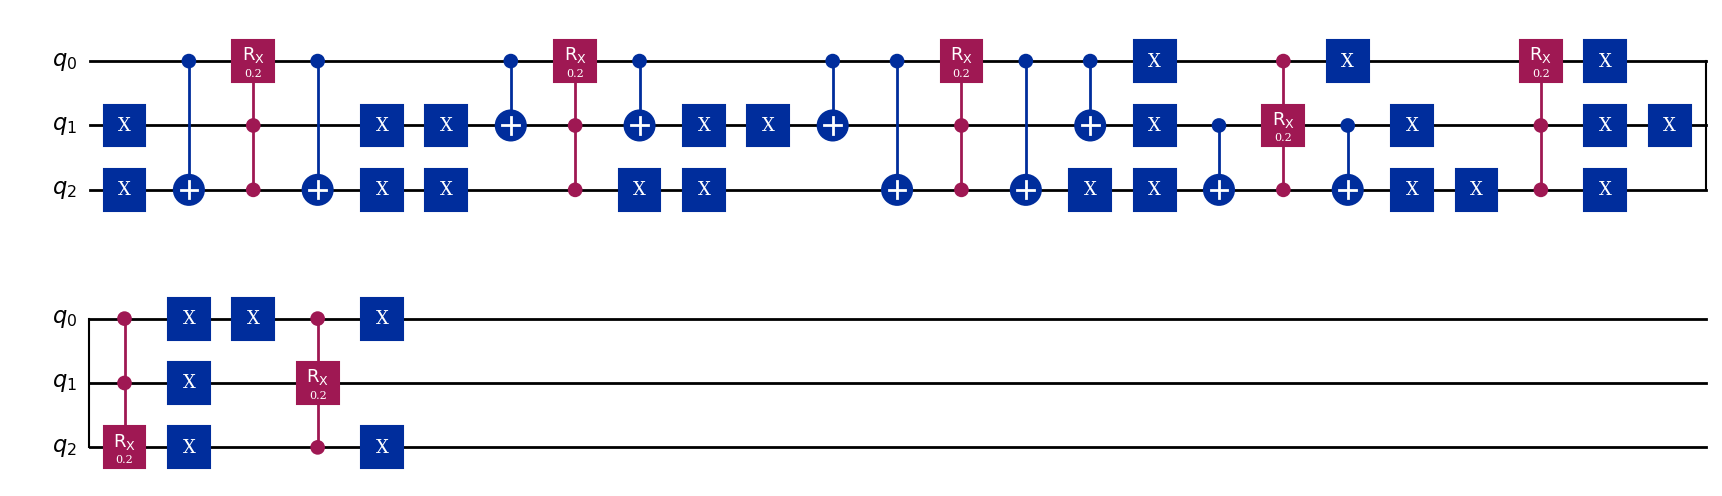


CX Gate Count Summary for Tree Graph (3 qubits):
n_steps  |   Matching w/ Relabel (No Opt/Opt)    | Matching No Relabel (No Opt/Opt)  | Pauli (No Opt/Opt) 
----------------------------------------------------------------------------------------------------
1        |   66/57                                |   66/61                            |   76/30  
2        |  132/114                               |  132/122                           |  152/60  
5        |  330/285                               |  330/305                           |  380/150 
10       |  660/570                               |  660/610                           |  760/300 
20       | 1320/1140                              | 1320/1220                          | 1520/600 
50       | 3300/2850                              | 3300/3050                          | 3800/1500
100      | 6600/5700                              | 6600/6100                          | 7600/3000
-------------------------------------------------

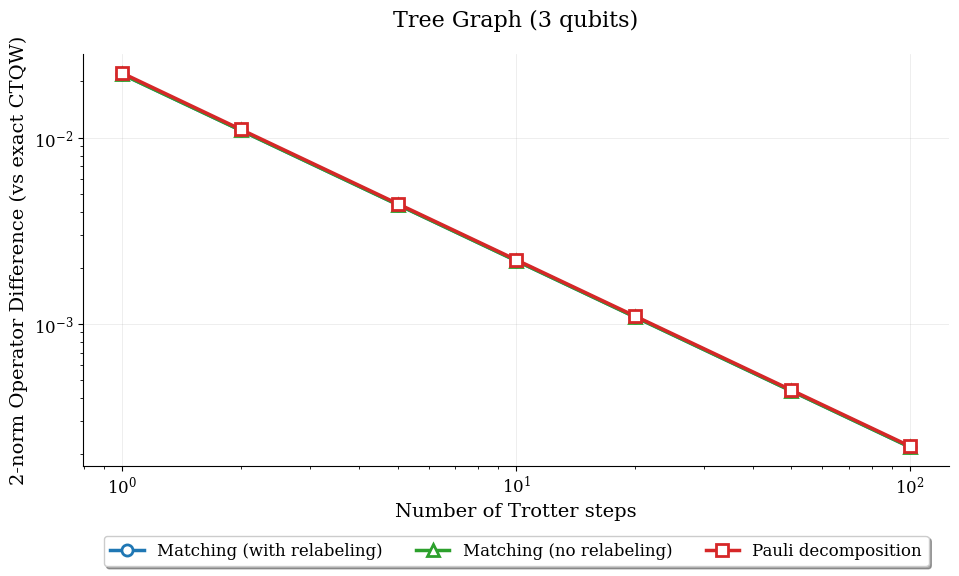

In [55]:
edges = {('000','001'), ('000','010'), ('000','011'), ('000','100'), ('000','101'), ('000','110'), ('000','111')}
analyze_and_plot(edges, "Tree Graph (3 qubits)")


Dense Non-Bipartite Graph (3 qubits)
Original edges: {('001', '101'), ('101', '110'), ('100', '110'), ('010', '011'), ('001', '111'), ('010', '111'), ('000', '100'), ('000', '110'), ('001', '100'), ('000', '001'), ('110', '111'), ('000', '010'), ('010', '100'), ('101', '111'), ('011', '101'), ('100', '101'), ('011', '111'), ('010', '110'), ('100', '111'), ('001', '010'), ('000', '101'), ('000', '011'), ('011', '100'), ('001', '011')}
Number of qubits: 3

Original Graph:


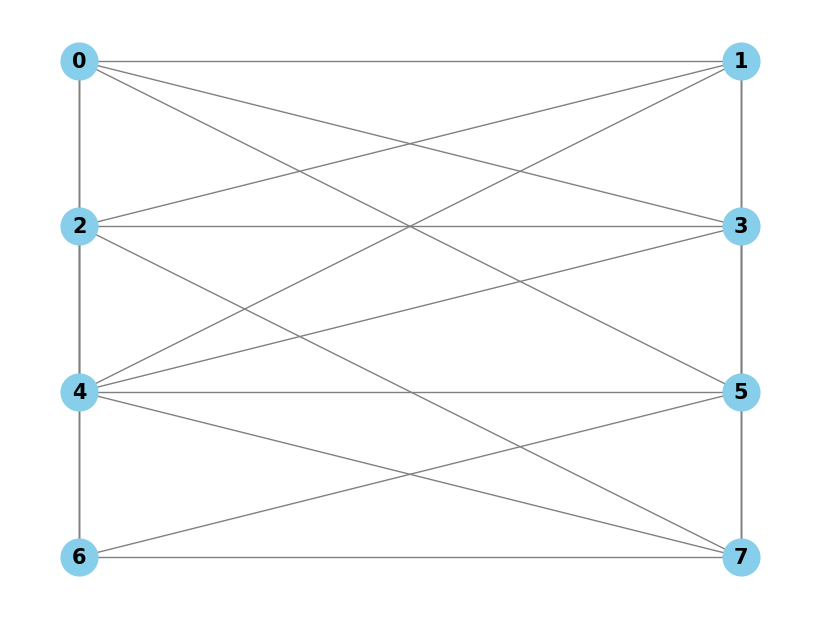

None


Matchings WITH relabeling: 7
Matchings: [{('001', '101'), ('010', '110'), ('011', '111'), ('000', '100')}, {('010', '100'), ('000', '011'), ('101', '110'), ('001', '111')}, {('001', '100'), ('011', '101'), ('010', '111'), ('000', '110')}, {('000', '101'), ('100', '111'), ('001', '010')}, {('011', '100')}, {('000', '010'), ('101', '111'), ('100', '110'), ('001', '011')}, {('100', '101'), ('000', '001'), ('010', '011'), ('110', '111')}]
Relabeled edges: {('001', '101'), ('101', '110'), ('001', '111'), ('010', '111'), ('000', '100'), ('100', '110'), ('010', '011'), ('000', '110'), ('001', '100'), ('000', '001'), ('110', '111'), ('000', '010'), ('010', '100'), ('101', '111'), ('011', '101'), ('011', '111'), ('010', '110'), ('100', '101'), ('100', '111'), ('001', '010'), ('000', '101'), ('000', '011'), ('011', '100'), ('001', '011')}

Matchings WITHOUT relabeling: 7
Matchings: [{('001', '101'), ('010', '110'), ('011', '111'), ('000', '100')}, {('010', '100'), ('000', '011'), ('101', '110')

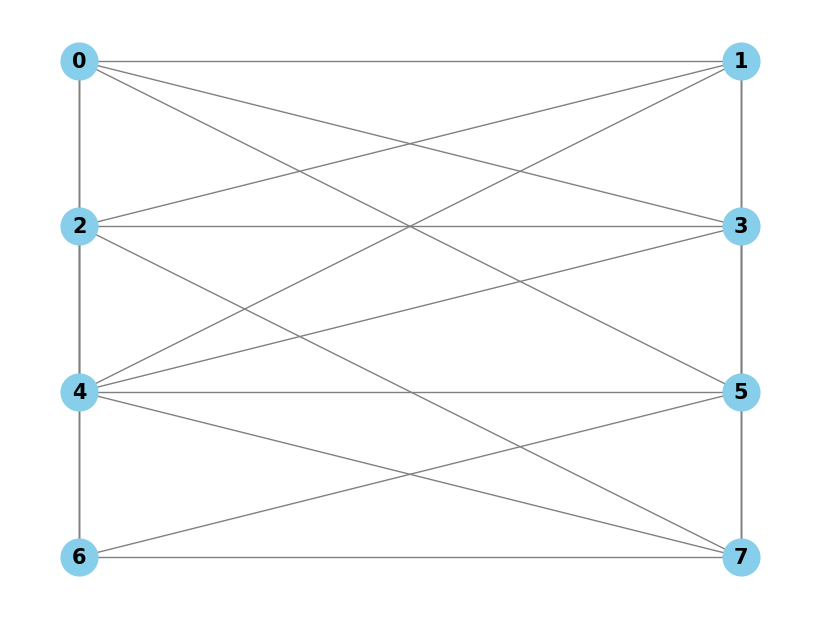

None


Sample Circuit - Matching WITH Relabeling (n_steps=1):


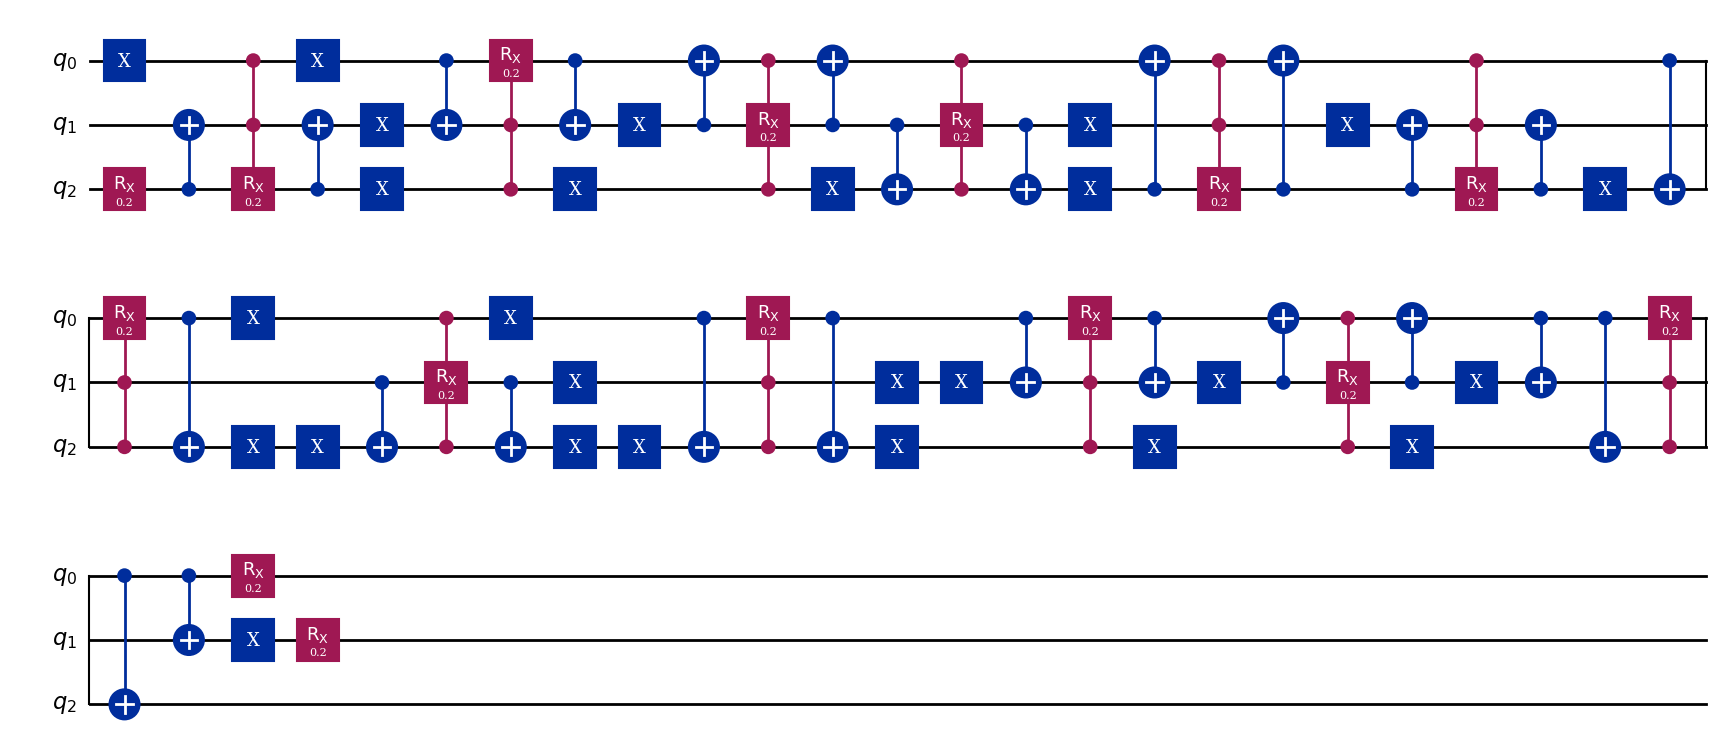


Sample Circuit - Matching WITHOUT Relabeling (n_steps=1):


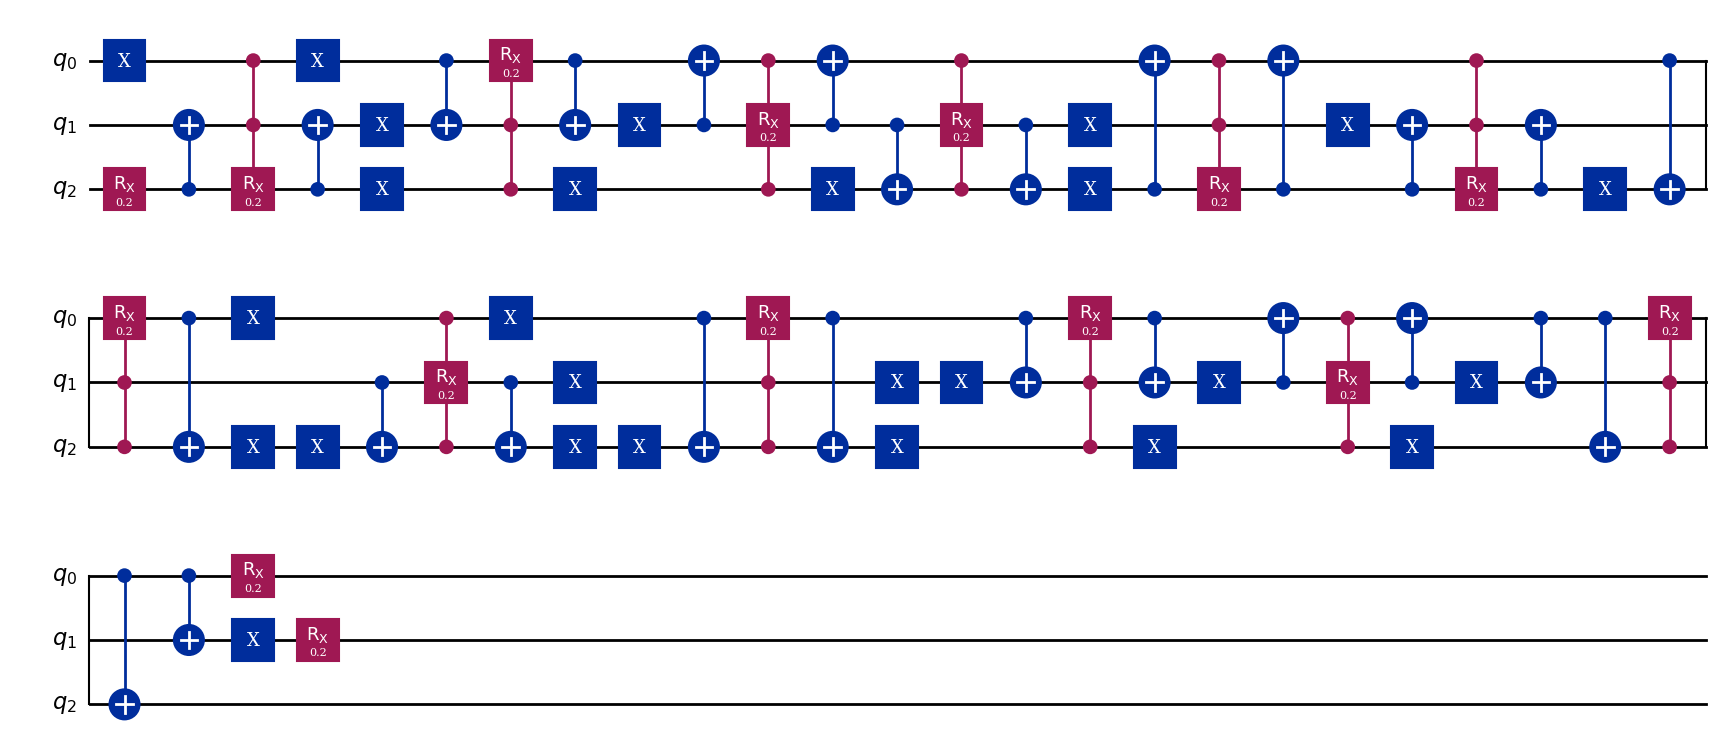


CX Gate Count Summary for Dense Non-Bipartite Graph (3 qubits):
n_steps  |   Matching w/ Relabel (No Opt/Opt)    | Matching No Relabel (No Opt/Opt)  | Pauli (No Opt/Opt) 
----------------------------------------------------------------------------------------------------
1        |  122/110                               |  122/110                           |   32/20  
2        |  244/220                               |  244/220                           |   64/40  
5        |  610/550                               |  610/550                           |  160/100 
10       | 1220/1100                              | 1220/1100                          |  320/200 
20       | 2440/2200                              | 2440/2200                          |  640/400 
50       | 6100/5500                              | 6100/5500                          | 1600/1000
100      | 12200/11000                              | 12200/11000                          | 3200/2000
------------------------------

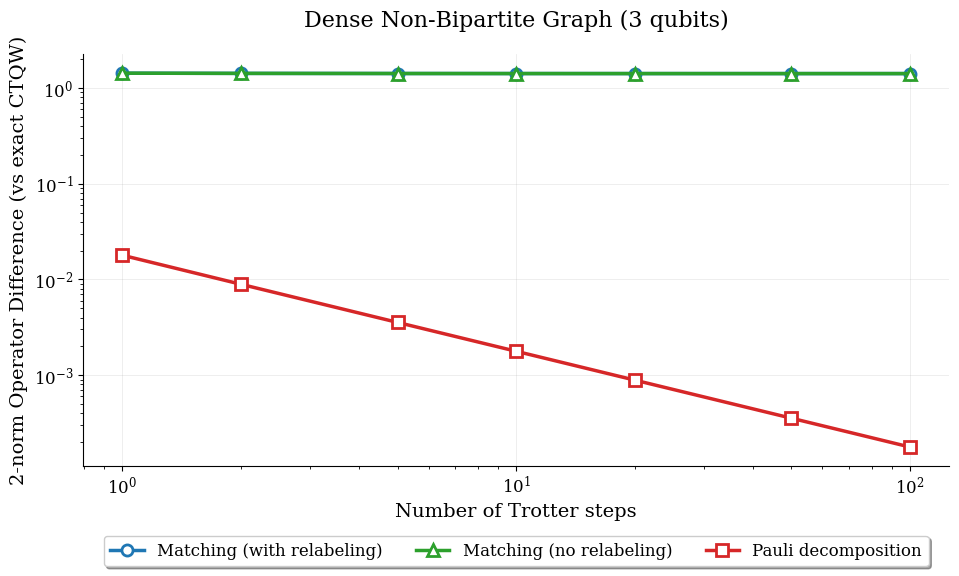

In [56]:
dense_nonbipartite_8 = {
    ('000','001'), ('000','010'), ('000','011'), ('000','100'), ('000','101'), ('000','110'),
    ('001','010'), ('001','011'), ('001','100'), ('001','101'), ('001','111'),
    ('010','011'), ('010','100'), ('010','110'), ('010','111'),
    ('011','100'), ('011','101'), ('011','111'),
    ('100','101'), ('100','110'), ('100','111'),
    ('101','110'), ('101','111'),
    ('110','111')
}

analyze_and_plot(dense_nonbipartite_8, "Dense Non-Bipartite Graph (3 qubits)")


Dense Bipartite Graph (3 qubits)
Original edges: {('011', '110'), ('001', '101'), ('001', '111'), ('010', '111'), ('000', '100'), ('010', '101'), ('000', '110'), ('001', '100'), ('010', '100'), ('001', '110'), ('011', '101'), ('011', '111'), ('010', '110'), ('000', '101'), ('000', '111'), ('011', '100')}
Number of qubits: 3

Original Graph:


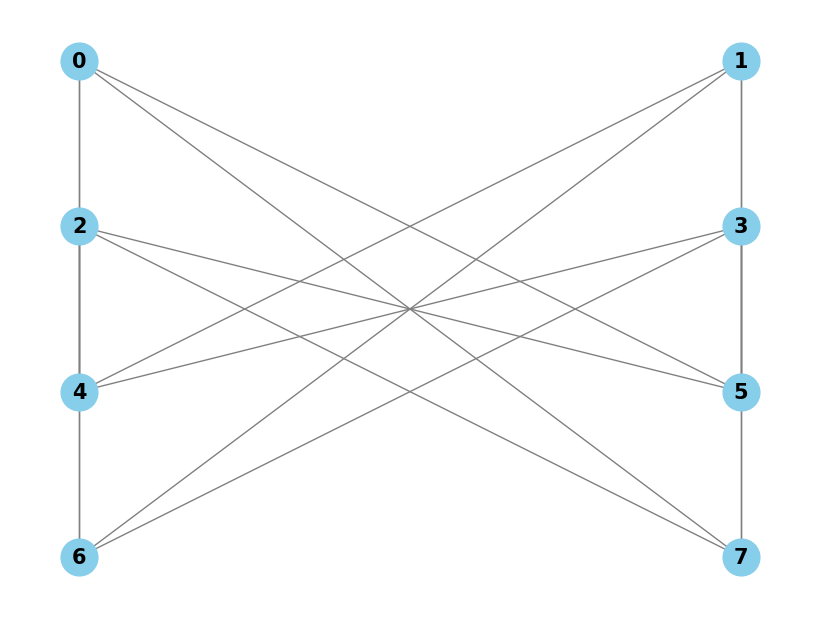

None


Matchings WITH relabeling: 6
Matchings: [{('100', '101'), ('001', '000'), ('011', '010'), ('111', '110')}, {('001', '101'), ('100', '000')}, {('011', '110'), ('001', '010'), ('111', '000')}, {('001', '110'), ('011', '000'), ('100', '010')}, {('111', '010'), ('011', '101')}, {('111', '101'), ('100', '110')}]
Relabeled edges: {('001', '110'), ('011', '110'), ('001', '101'), ('011', '101'), ('111', '101'), ('100', '110'), ('100', '101'), ('111', '010'), ('001', '010'), ('011', '010'), ('100', '010'), ('001', '000'), ('011', '000'), ('111', '000'), ('100', '000'), ('111', '110')}

Matchings WITHOUT relabeling: 5
Matchings: [{('011', '110'), ('001', '111'), ('010', '101')}, {('001', '100'), ('011', '101'), ('010', '111'), ('000', '110')}, {('001', '110'), ('010', '100'), ('000', '101')}, {('011', '100'), ('000', '111')}, {('001', '101'), ('010', '110'), ('011', '111'), ('000', '100')}]
Number of qubits: 3

Hamming Cost Analysis:
With Relabeling: Total = 26, Edges = 16, Per Edge = 1.625
No 

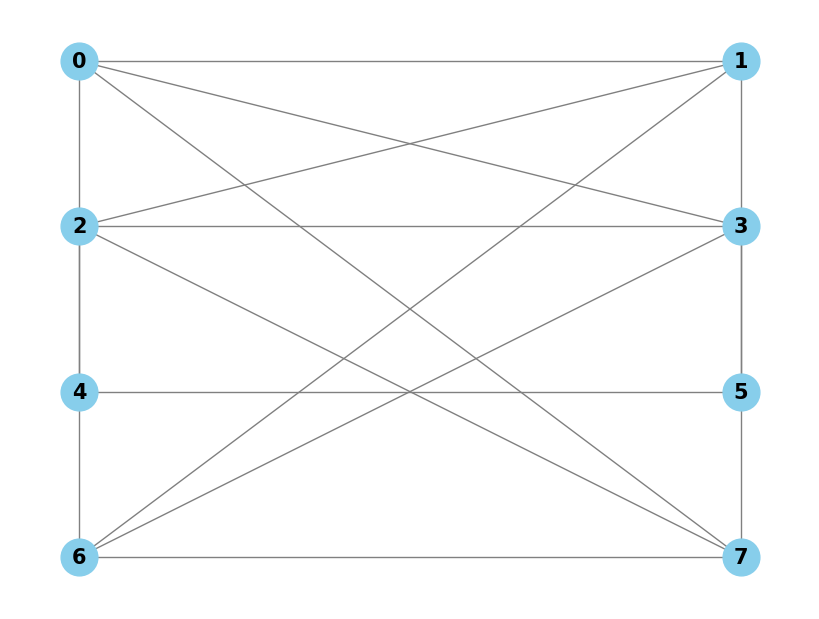

None


Sample Circuit - Matching WITH Relabeling (n_steps=1):


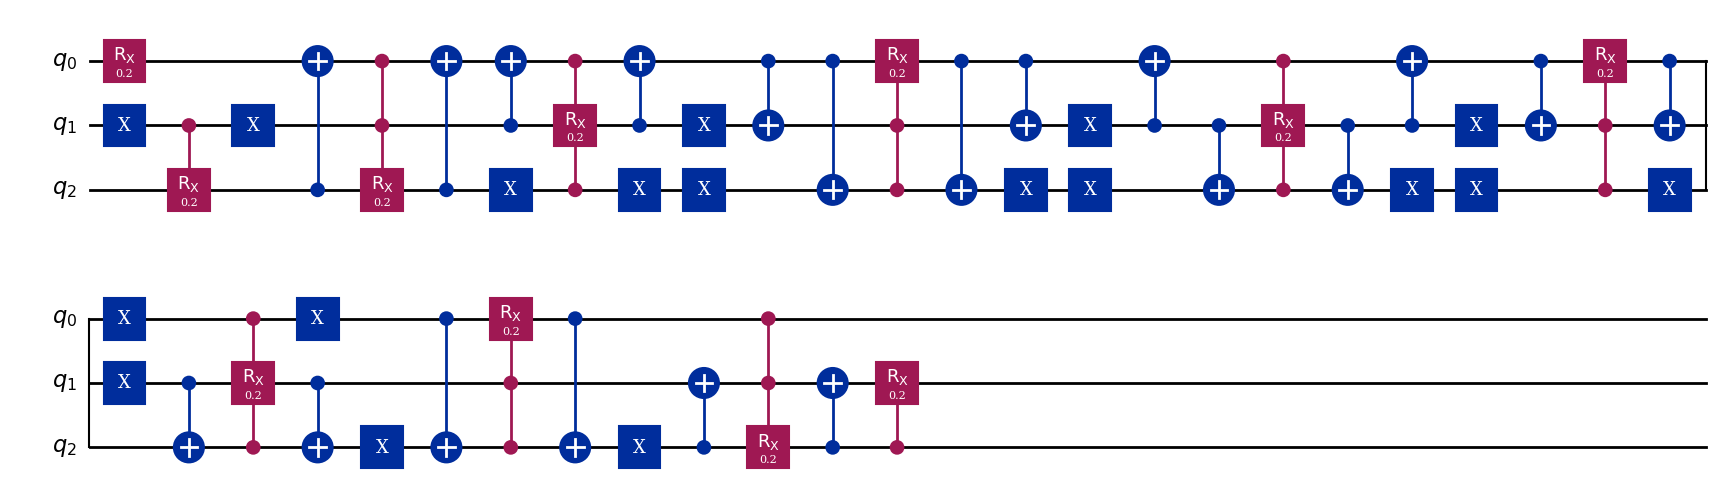


Sample Circuit - Matching WITHOUT Relabeling (n_steps=1):


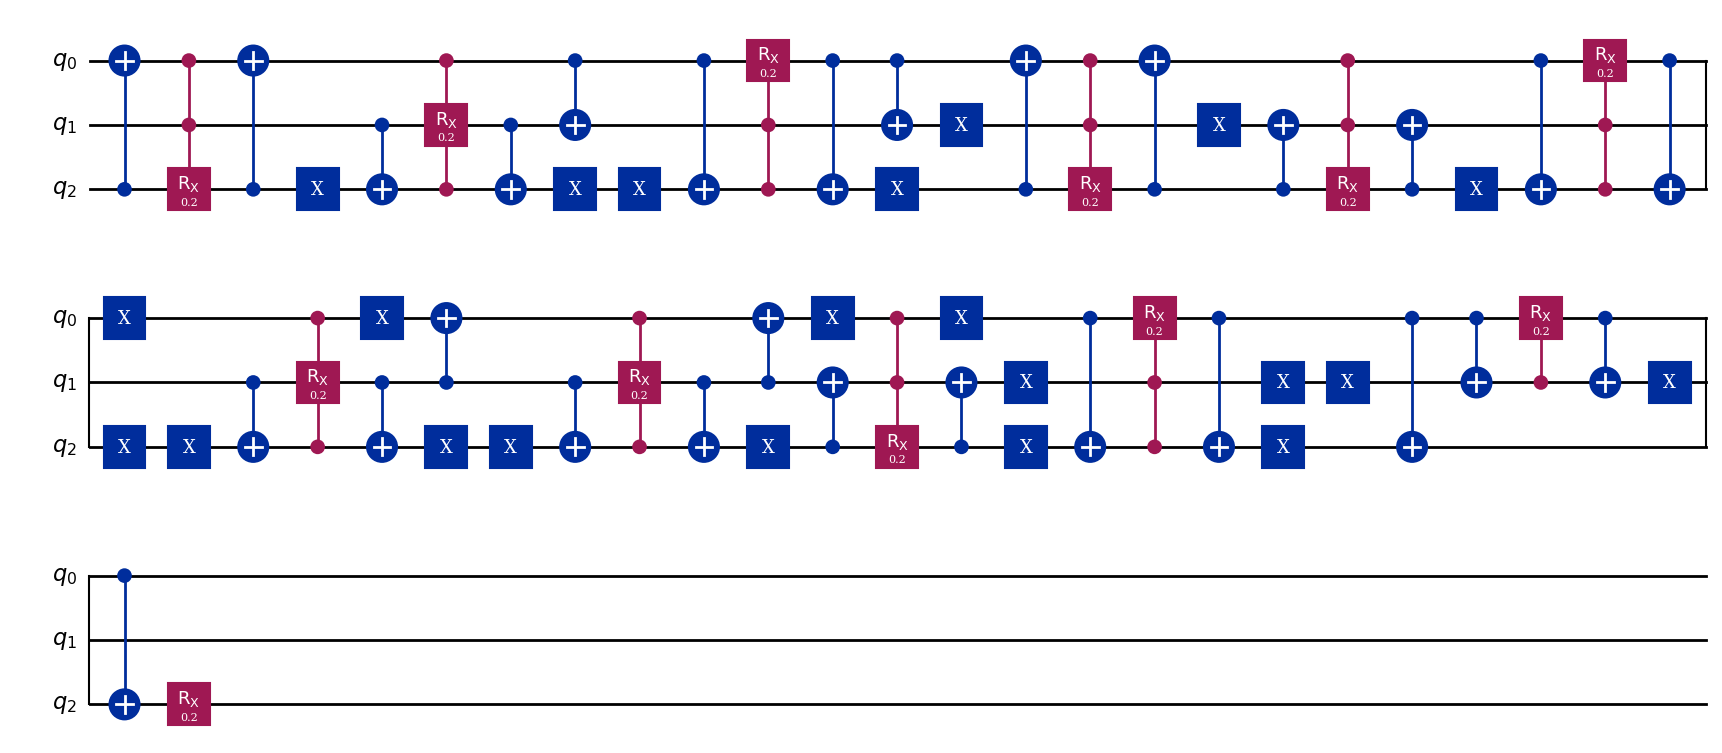


CX Gate Count Summary for Dense Bipartite Graph (3 qubits):
n_steps  |   Matching w/ Relabel (No Opt/Opt)    | Matching No Relabel (No Opt/Opt)  | Pauli (No Opt/Opt) 
----------------------------------------------------------------------------------------------------
1        |   88/79                                |  128/109                           |    8/6   
2        |  176/156                               |  256/218                           |   16/12  
5        |  440/387                               |  640/545                           |   40/30  
10       |  880/772                               | 1280/1090                          |   80/60  
20       | 1760/1542                              | 2560/2180                          |  160/120 
50       | 4400/3852                              | 6400/5450                          |  400/300 
100      | 8800/7702                              | 12800/10900                          |  800/600 
------------------------------------

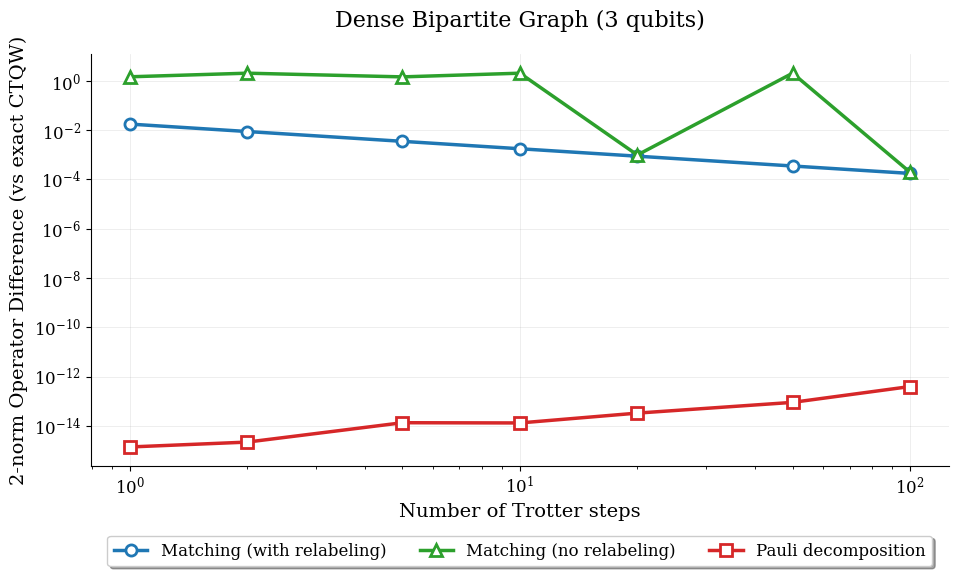

In [57]:
dense_bipartite_8 = {
    ('000','100'), ('000','101'), ('000','110'), ('000','111'),
    ('001','100'), ('001','101'), ('001','110'), ('001','111'),
    ('010','100'), ('010','101'), ('010','110'), ('010','111'),
    ('011','100'), ('011','101'), ('011','110'), ('011','111')  
}
analyze_and_plot(dense_bipartite_8, "Dense Bipartite Graph (3 qubits)")


Sparse Non-Bipartite Graph (3 qubits)
Original edges: {('000', '001'), ('010', '011'), ('110', '101'), ('100', '101'), ('110', '111'), ('100', '011')}
Number of qubits: 3

Original Graph:


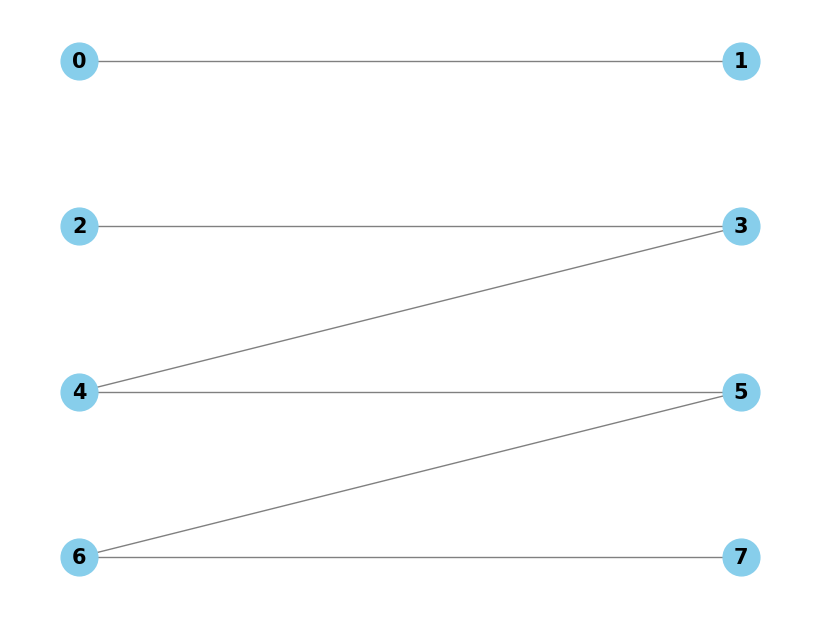

None


Matchings WITH relabeling: 3
Matchings: [{('000', '001'), ('011', '010'), ('111', '110'), ('101', '100')}, {('111', '001')}, {('000', '100')}]
Relabeled edges: {('000', '001'), ('111', '001'), ('101', '100'), ('000', '100'), ('011', '010'), ('111', '110')}

Matchings WITHOUT relabeling: 2
Matchings: [{('000', '001'), ('010', '011'), ('100', '101'), ('110', '111')}, {('100', '011'), ('110', '101')}]
Number of qubits: 3

Hamming Cost Analysis:
With Relabeling: Total = 7, Edges = 6, Per Edge = 1.167
No Relabeling: Total = 9, Edges = 6, Per Edge = 1.500

Relabeled Graph:


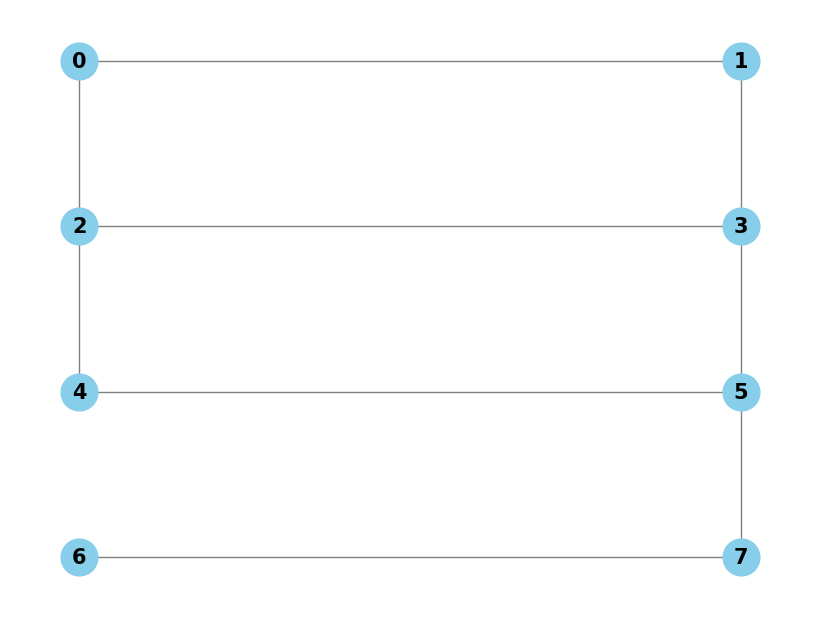

None


Sample Circuit - Matching WITH Relabeling (n_steps=1):


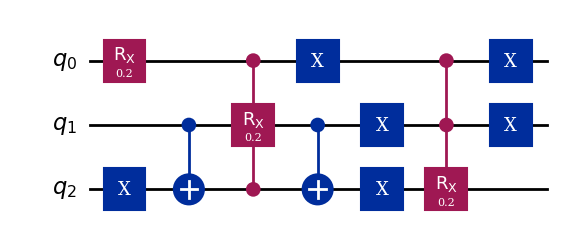


Sample Circuit - Matching WITHOUT Relabeling (n_steps=1):


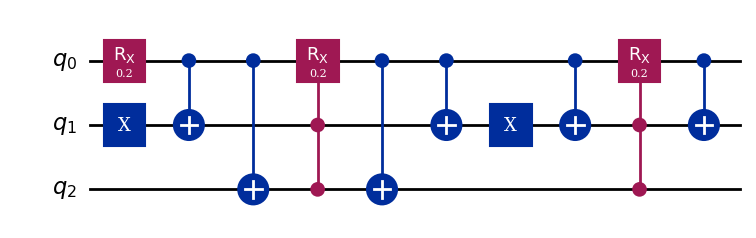


CX Gate Count Summary for Sparse Non-Bipartite Graph (3 qubits):
n_steps  |   Matching w/ Relabel (No Opt/Opt)    | Matching No Relabel (No Opt/Opt)  | Pauli (No Opt/Opt) 
----------------------------------------------------------------------------------------------------
1        |   18/16                                |   22/17                            |   28/23  
2        |   36/32                                |   44/33                            |   56/46  
5        |   90/80                                |  110/81                            |  140/115 
10       |  180/160                               |  220/161                           |  280/230 
20       |  360/320                               |  440/321                           |  560/460 
50       |  900/800                               | 1100/801                           | 1400/1150
100      | 1800/1600                              | 2200/1601                          | 2800/2300
---------------------------------

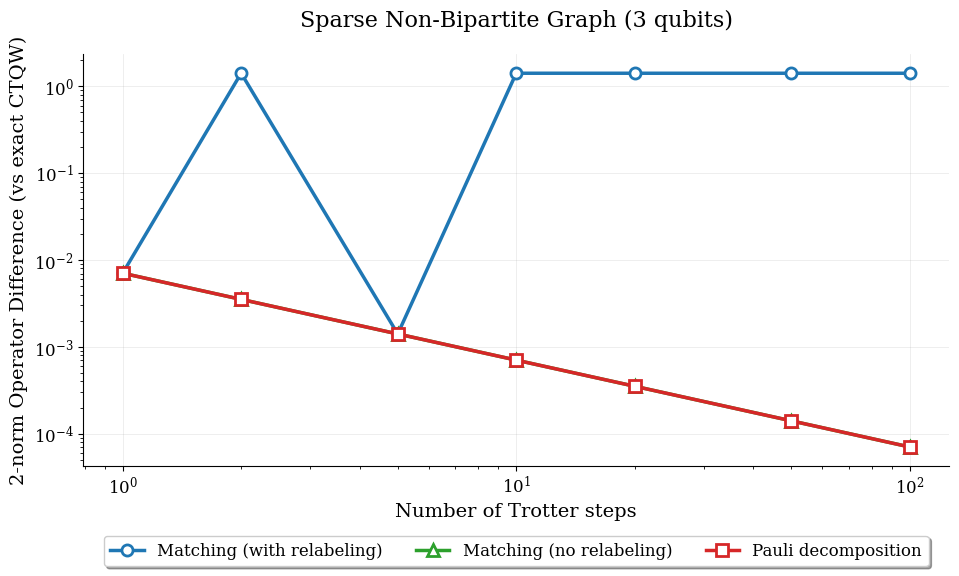

In [58]:
sparse_nonbipartite_8 = {
    ('000','001'), ('010','011'), ('100','011'), ('100','101'), ('110','101'), ('110','111')
}
analyze_and_plot(sparse_nonbipartite_8, "Sparse Non-Bipartite Graph (3 qubits)")


Sparse Bipartite Graph (3 qubits)
Original edges: {('000', '001'), ('010', '011'), ('010', '001'), ('100', '101'), ('110', '101'), ('100', '011'), ('110', '111')}
Number of qubits: 3

Original Graph:


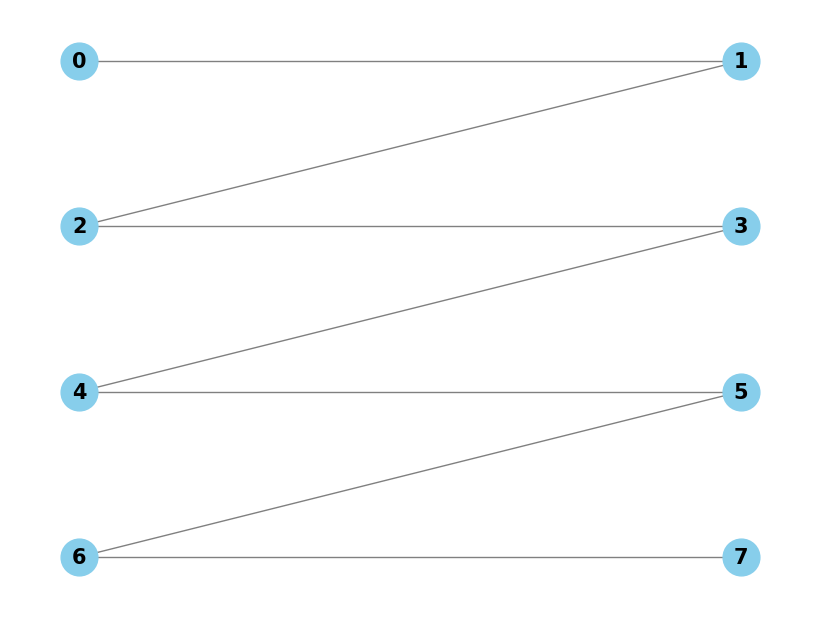

None


Matchings WITH relabeling: 4
Matchings: [{('010', '000'), ('011', '001')}, {('110', '101'), ('010', '001')}, {('100', '101'), ('110', '111')}, {('100', '000')}]
Relabeled edges: {('110', '101'), ('010', '001'), ('011', '001'), ('100', '101'), ('010', '000'), ('110', '111'), ('100', '000')}

Matchings WITHOUT relabeling: 2
Matchings: [{('000', '001'), ('010', '011'), ('100', '101'), ('110', '111')}, {('100', '011'), ('110', '101'), ('010', '001')}]
Number of qubits: 3

Hamming Cost Analysis:
With Relabeling: Total = 9, Edges = 7, Per Edge = 1.286
No Relabeling: Total = 11, Edges = 7, Per Edge = 1.571

Relabeled Graph:


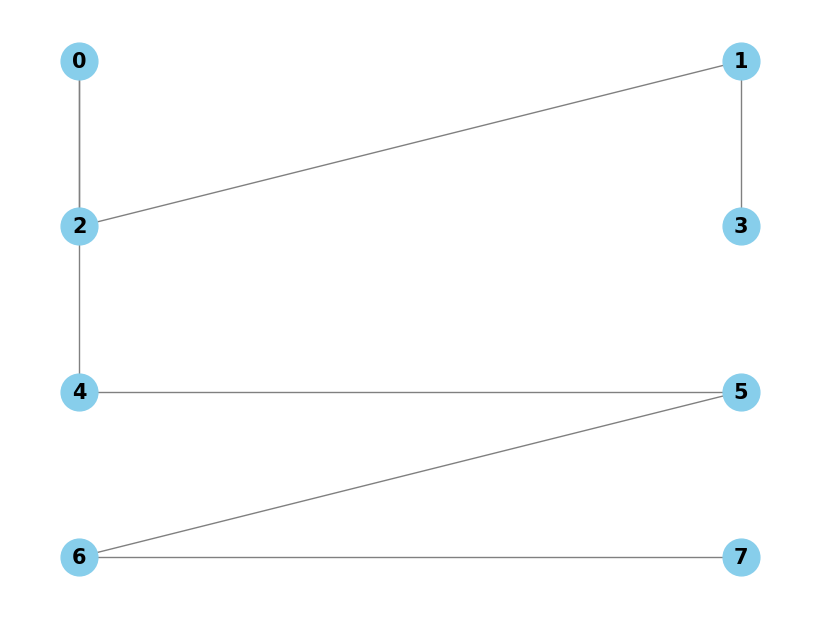

None


Sample Circuit - Matching WITH Relabeling (n_steps=1):


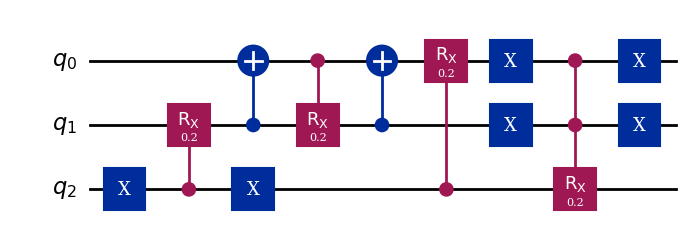


Sample Circuit - Matching WITHOUT Relabeling (n_steps=1):


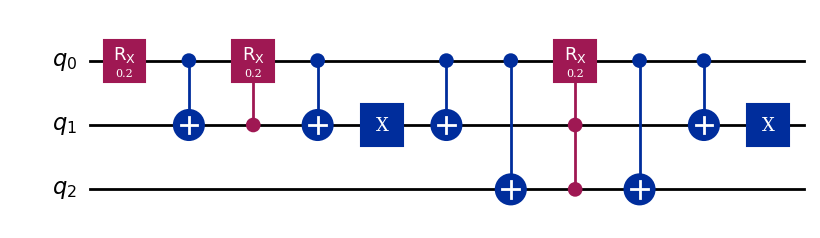


CX Gate Count Summary for Sparse Bipartite Graph (3 qubits):
n_steps  |   Matching w/ Relabel (No Opt/Opt)    | Matching No Relabel (No Opt/Opt)  | Pauli (No Opt/Opt) 
----------------------------------------------------------------------------------------------------
1        |   16/14                                |   32/25                            |   20/16  
2        |   32/28                                |   64/49                            |   40/32  
5        |   80/70                                |  160/121                           |  100/80  
10       |  160/140                               |  320/241                           |  200/160 
20       |  320/280                               |  640/481                           |  400/320 
50       |  800/700                               | 1600/1201                          | 1000/800 
100      | 1600/1400                              | 3200/2401                          | 2000/1600
-------------------------------------

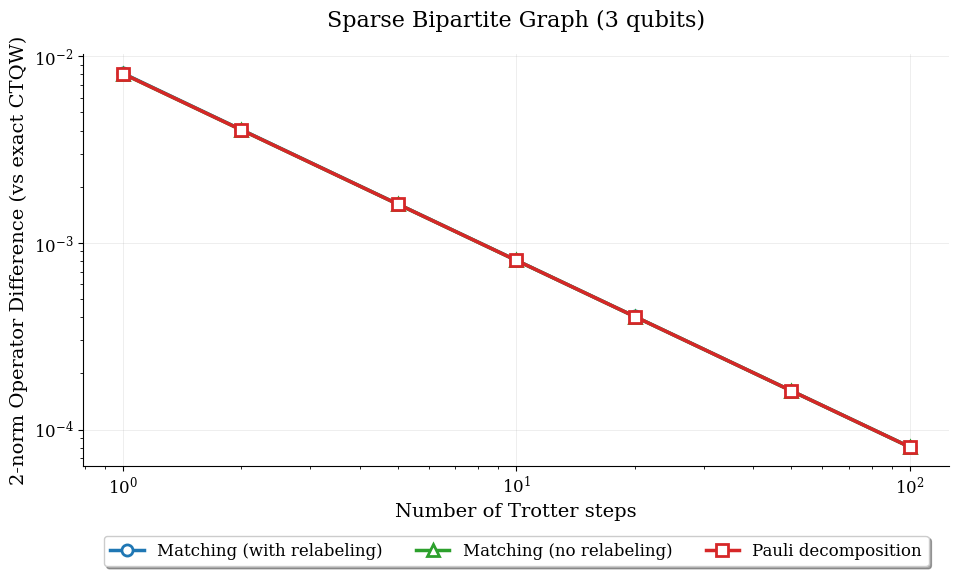

In [59]:
sparse_bipartite_8 = {
    ('000','001'), ('010','001'), ('010','011'), ('100','011'), ('100','101'), ('110','101'), ('110','111')
}

analyze_and_plot(sparse_bipartite_8, "Sparse Bipartite Graph (3 qubits)")


Dense Non-Bipartite Graph (4 qubits)
Original edges: {('0000', '0001'), ('1100', '1101'), ('1001', '1010'), ('1010', '1110'), ('0111', '1011'), ('1001', '1110'), ('0010', '0100'), ('0011', '1001'), ('0100', '0101'), ('0110', '1100'), ('1011', '1111'), ('1000', '1011'), ('0010', '0011'), ('0100', '1010'), ('0000', '0110'), ('0101', '1001'), ('0010', '1010'), ('0000', '0111'), ('0001', '0101'), ('0001', '0100'), ('1001', '1101'), ('0011', '0111'), ('0110', '1010'), ('0001', '0011'), ('0110', '1110'), ('1000', '1100'), ('0010', '0110'), ('0101', '1101'), ('1011', '1101'), ('0101', '0110'), ('0100', '0110'), ('0000', '0010'), ('0001', '1001'), ('0101', '0111'), ('1010', '1011'), ('0010', '1000'), ('0111', '1111'), ('1001', '1011'), ('0100', '1000'), ('0011', '1011'), ('1101', '1111'), ('0110', '0111'), ('1000', '1010'), ('1000', '1001'), ('0101', '1011'), ('0001', '1000'), ('1101', '1110'), ('1100', '1111'), ('0100', '1100'), ('1010', '1100'), ('0111', '1101'), ('0000', '0101'), ('1110', 

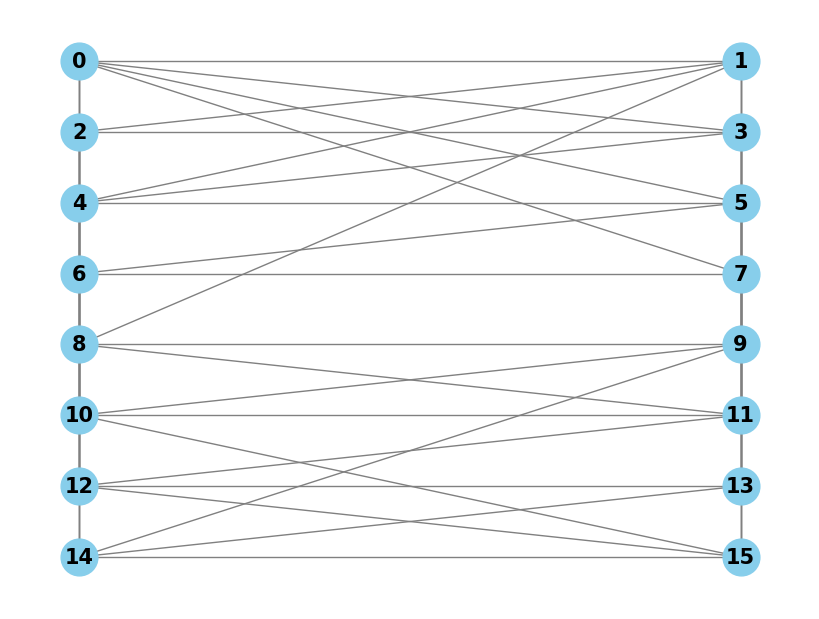

None


Matchings WITH relabeling: 10
Matchings: [{('1001', '1010'), ('0100', '0001'), ('0111', '1011'), ('0000', '0101'), ('0110', '1100'), ('1101', '1110'), ('0010', '1000')}, {('1001', '1110'), ('0001', '0010'), ('1000', '1011'), ('0101', '0110'), ('0100', '0111'), ('0000', '1010'), ('1100', '1111')}, {('0110', '1010'), ('0011', '1001'), ('1011', '1101'), ('0100', '0010'), ('0001', '1000'), ('0000', '1100')}, {('1010', '1100'), ('0111', '1101'), ('0000', '0110'), ('0100', '0011'), ('0101', '1001')}, {('1010', '1111'), ('0101', '1011'), ('0011', '0000')}, {('1011', '1100'), ('0011', '0101')}, {('1100', '1101'), ('0001', '0000'), ('1110', '1111'), ('0110', '0111'), ('0100', '0101'), ('1000', '1001'), ('0010', '0011'), ('1010', '1011')}, {('0001', '0101'), ('1010', '1110'), ('1001', '1101'), ('0011', '0111'), ('1000', '1100'), ('1011', '1111'), ('0010', '0110'), ('0100', '0000')}, {('1001', '1011'), ('1101', '1111'), ('1100', '1110'), ('0001', '0011'), ('1000', '1010'), ('0010', '0000'), ('01

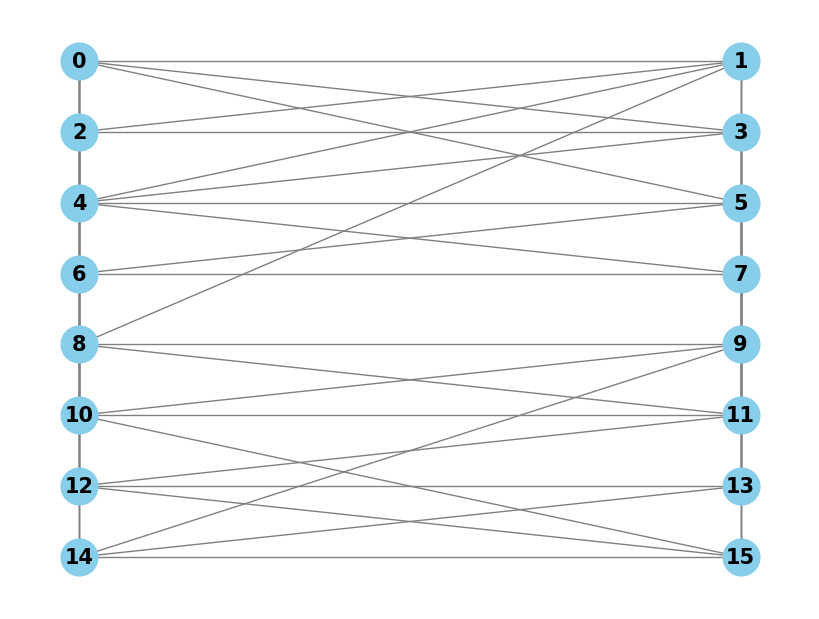

None


Sample Circuit - Matching WITH Relabeling (n_steps=1):


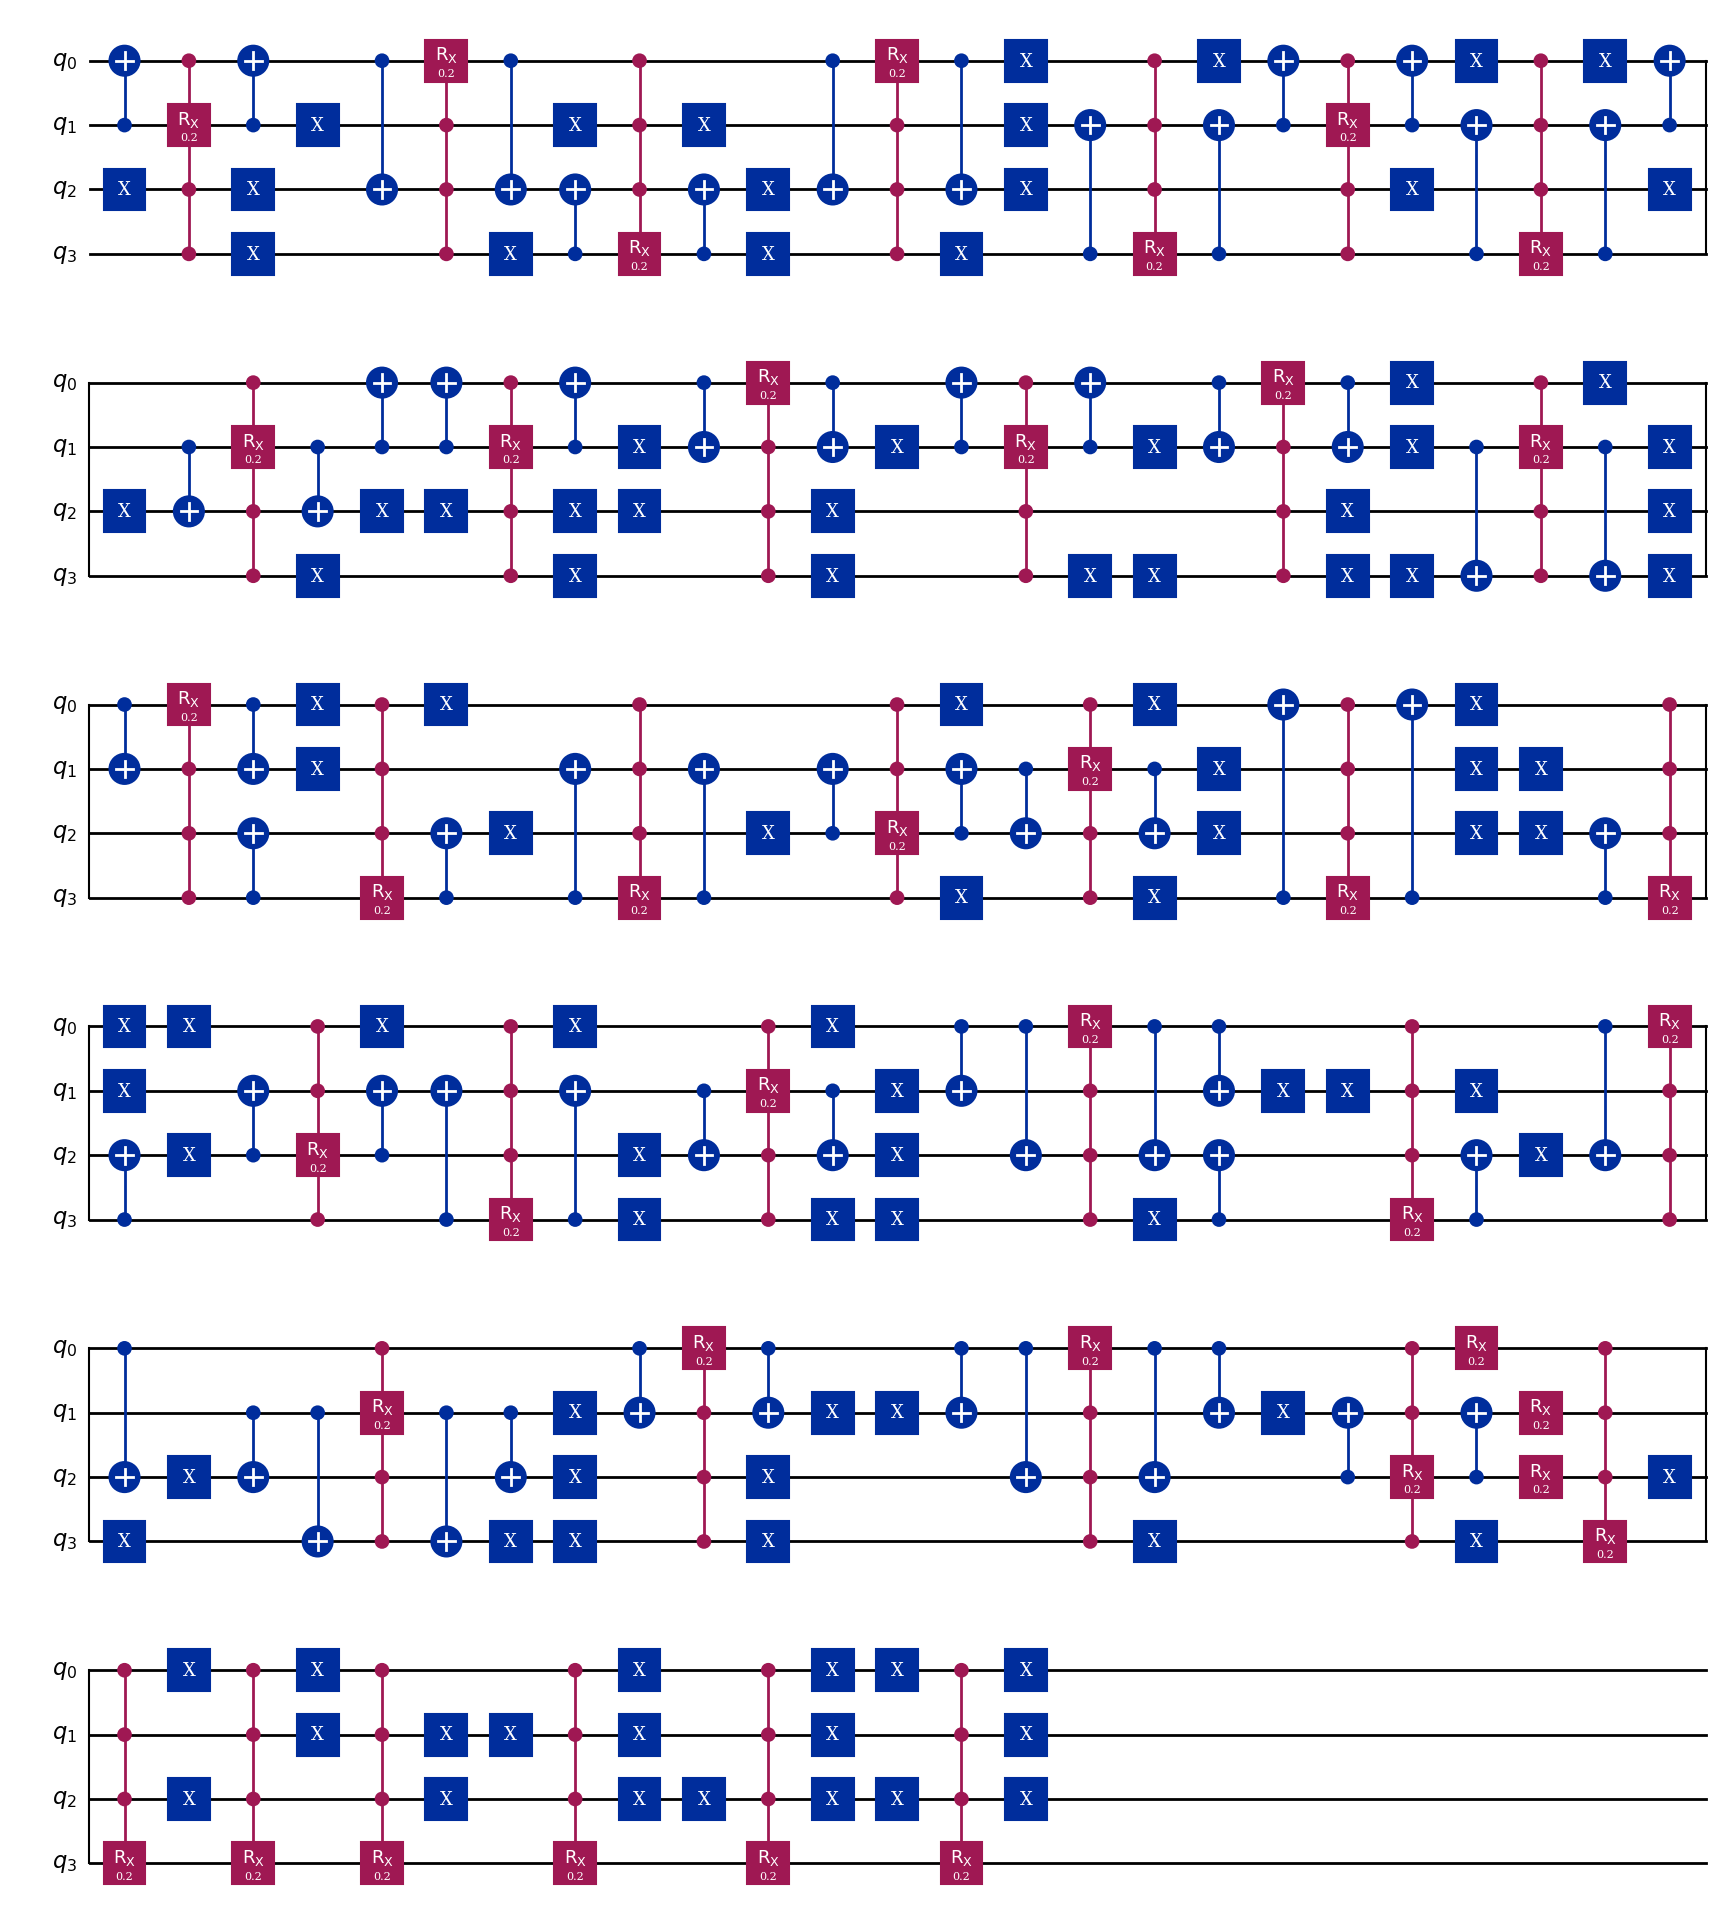


Sample Circuit - Matching WITHOUT Relabeling (n_steps=1):


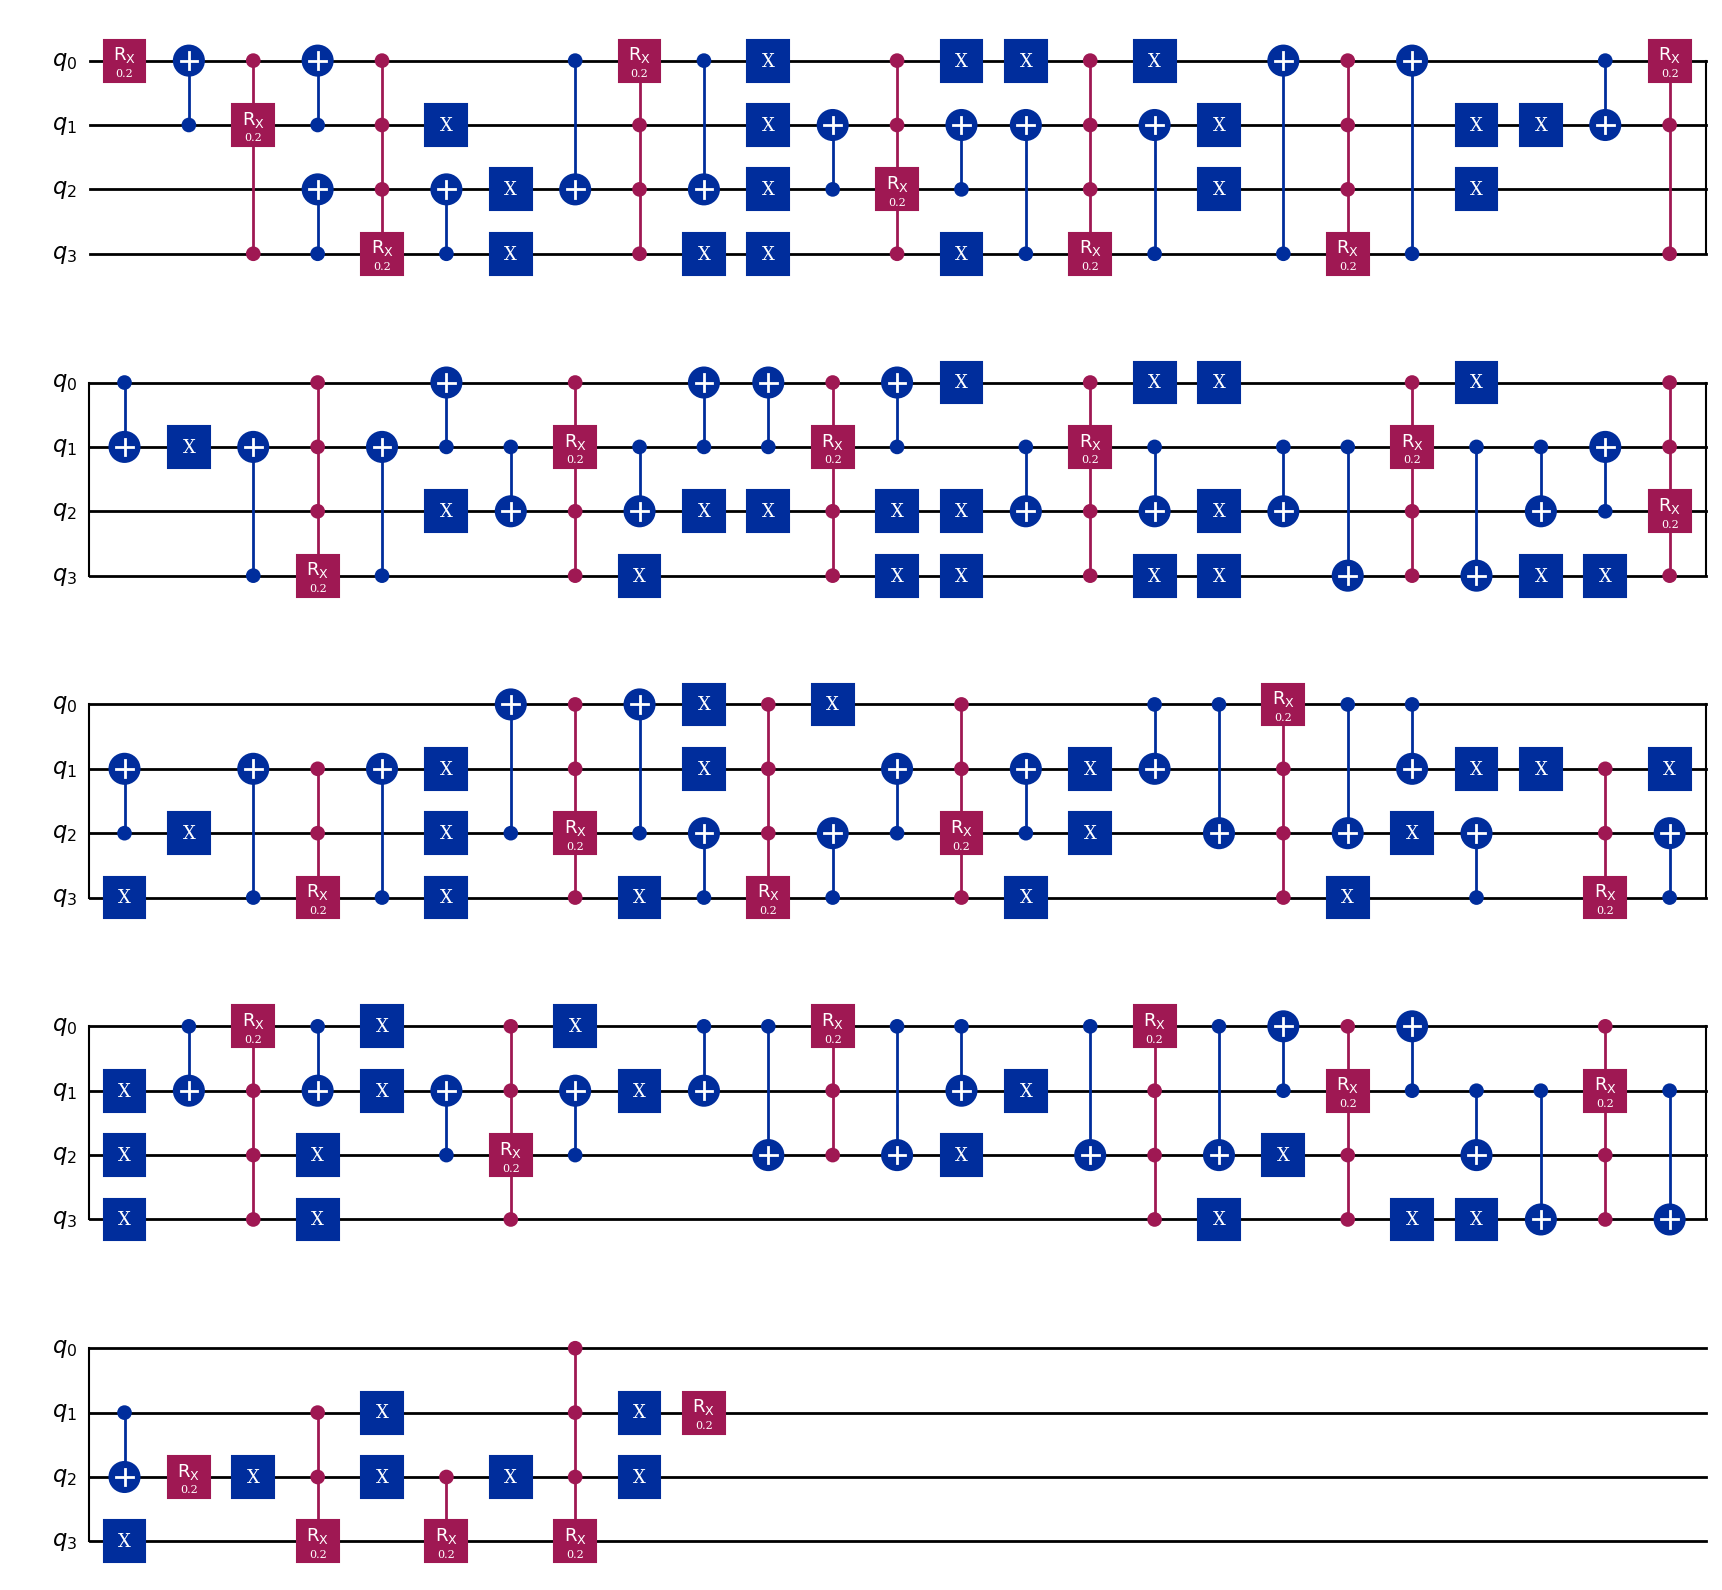


CX Gate Count Summary for Dense Non-Bipartite Graph (4 qubits):
n_steps  |   Matching w/ Relabel (No Opt/Opt)    | Matching No Relabel (No Opt/Opt)  | Pauli (No Opt/Opt) 
----------------------------------------------------------------------------------------------------
1        |  808/784                               |  812/785                           |  200/101 
2        | 1616/1568                              | 1624/1570                          |  400/202 
5        | 4040/3920                              | 4060/3925                          | 1000/505 
10       | 8080/7840                              | 8120/7850                          | 2000/1010
20       | 16160/15680                              | 16240/15700                          | 4000/2020
50       | 40400/39200                              | 40600/39250                          | 10000/5050
100      | 80800/78400                              | 81200/78500                          | 20000/10100
-------------------

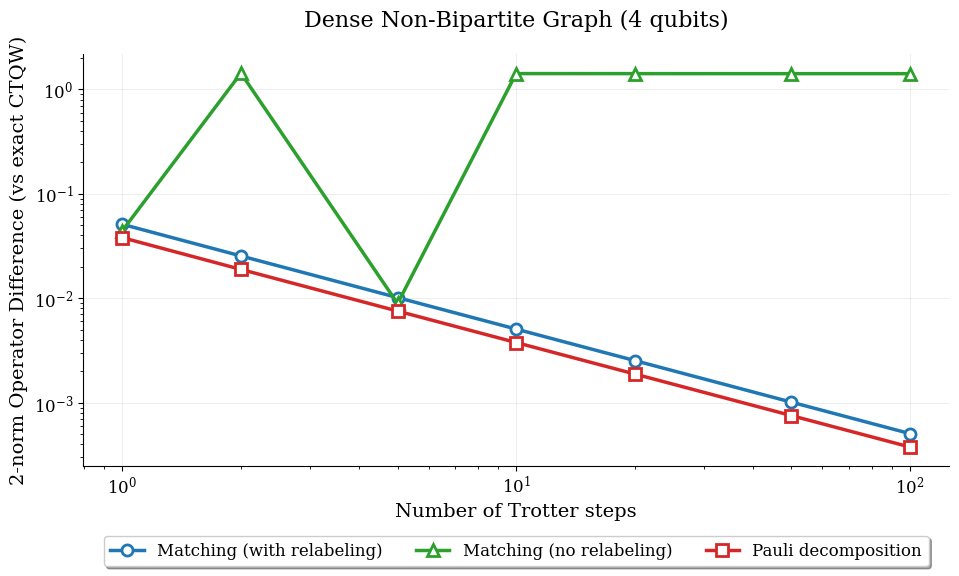

In [60]:
dense_nonbipartite_16 = {
    ('0000','0001'), ('0000','0010'), ('0000','0011'), ('0000','0100'), ('0000','0101'), ('0000','0110'), ('0000','0111'),
    ('0001','0010'), ('0001','0011'), ('0001','0100'), ('0001','0101'), ('0001','1000'), ('0001','1001'),
    ('0010','0011'), ('0010','0100'), ('0010','0110'), ('0010','1000'), ('0010','1010'),
    ('0011','0100'), ('0011','0101'), ('0011','0111'), ('0011','1001'), ('0011','1011'),
    ('0100','0101'), ('0100','0110'), ('0100','1000'), ('0100','1010'), ('0100','1100'),
    ('0101','0110'), ('0101','0111'), ('0101','1001'), ('0101','1011'), ('0101','1101'),
    ('0110','0111'), ('0110','1010'), ('0110','1100'), ('0110','1110'),
    ('0111','1011'), ('0111','1101'), ('0111','1111'),
    ('1000','1001'), ('1000','1010'), ('1000','1011'), ('1000','1100'),
    ('1001','1010'), ('1001','1011'), ('1001','1101'), ('1001','1110'),
    ('1010','1011'), ('1010','1100'), ('1010','1110'), ('1010','1111'),
    ('1011','1100'), ('1011','1101'), ('1011','1111'),
    ('1100','1101'), ('1100','1110'), ('1100','1111'),
    ('1101','1110'), ('1101','1111'),
    ('1110','1111')
}
analyze_and_plot(dense_nonbipartite_16, "Dense Non-Bipartite Graph (4 qubits)")


Dense Bipartite Graph (4 qubits)
Original edges: {('0011', '1110'), ('0011', '1001'), ('0110', '1100'), ('0100', '1111'), ('0001', '1100'), ('0000', '1101'), ('0100', '1010'), ('0010', '1001'), ('0101', '1110'), ('0010', '1010'), ('0101', '1001'), ('0011', '1101'), ('0110', '1110'), ('0110', '1001'), ('0011', '1000'), ('0101', '1101'), ('0001', '1110'), ('0001', '1001'), ('0100', '1101'), ('0010', '1000'), ('0111', '1111'), ('0101', '1000'), ('0111', '1010'), ('0001', '1101'), ('0110', '1000'), ('0010', '1011'), ('0000', '1111'), ('0100', '1100'), ('0000', '1010'), ('0010', '1100'), ('0011', '1111'), ('0111', '1011'), ('0011', '1010'), ('0010', '1111'), ('0101', '1111'), ('0101', '1010'), ('0100', '1110'), ('0100', '1001'), ('0010', '1110'), ('0000', '1000'), ('0110', '1111'), ('0110', '1010'), ('0001', '1111'), ('0111', '1100'), ('0001', '1010'), ('0010', '1101'), ('0000', '1011'), ('0100', '1000'), ('0011', '1011'), ('0110', '1101'), ('0111', '1110'), ('0111', '1001'), ('0101', '101

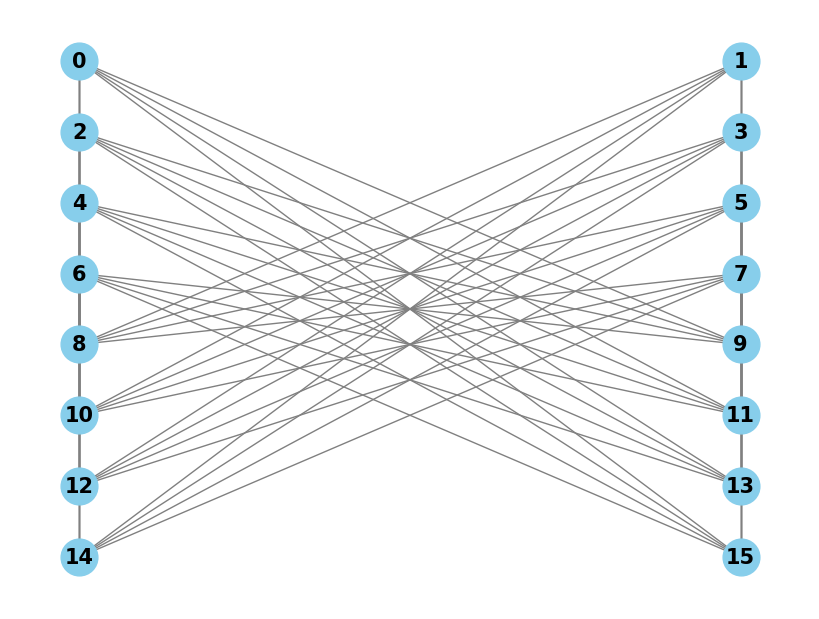

None


Matchings WITH relabeling: 10
Matchings: [{('1110', '0100'), ('0101', '1000'), ('0110', '1101'), ('1100', '0001'), ('1011', '0111'), ('0000', '1010'), ('0011', '1111'), ('1001', '0010')}, {('0110', '1111'), ('1011', '1000'), ('1001', '1010'), ('1110', '0111'), ('0101', '0010'), ('0000', '1101'), ('0011', '0100')}, {('0011', '1000'), ('1001', '0100'), ('1011', '0010'), ('1110', '0001'), ('0101', '1010'), ('0000', '0111'), ('1100', '1111')}, {('0011', '1010'), ('1100', '0111'), ('1110', '0010'), ('1011', '1101'), ('0110', '0001'), ('1001', '1111')}, {('0011', '1101'), ('1100', '0010'), ('1011', '0001'), ('1001', '0111'), ('0110', '1010'), ('0000', '1111'), ('1110', '1000')}, {('1100', '1010'), ('1011', '0100'), ('1110', '1101'), ('0101', '1111'), ('0110', '1000')}, {('0101', '0001'), ('0110', '0010'), ('1001', '1101'), ('0011', '0111'), ('0000', '0100'), ('1011', '1111'), ('1110', '1010'), ('1100', '1000')}, {('1001', '0001'), ('0101', '1101'), ('0000', '1000'), ('1100', '0100')}, {('00

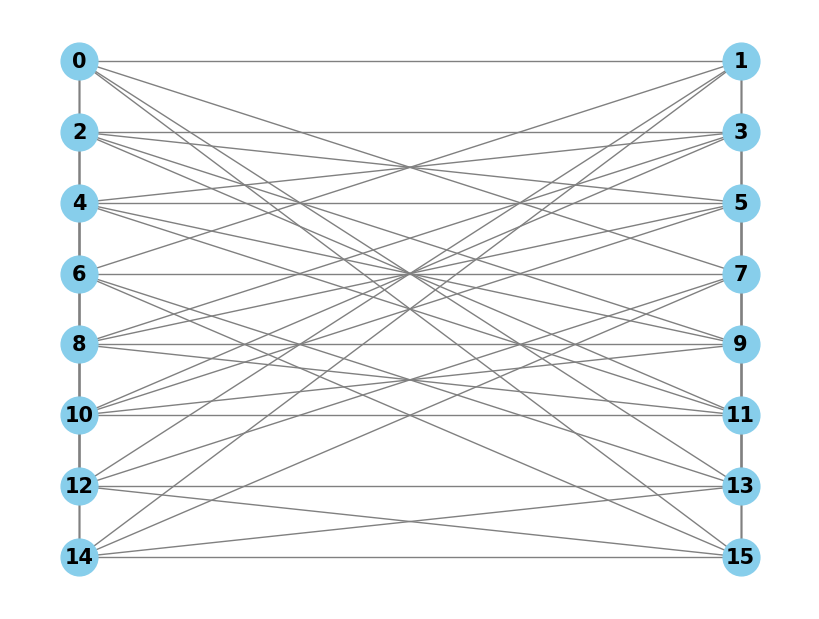

None


Sample Circuit - Matching WITH Relabeling (n_steps=1):


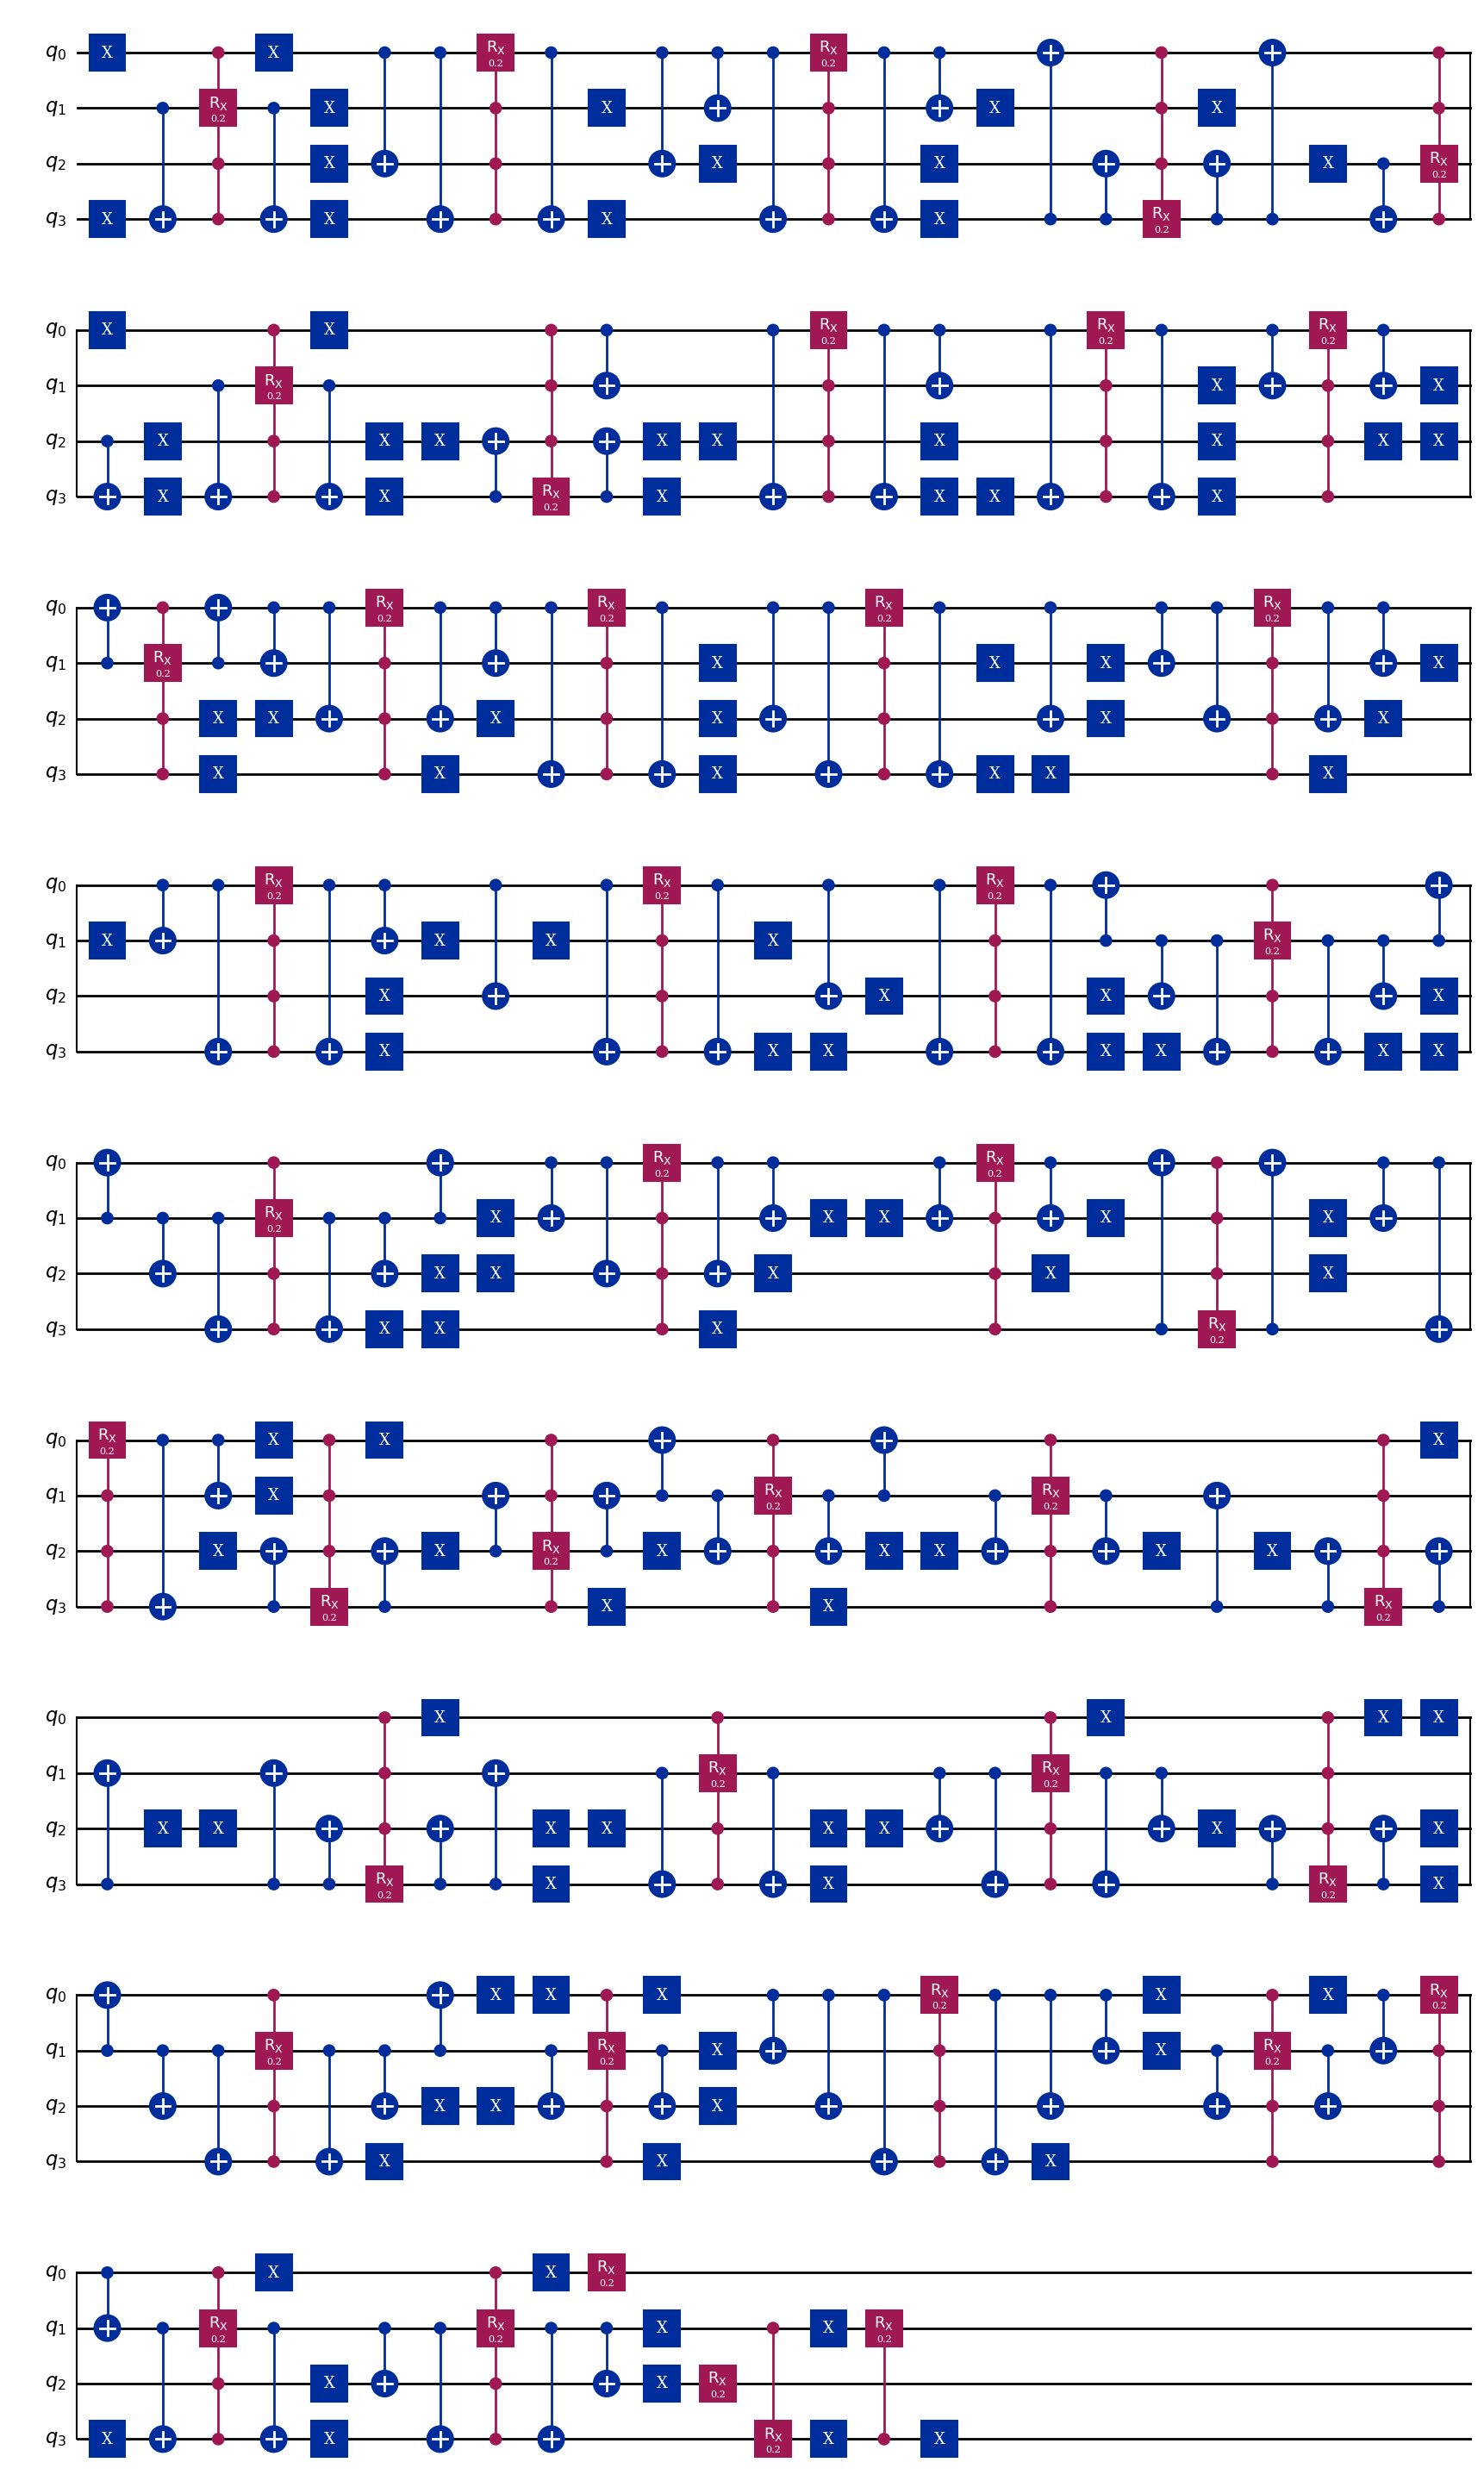


Sample Circuit - Matching WITHOUT Relabeling (n_steps=1):


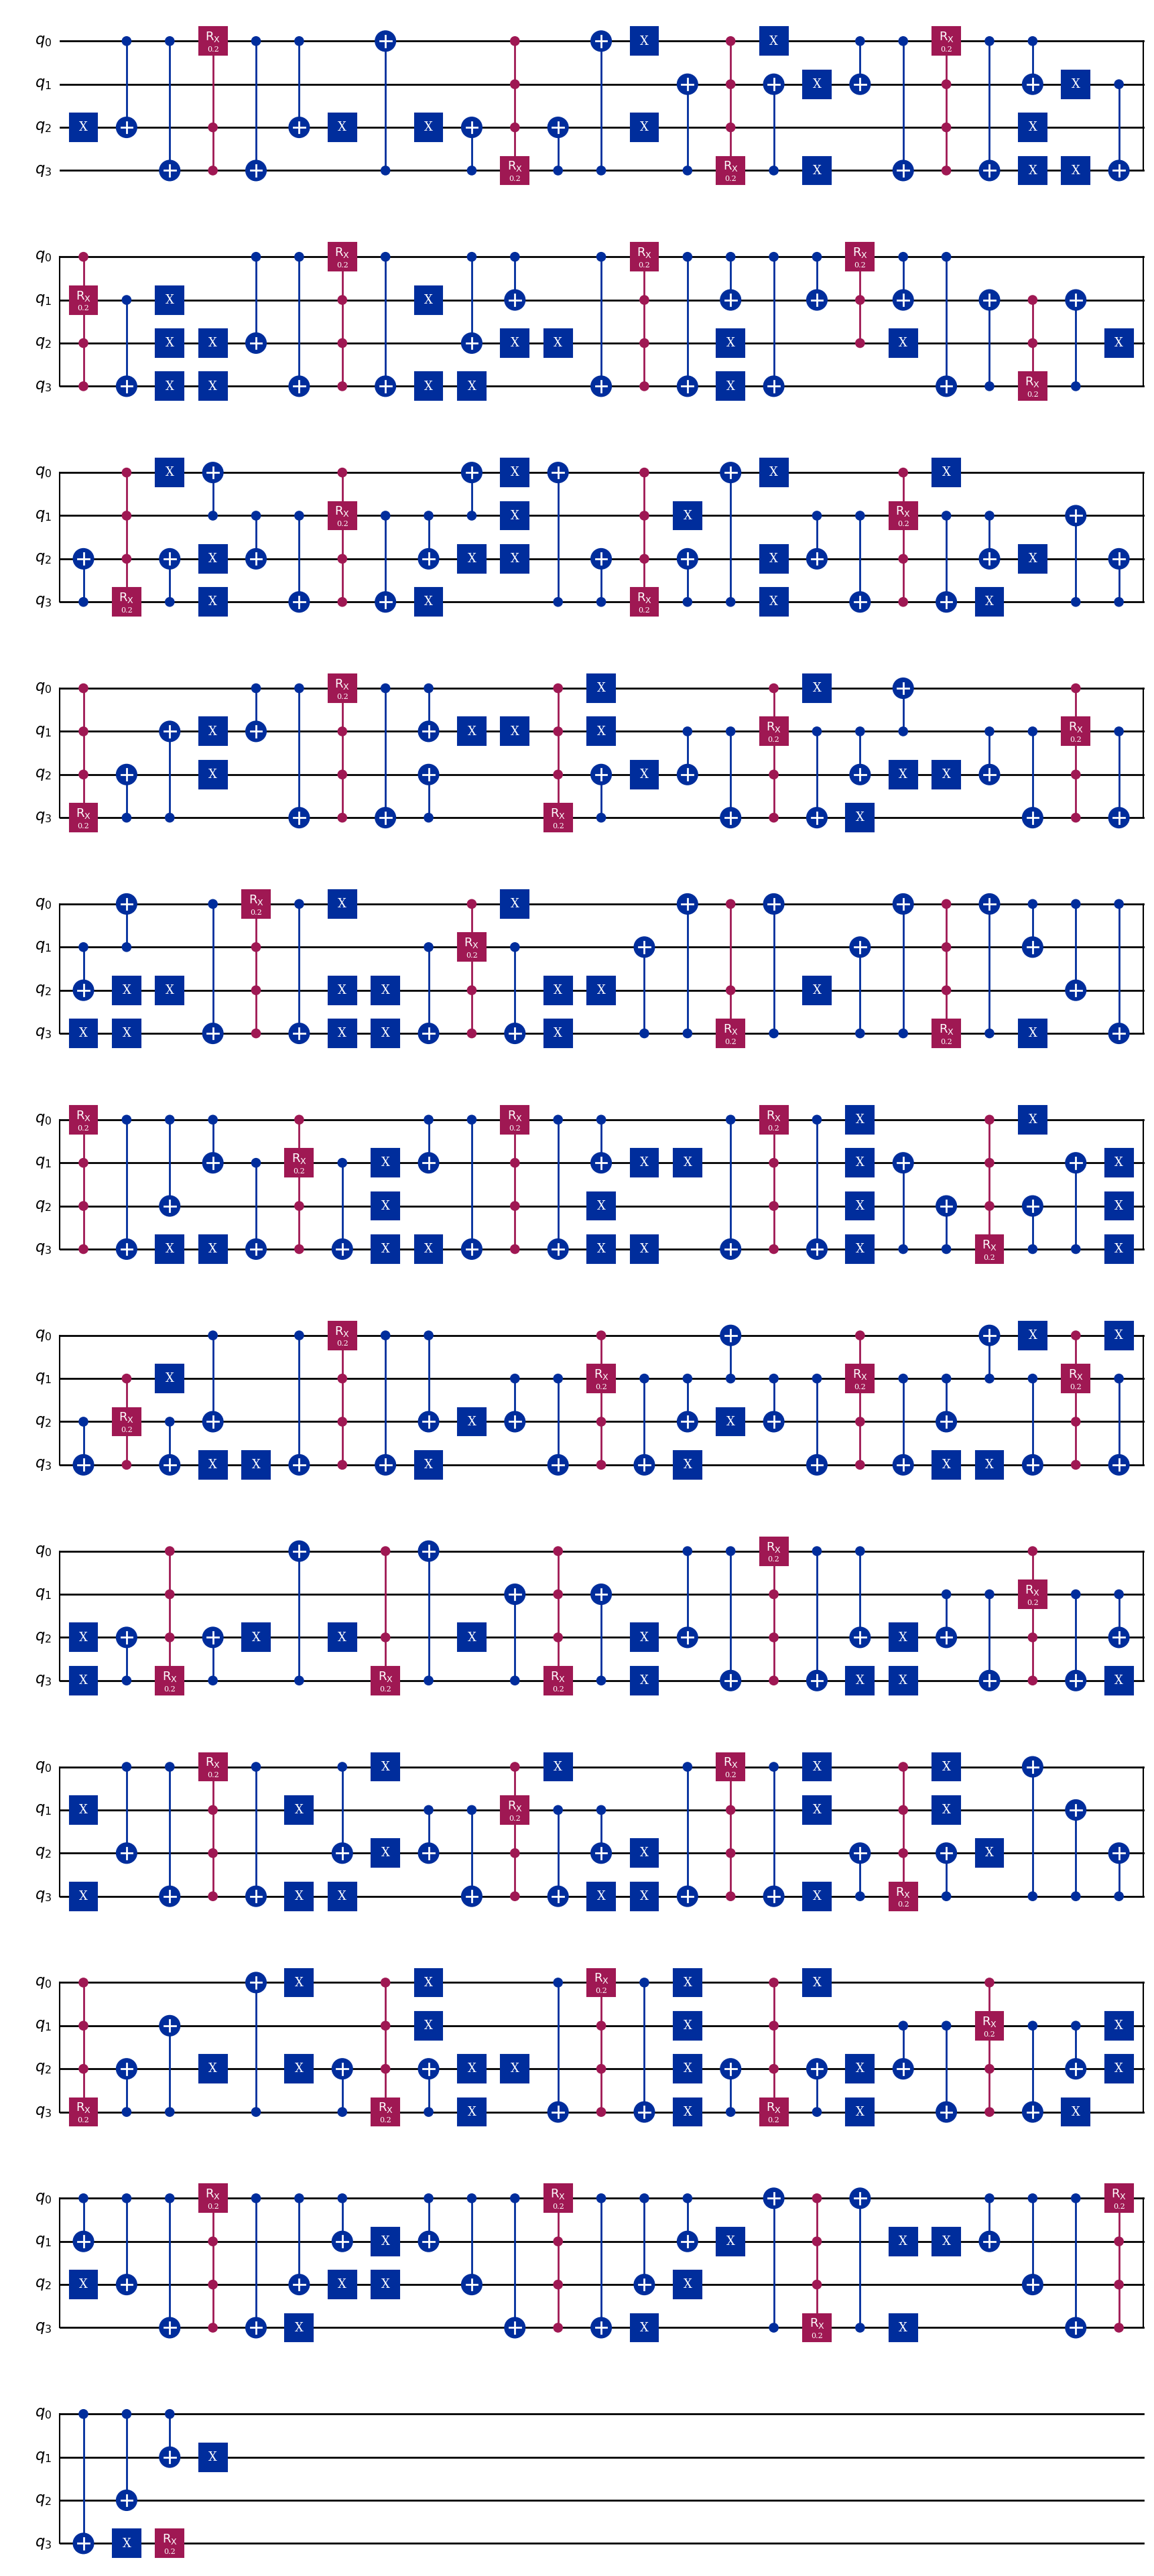

In [ ]:
dense_bipartite_16 = {
    ('0000','1000'), ('0000','1001'), ('0000','1010'), ('0000','1011'), ('0000','1100'), ('0000','1101'), ('0000','1110'), ('0000','1111'),
    ('0001','1000'), ('0001','1001'), ('0001','1010'), ('0001','1011'), ('0001','1100'), ('0001','1101'), ('0001','1110'), ('0001','1111'),
    ('0010','1000'), ('0010','1001'), ('0010','1010'), ('0010','1011'), ('0010','1100'), ('0010','1101'), ('0010','1110'), ('0010','1111'),
    ('0011','1000'), ('0011','1001'), ('0011','1010'), ('0011','1011'), ('0011','1100'), ('0011','1101'), ('0011','1110'), ('0011','1111'),
    ('0100','1000'), ('0100','1001'), ('0100','1010'), ('0100','1011'), ('0100','1100'), ('0100','1101'), ('0100','1110'), ('0100','1111'),
    ('0101','1000'), ('0101','1001'), ('0101','1010'), ('0101','1011'), ('0101','1100'), ('0101','1101'), ('0101','1110'), ('0101','1111'),
    ('0110','1000'), ('0110','1001'), ('0110','1010'), ('0110','1011'), ('0110','1100'), ('0110','1101'), ('0110','1110'), ('0110','1111'),
    ('0111','1000'), ('0111','1001'), ('0111','1010'), ('0111','1011'), ('0111','1100'), ('0111','1101'), ('0111','1110'), ('0111','1111')
}

analyze_and_plot(dense_bipartite_16, "Dense Bipartite Graph (4 qubits)")


Sparse Non-Bipartite Graph (4 qubits)
Original edges: {('0111', '0110'), ('0000', '0100'), ('0010', '0110'), ('0001', '0100'), ('0010', '0011'), ('0001', '0011'), ('1010', '0101')}
Number of qubits: 4

Original Graph:


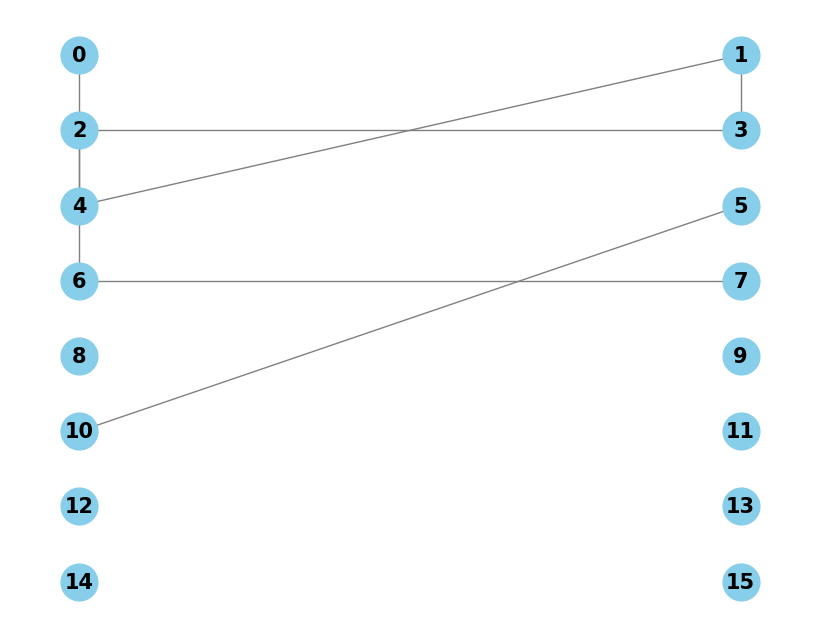

None


Matchings WITH relabeling: 4
Matchings: [{('0111', '0110'), ('0101', '0100'), ('0010', '0011')}, {('0010', '0110')}, {('1010', '0000'), ('0001', '0100')}, {('0001', '0011')}]
Relabeled edges: {('0111', '0110'), ('0101', '0100'), ('1010', '0000'), ('0001', '0100'), ('0010', '0110'), ('0010', '0011'), ('0001', '0011')}

Matchings WITHOUT relabeling: 3
Matchings: [{('0111', '0110'), ('0010', '0011'), ('1010', '0101'), ('0001', '0100')}, {('0000', '0100'), ('0010', '0110')}, {('0001', '0011')}]
Number of qubits: 4

Hamming Cost Analysis:
With Relabeling: Total = 9, Edges = 7, Per Edge = 1.286
No Relabeling: Total = 11, Edges = 7, Per Edge = 1.571

Relabeled Graph:


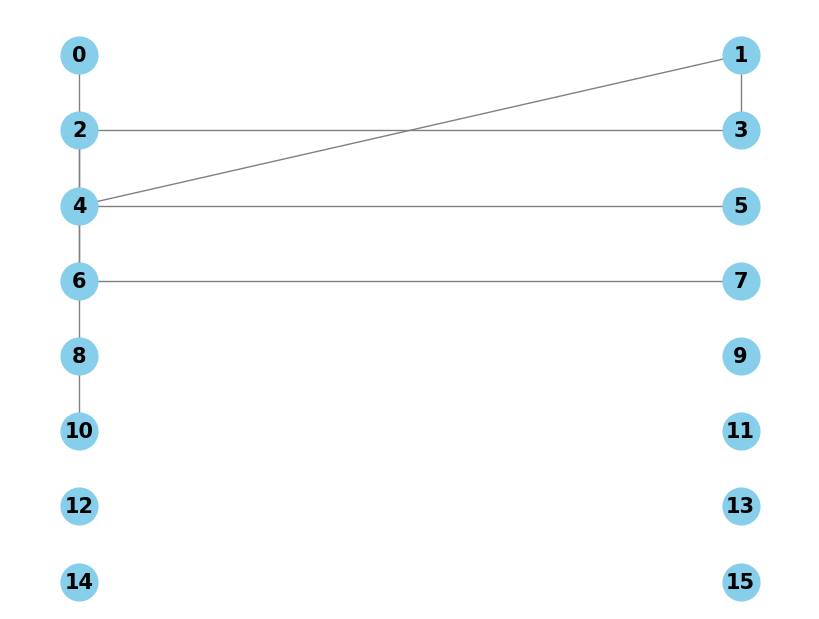

None


Sample Circuit - Matching WITH Relabeling (n_steps=1):


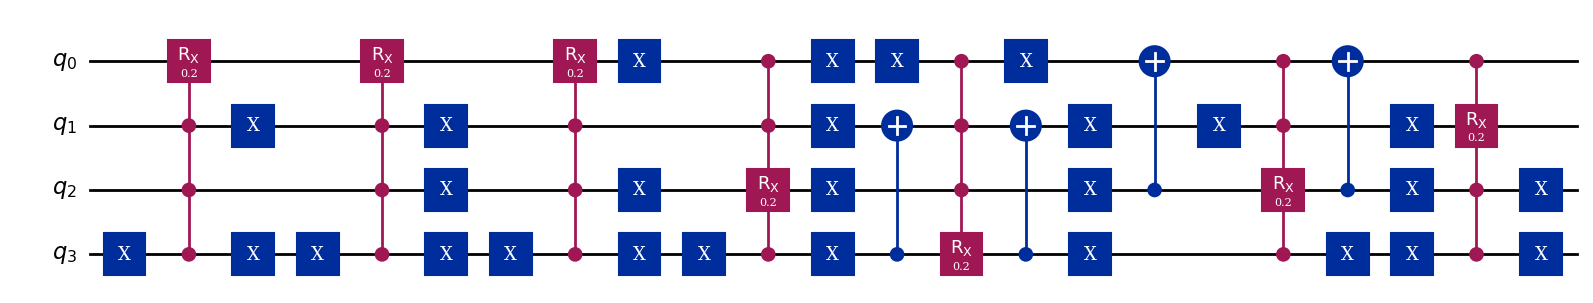


Sample Circuit - Matching WITHOUT Relabeling (n_steps=1):


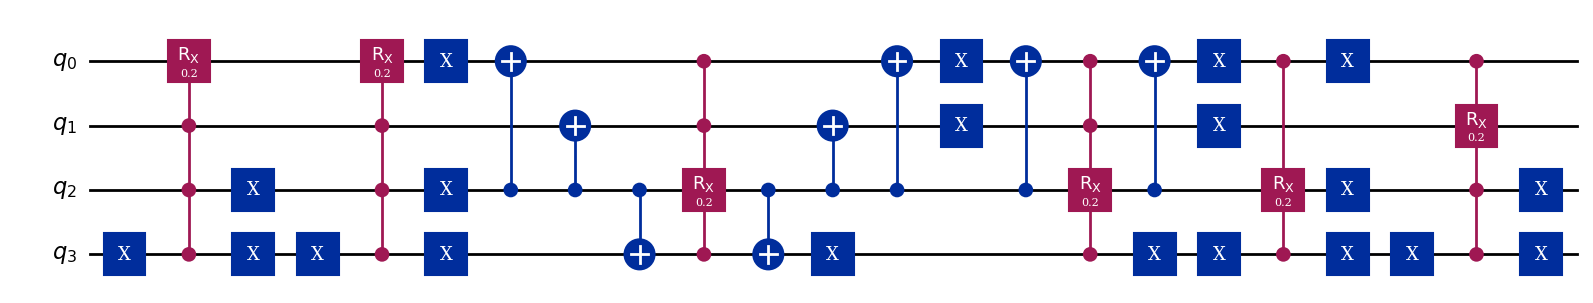


CX Gate Count Summary for Sparse Non-Bipartite Graph (4 qubits):
n_steps  |   Matching w/ Relabel (No Opt/Opt)    | Matching No Relabel (No Opt/Opt)  | Pauli (No Opt/Opt) 
----------------------------------------------------------------------------------------------------
1        |  144/143                               |  116/112                           |  120/80  
2        |  288/286                               |  232/224                           |  240/160 
5        |  720/715                               |  580/560                           |  600/400 
10       | 1440/1430                              | 1160/1120                          | 1200/800 
20       | 2880/2860                              | 2320/2240                          | 2400/1600
50       | 7200/7150                              | 5800/5600                          | 6000/4000
100      | 14400/14300                              | 11600/11200                          | 12000/8000
----------------------------

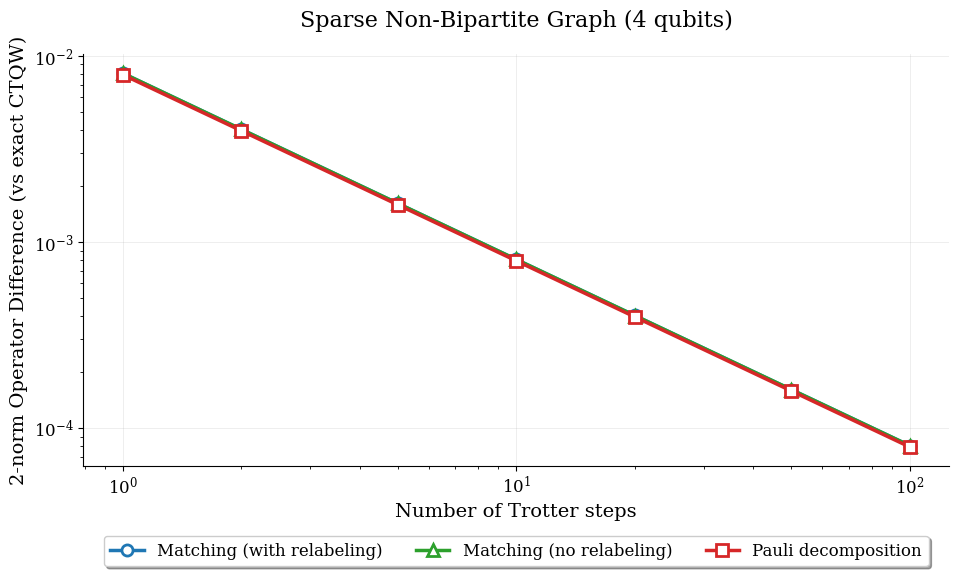

In [ ]:
sparse_nonbipartite_16 = {
    ('0000','0100'),  # H=1, start cluster in 0xxx
    ('0001','0100'),  # H=2, degree-2 at 0100
    ('0001','0011'),  # H=1, degree-2 at 0001
    ('0010','0011'),  # H=1, degree-2 at 0011
    ('0010','0110'),  # H=1, degree-2 at 0010
    ('0111','0110'),  # H=1, degree-2 at 0110
    ('1010','0101'),  # H=3, high-Hamming bridge to 1xxx
}

analyze_and_plot(sparse_nonbipartite_16, "Sparse Non-Bipartite Graph (4 qubits)")


Sparse Bipartite Graph (4 qubits)
Original edges: {('1110', '1101'), ('0100', '0111'), ('0100', '0011'), ('1010', '1101'), ('0010', '0101'), ('1100', '1011'), ('0010', '0001'), ('0110', '1001'), ('1000', '0111'), ('1000', '1011'), ('0000', '0011'), ('0110', '0101'), ('1100', '1111'), ('1010', '1001'), ('0000', '0001')}
Number of qubits: 4

Original Graph:


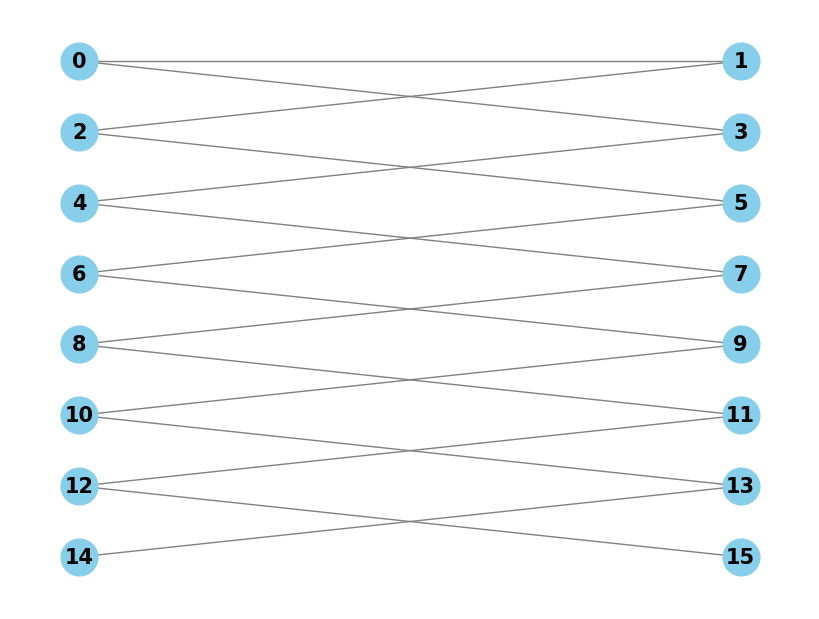

None


Matchings WITH relabeling: 3
Matchings: [{('0111', '0110'), ('1110', '1111'), ('1000', '1001'), ('1101', '1100'), ('0011', '0010'), ('1010', '1011'), ('0101', '0100'), ('0001', '0000')}, {('0101', '1011'), ('1000', '0100'), ('1010', '0110'), ('1110', '0000'), ('0001', '1100'), ('0011', '1001')}, {('0111', '1111')}]
Relabeled edges: {('0111', '0110'), ('1110', '1111'), ('1000', '1001'), ('0101', '1011'), ('1101', '1100'), ('1000', '0100'), ('0011', '0010'), ('0111', '1111'), ('1010', '1011'), ('0101', '0100'), ('1010', '0110'), ('1110', '0000'), ('0001', '1100'), ('0011', '1001'), ('0001', '0000')}

Matchings WITHOUT relabeling: 4
Matchings: [{('1110', '1101'), ('0100', '0111'), ('0010', '0101'), ('1100', '1011'), ('0110', '1001'), ('0000', '0011')}, {('1010', '1101'), ('0010', '0001'), ('1000', '0111'), ('0110', '0101'), ('1100', '1111'), ('0100', '0011')}, {('1010', '1001'), ('1000', '1011')}, {('0000', '0001')}]
Number of qubits: 4

Hamming Cost Analysis:
With Relabeling: Total = 24

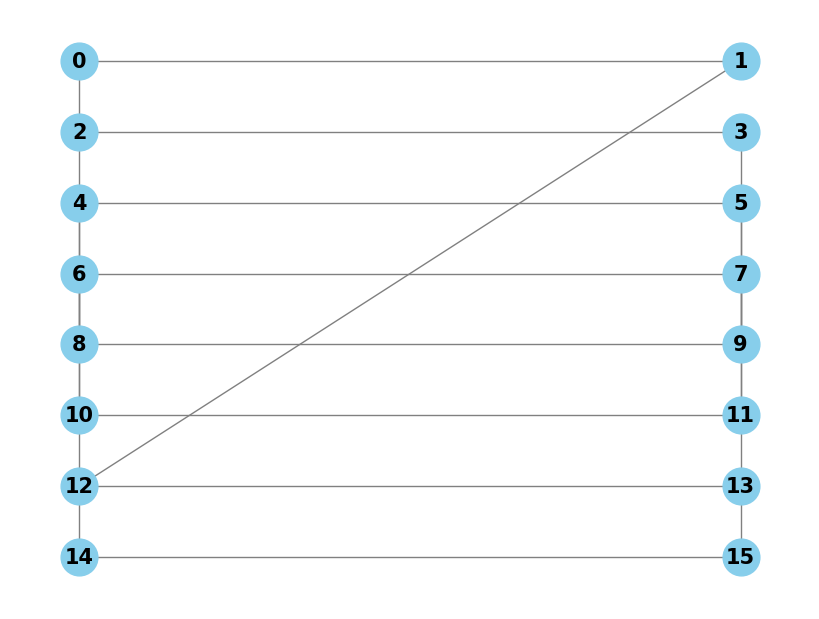

None


Sample Circuit - Matching WITH Relabeling (n_steps=1):


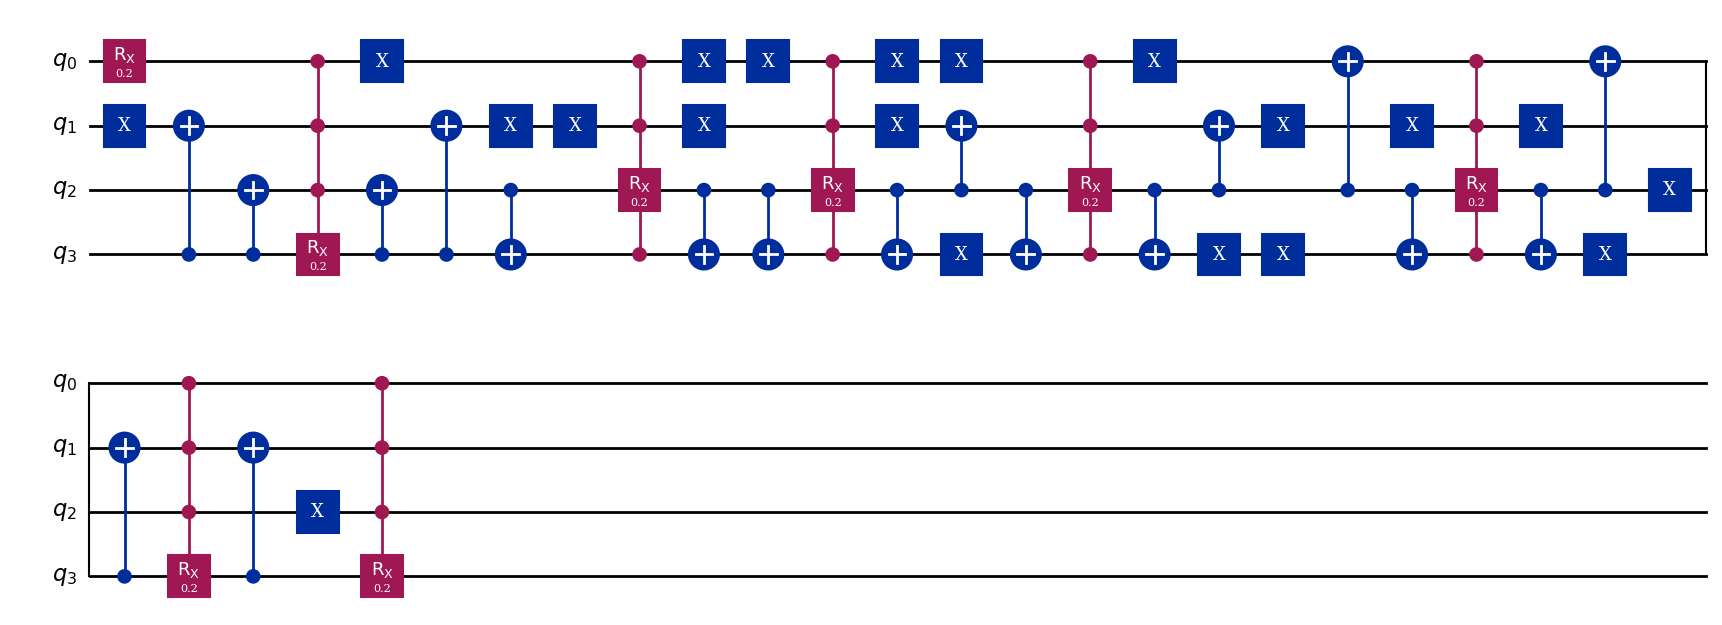


Sample Circuit - Matching WITHOUT Relabeling (n_steps=1):


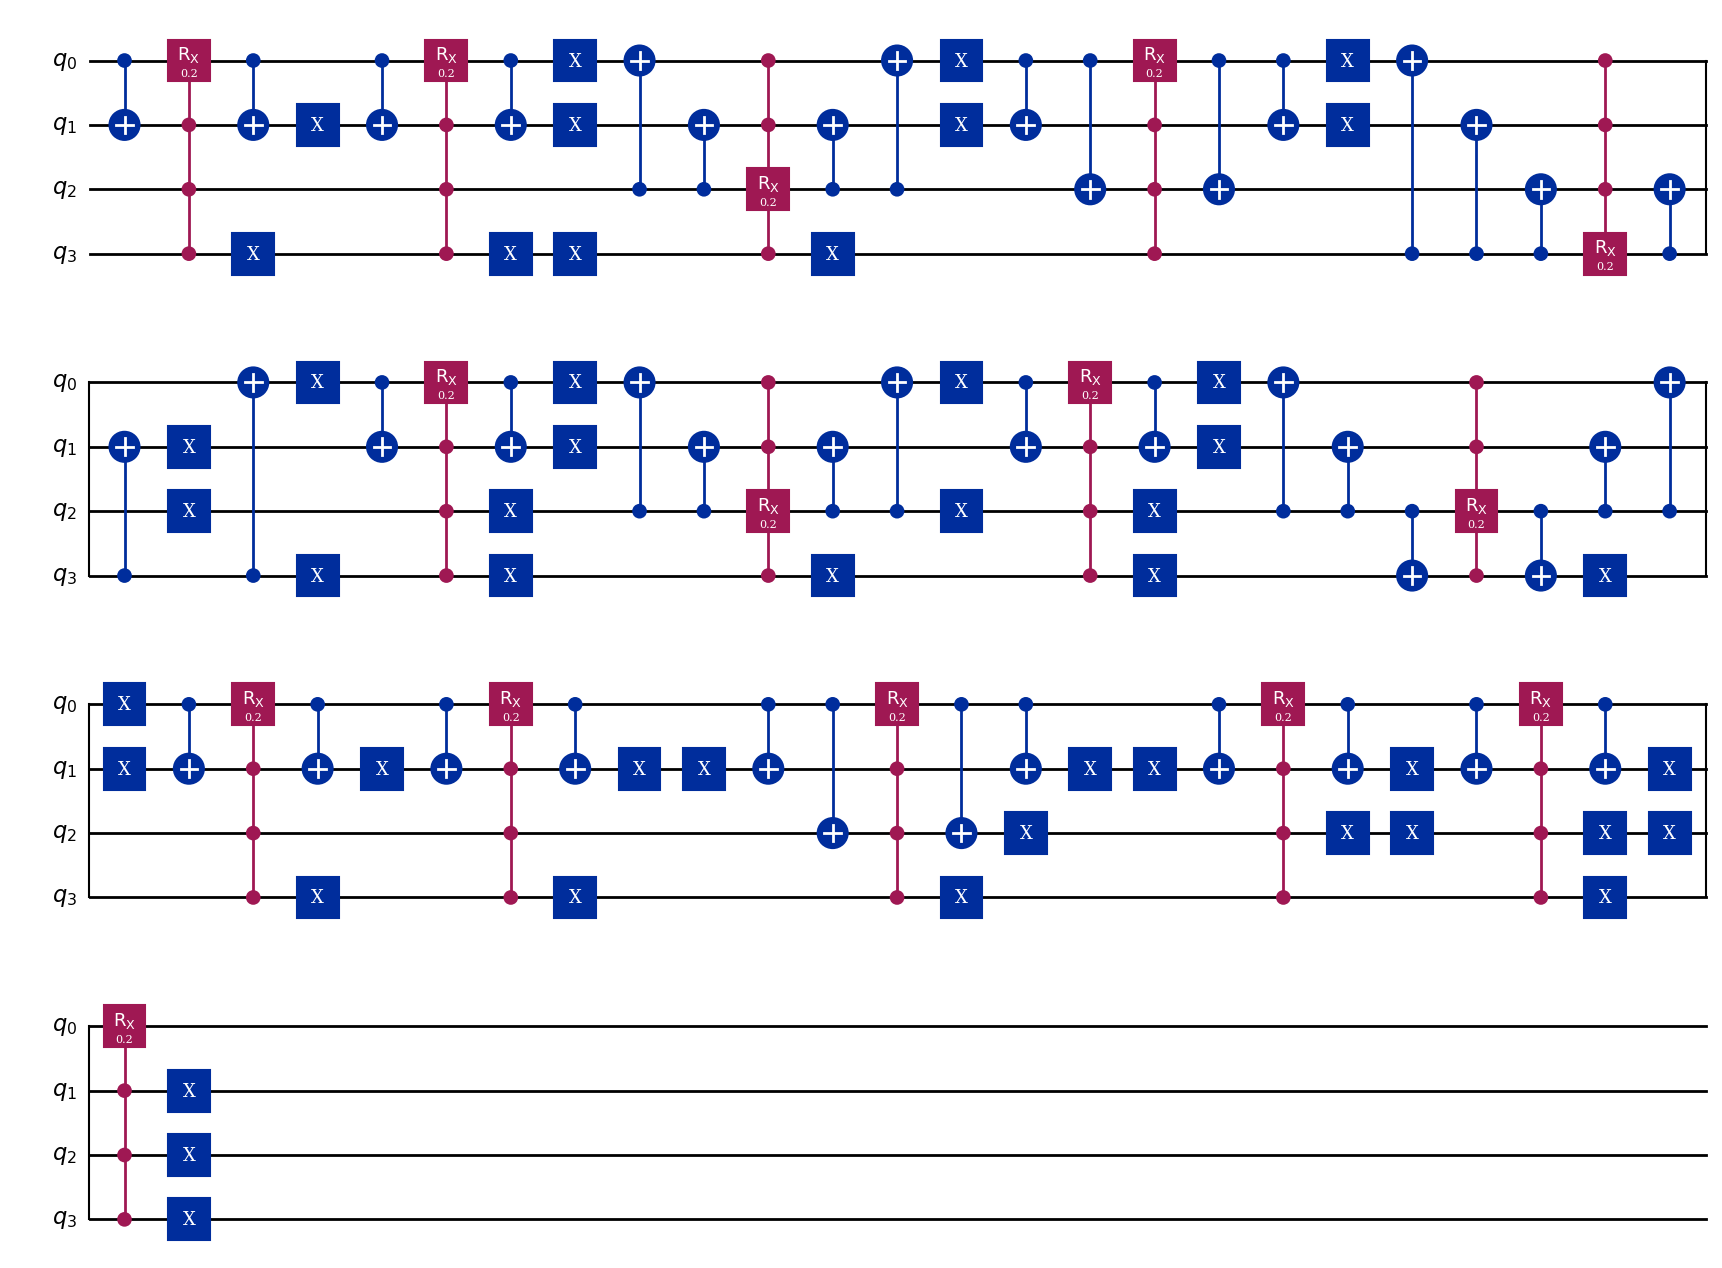


CX Gate Count Summary for Sparse Bipartite Graph (4 qubits):
n_steps  |   Matching w/ Relabel (No Opt/Opt)    | Matching No Relabel (No Opt/Opt)  | Pauli (No Opt/Opt) 
----------------------------------------------------------------------------------------------------
1        |  158/150                               |  344/328                           |   58/52  
2        |  316/300                               |  688/655                           |  116/104 
5        |  790/750                               | 1720/1636                          |  290/260 
10       | 1580/1500                              | 3440/3271                          |  580/520 
20       | 3160/3000                              | 6880/6541                          | 1160/1040
50       | 7900/7500                              | 17200/16351                          | 2900/2600
100      | 15800/15000                              | 34400/32701                          | 5800/5200
-------------------------------

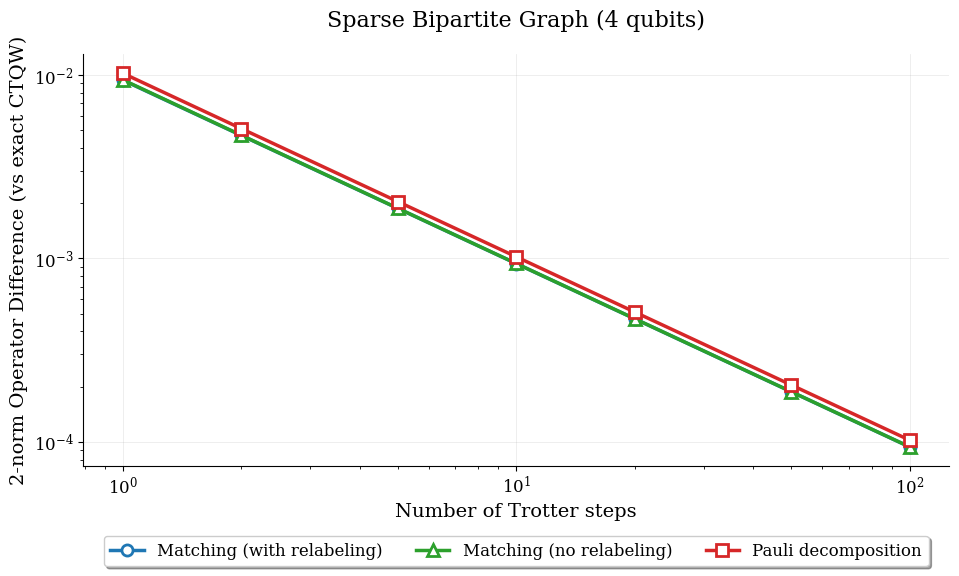

In [ ]:
sparse_bipartite_16 = {
    ('0000','0001'), ('0000','0011'),
    ('0010','0001'), ('0010','0101'),
    ('0100','0011'), ('0100','0111'),
    ('0110','0101'), ('0110','1001'),
    ('1000','0111'), ('1000','1011'),
    ('1010','1001'), ('1010','1101'),
    ('1100','1011'), ('1100','1111'),
    ('1110','1101')
}

analyze_and_plot(sparse_bipartite_16, "Sparse Bipartite Graph (4 qubits)")


Sparse Non Bipartite Graph (5 qubits)
Original edges: {('01001', '01011'), ('00100', '00101'), ('00100', '00011'), ('00010', '00011'), ('01000', '00111'), ('00110', '00101'), ('00000', '00001'), ('00010', '00001'), ('10000', '01111')}
Number of qubits: 5

Original Graph:


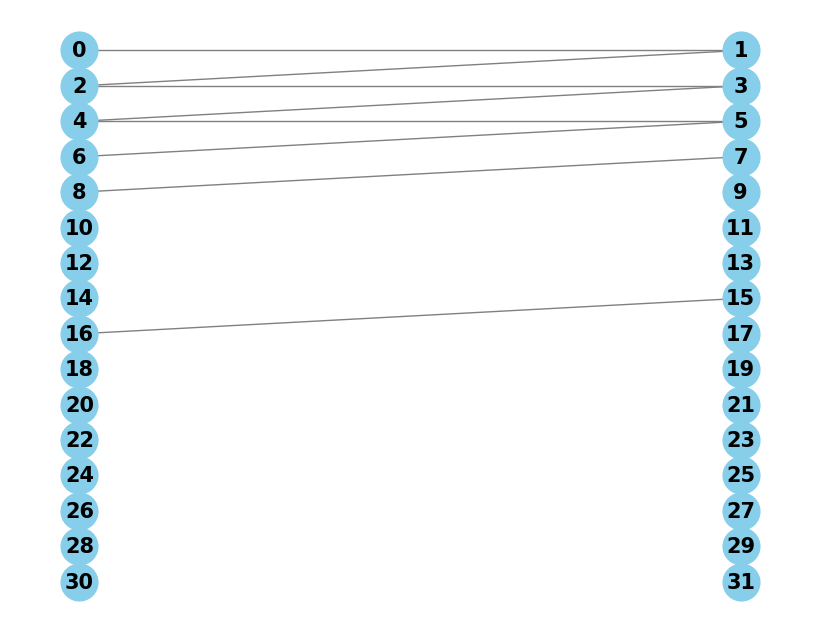

None


Matchings WITH relabeling: 4
Matchings: [{('00100', '00101'), ('00001', '00000'), ('01011', '01010'), ('00011', '00010'), ('01001', '01000'), ('00110', '00111')}, {('01100', '00111')}, {('01100', '00101')}, {('00100', '00000')}]
Relabeled edges: {('00100', '00101'), ('00001', '00000'), ('01011', '01010'), ('00100', '00000'), ('01100', '00101'), ('00011', '00010'), ('01100', '00111'), ('01001', '01000'), ('00110', '00111')}

Matchings WITHOUT relabeling: 2
Matchings: [{('01001', '01011'), ('00100', '00011'), ('01000', '00111'), ('00110', '00101'), ('00010', '00001'), ('10000', '01111')}, {('00010', '00011'), ('00100', '00101'), ('00000', '00001')}]
Number of qubits: 5

Hamming Cost Analysis:
With Relabeling: Total = 12, Edges = 9, Per Edge = 1.333
No Relabeling: Total = 20, Edges = 9, Per Edge = 2.222

Relabeled Graph:


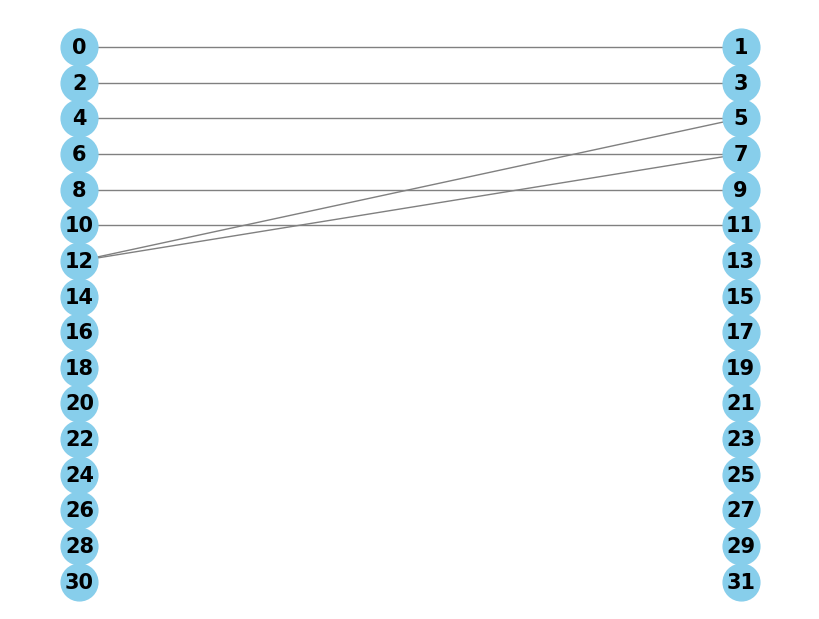

None


Sample Circuit - Matching WITH Relabeling (n_steps=1):


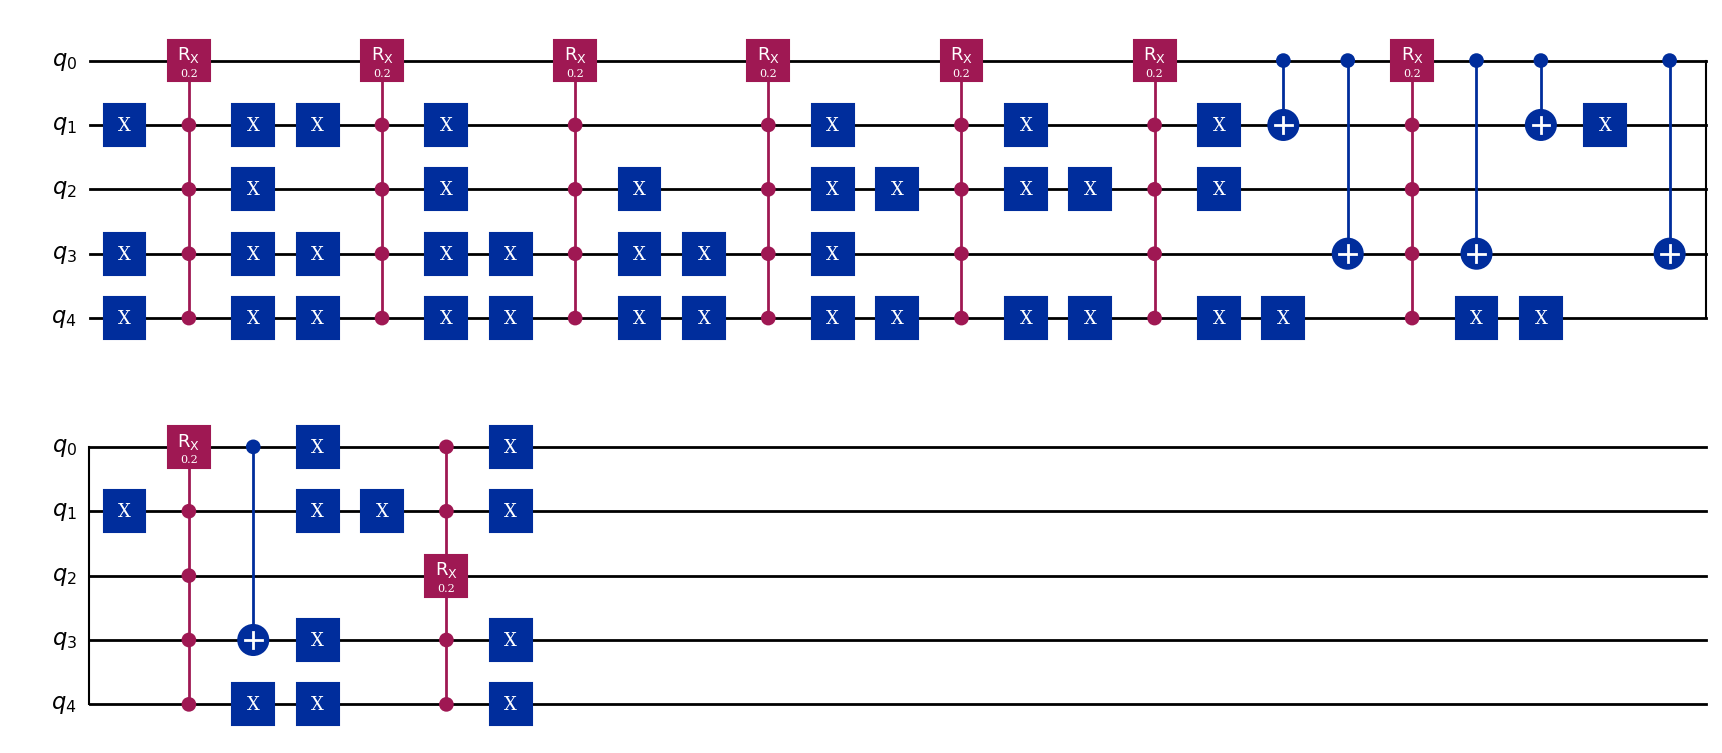


Sample Circuit - Matching WITHOUT Relabeling (n_steps=1):


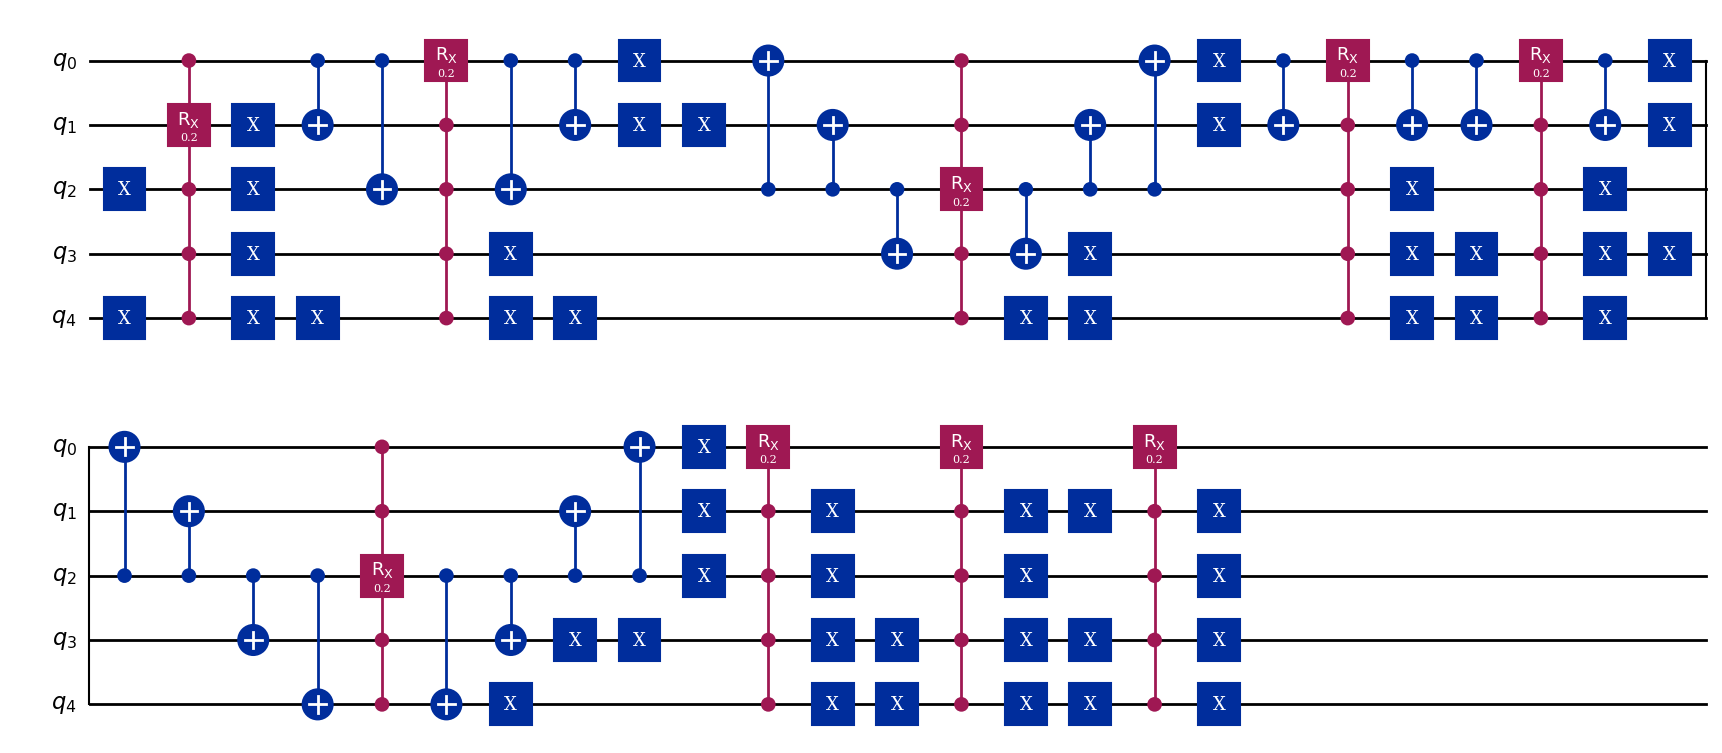


CX Gate Count Summary for Sparse Non Bipartite Graph (5 qubits):
n_steps  |   Matching w/ Relabel (No Opt/Opt)    | Matching No Relabel (No Opt/Opt)  | Pauli (No Opt/Opt) 
----------------------------------------------------------------------------------------------------
1        |  222/218                               |  238/232                           |  496/276 
2        |  444/436                               |  476/462                           |  992/552 
5        | 1110/1090                              | 1190/1152                          | 2480/1380
10       | 2220/2180                              | 2380/2302                          | 4960/2760
20       | 4440/4360                              | 4760/4602                          | 9920/5520
50       | 11100/10900                              | 11900/11502                          | 24800/13800
100      | 22200/21800                              | 23800/23002                          | 49600/27600
---------------------

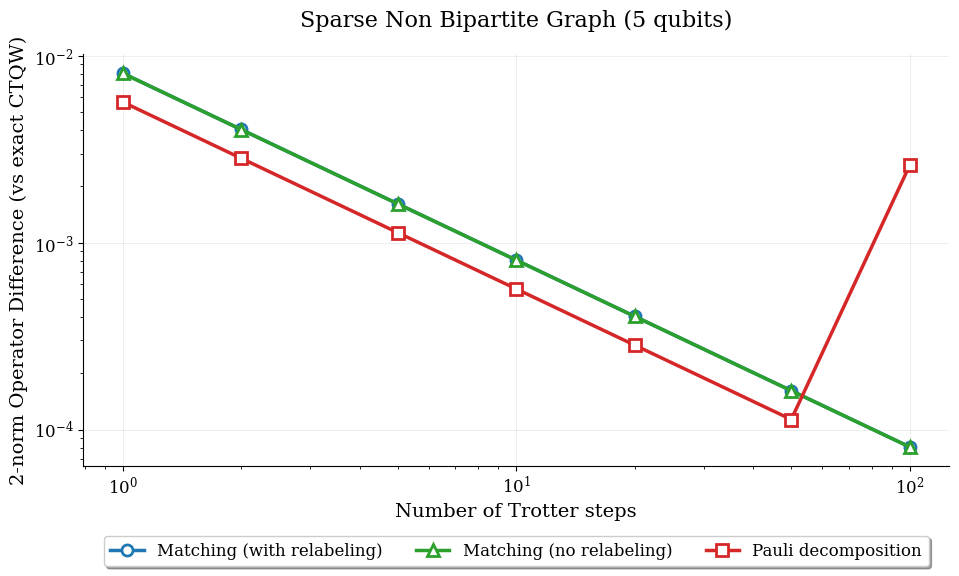

In [ ]:
sparse_nonbipartite_32 = {
    # Cluster in 0xxxx region
    ('00000','00001'),  # H=1
    ('00010','00001'),  # H=2, degree-2 at 00001
    ('00010','00011'),  # H=1, degree-2 at 00010
    ('00100','00011'),  # H=2, degree-2 at 00011
    ('00100','00101'),  # H=1, degree-2 at 00100
    ('00110','00101'),  # H=2, degree-2 at 00101
    ('01000','00111'),  # H=3, bridge
    ('01001','01011'),  # H=1, small cluster in 01xxx
    ('10000','01111'),  # H=4, high-Hamming bridge to 1xxxx
}

analyze_and_plot(sparse_nonbipartite_32, "Sparse Non Bipartite Graph (5 qubits)" )


Cayley Graph of Z2 x Z2 x Z2 (3 qubits)
Original edges: {('010', '110'), ('000', '010'), ('101', '111'), ('000', '100'), ('011', '111'), ('100', '101'), ('010', '011'), ('100', '110'), ('001', '101'), ('110', '111'), ('000', '001'), ('001', '011')}
Number of qubits: 3

Original Graph:


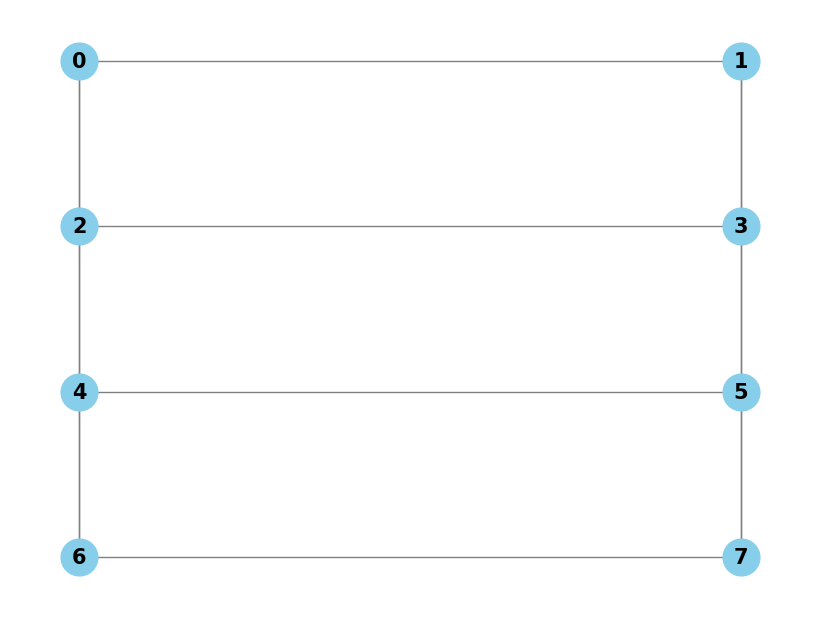

None


Matchings WITH relabeling: 3
Matchings: [{('000', '100'), ('011', '111'), ('010', '110'), ('001', '101')}, {('101', '111'), ('100', '110'), ('000', '010'), ('001', '011')}, {('000', '001'), ('100', '101'), ('010', '011'), ('110', '111')}]
Relabeled edges: {('010', '110'), ('000', '010'), ('101', '111'), ('000', '100'), ('011', '111'), ('100', '101'), ('100', '110'), ('010', '011'), ('001', '101'), ('110', '111'), ('000', '001'), ('001', '011')}

Matchings WITHOUT relabeling: 3
Matchings: [{('000', '100'), ('011', '111'), ('010', '110'), ('001', '101')}, {('101', '111'), ('100', '110'), ('000', '010'), ('001', '011')}, {('000', '001'), ('100', '101'), ('010', '011'), ('110', '111')}]
Number of qubits: 3

Hamming Cost Analysis:
With Relabeling: Total = 12, Edges = 12, Per Edge = 1.000
No Relabeling: Total = 12, Edges = 12, Per Edge = 1.000

Relabeled Graph:


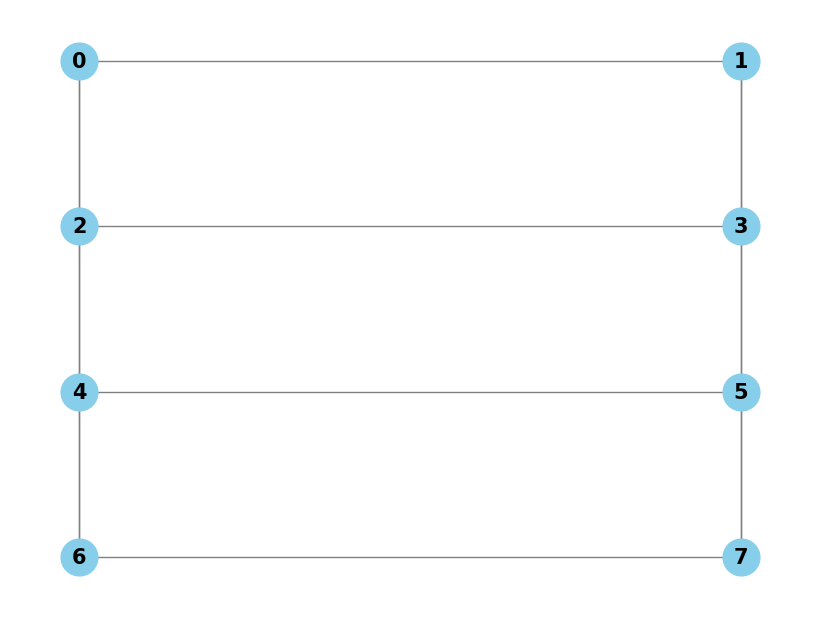

None


Sample Circuit - Matching WITH Relabeling (n_steps=1):


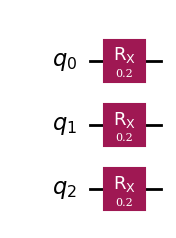


Sample Circuit - Matching WITHOUT Relabeling (n_steps=1):


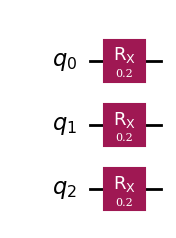


CX Gate Count Summary for Cayley Graph of Z2 x Z2 x Z2 (3 qubits):
n_steps  |   Matching w/ Relabel (No Opt/Opt)    | Matching No Relabel (No Opt/Opt)  | Pauli (No Opt/Opt) 
----------------------------------------------------------------------------------------------------
1        |    0/0                                 |    0/0                             |    0/0   
2        |    0/0                                 |    0/0                             |    0/0   
5        |    0/0                                 |    0/0                             |    0/0   
10       |    0/0                                 |    0/0                             |    0/0   
20       |    0/0                                 |    0/0                             |    0/0   
50       |    0/0                                 |    0/0                             |    0/0   
100      |    0/0                                 |    0/0                             |    0/0   
-------------------------------

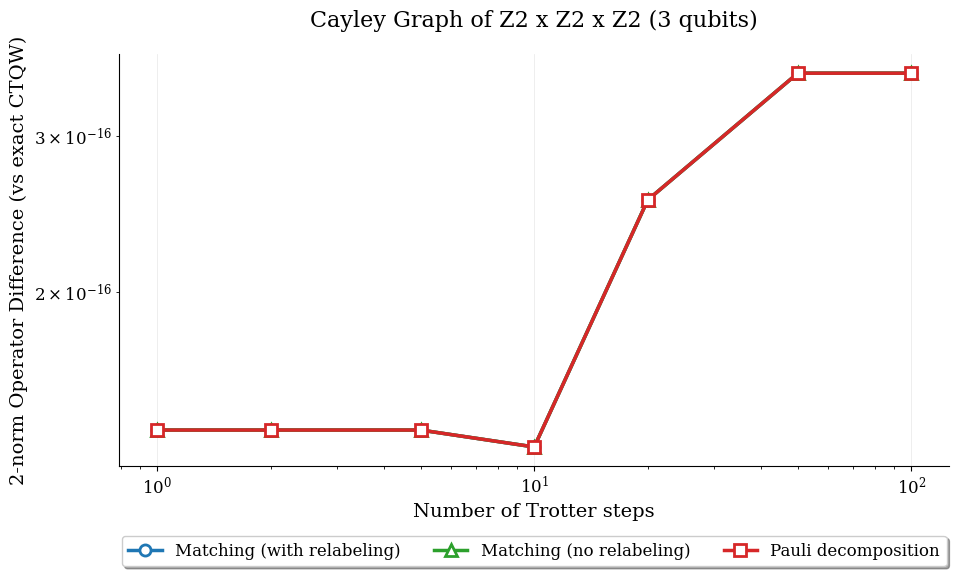

In [ ]:
cayley_8 = set()
vertices_8 = [format(i, '03b') for i in range(8)]
generators_8 = ['001', '010', '100']
for v in vertices_8:
    v_int = int(v, 2)
    for g in generators_8:
        g_int = int(g, 2)
        neighbor = format(v_int ^ g_int, '03b')
        if v < neighbor:  # Avoid duplicates
            cayley_8.add((v, neighbor))

analyze_and_plot(cayley_8, "Cayley Graph of Z2 x Z2 x Z2 (3 qubits)")


Cayley Graph of Z2 x Z2 x Z2 x Z2 (4 qubits)
Original edges: {('0101', '0111'), ('0001', '0011'), ('1001', '1101'), ('1101', '1111'), ('0110', '1110'), ('0100', '0101'), ('1100', '1110'), ('1000', '1001'), ('0001', '1001'), ('1011', '1111'), ('0111', '1111'), ('0011', '1011'), ('0000', '0010'), ('0110', '0111'), ('1000', '1100'), ('0000', '0001'), ('1100', '1101'), ('1110', '1111'), ('1000', '1010'), ('0010', '0011'), ('1010', '1110'), ('0011', '0111'), ('0100', '0110'), ('1010', '1011'), ('0010', '0110'), ('0000', '1000'), ('0100', '1100'), ('0001', '0101'), ('0101', '1101'), ('0000', '0100'), ('1001', '1011'), ('0010', '1010')}
Number of qubits: 4

Original Graph:


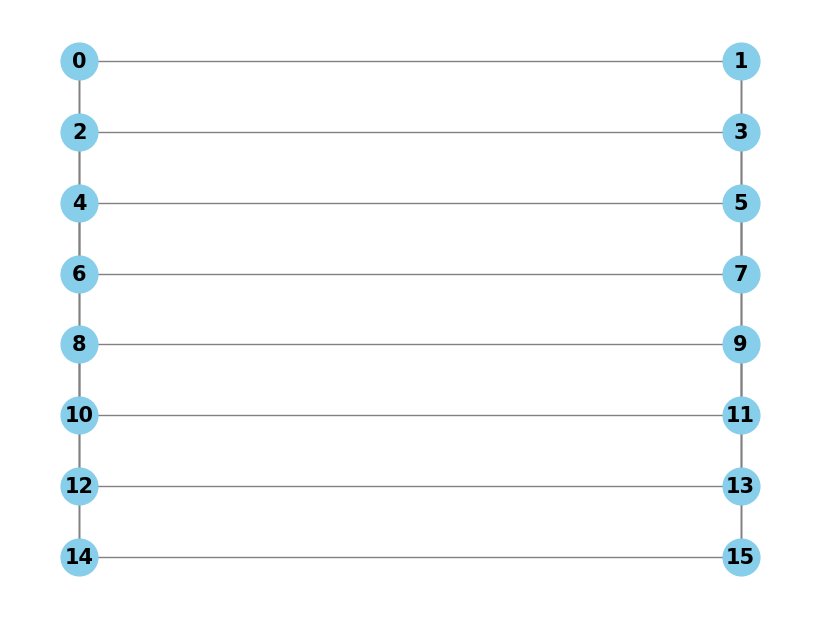

None


Matchings WITH relabeling: 4
Matchings: [{('0101', '0111'), ('1100', '1110'), ('1000', '1010'), ('0001', '0011'), ('0100', '0110'), ('1101', '1111'), ('0000', '0010'), ('1001', '1011')}, {('1011', '1111'), ('1010', '1110'), ('0011', '0111'), ('1001', '1101'), ('0001', '0101'), ('0000', '0100'), ('0010', '0110'), ('1000', '1100')}, {('0001', '1001'), ('0100', '1100'), ('0111', '1111'), ('0011', '1011'), ('0101', '1101'), ('0110', '1110'), ('0000', '1000'), ('0010', '1010')}, {('1110', '1111'), ('1000', '1001'), ('0010', '0011'), ('1010', '1011'), ('0110', '0111'), ('0000', '0001'), ('0100', '0101'), ('1100', '1101')}]
Relabeled edges: {('0101', '0111'), ('1110', '1111'), ('1000', '1010'), ('1010', '1110'), ('0010', '0011'), ('0001', '0011'), ('0011', '0111'), ('1001', '1101'), ('0100', '0110'), ('1010', '1011'), ('1101', '1111'), ('0110', '1110'), ('0010', '0110'), ('0000', '1000'), ('0100', '0101'), ('1100', '1110'), ('1000', '1001'), ('0001', '1001'), ('1011', '1111'), ('0100', '1100

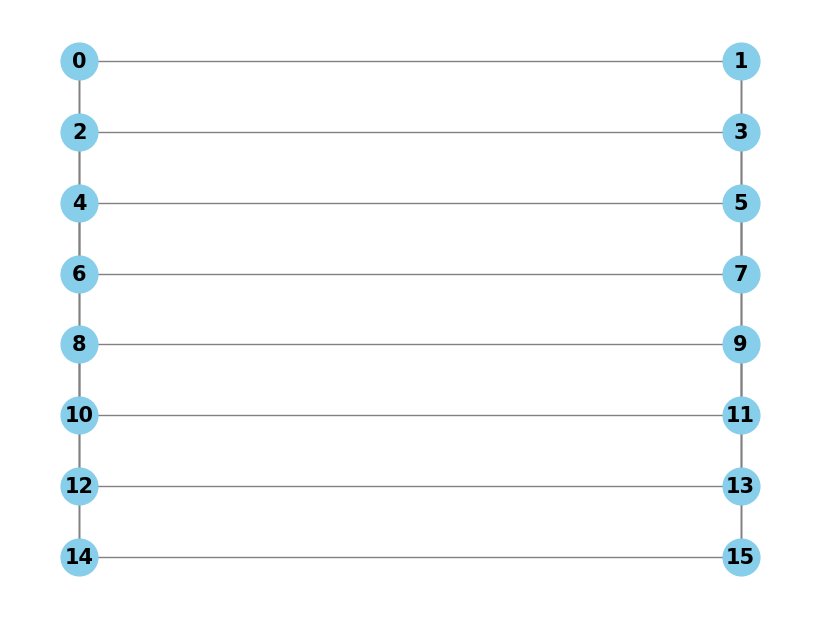

None


Sample Circuit - Matching WITH Relabeling (n_steps=1):


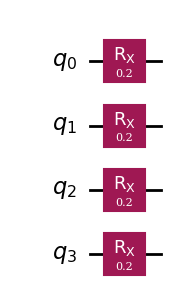


Sample Circuit - Matching WITHOUT Relabeling (n_steps=1):


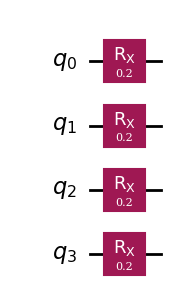


CX Gate Count Summary for Cayley Graph of Z2 x Z2 x Z2 x Z2 (4 qubits):
n_steps  |   Matching w/ Relabel (No Opt/Opt)    | Matching No Relabel (No Opt/Opt)  | Pauli (No Opt/Opt) 
----------------------------------------------------------------------------------------------------
1        |    0/0                                 |    0/0                             |    0/0   
2        |    0/0                                 |    0/0                             |    0/0   
5        |    0/0                                 |    0/0                             |    0/0   
10       |    0/0                                 |    0/0                             |    0/0   
20       |    0/0                                 |    0/0                             |    0/0   
50       |    0/0                                 |    0/0                             |    0/0   
100      |    0/0                                 |    0/0                             |    0/0   
--------------------------

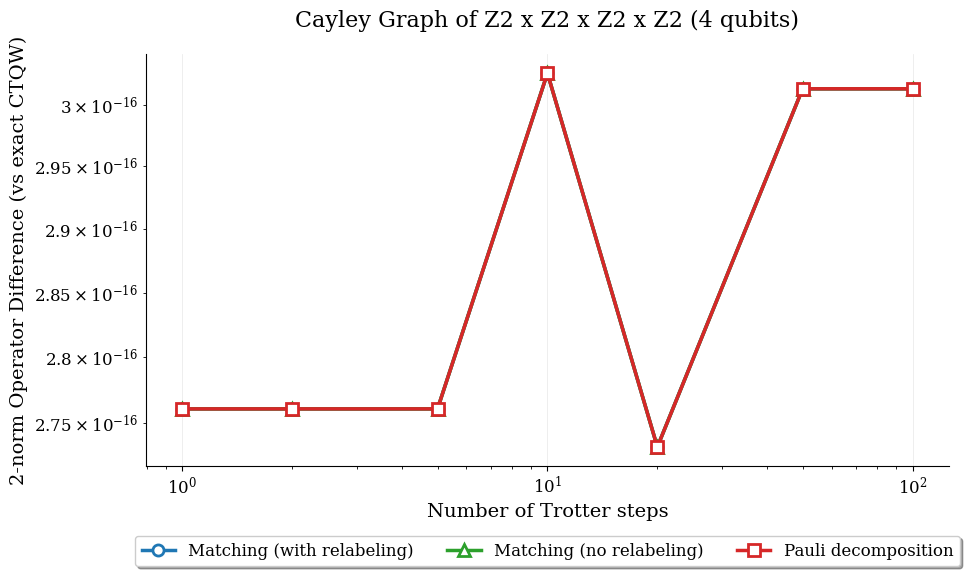

In [ ]:
cayley_16 = set()
vertices_16 = [format(i, '04b') for i in range(16)]
generators_16 = ['0001', '0010', '0100', '1000']
for v in vertices_16:
    v_int = int(v, 2)
    for g in generators_16:
        g_int = int(g, 2)
        neighbor = format(v_int ^ g_int, '04b')
        if v < neighbor:  # Avoid duplicates
            cayley_16.add((v, neighbor))
analyze_and_plot(cayley_16, "Cayley Graph of Z2 x Z2 x Z2 x Z2 (4 qubits)")


Circulant Graph C8(1,2) (3 qubits)
Original edges: {('010', '100'), ('000', '010'), ('101', '111'), ('001', '010'), ('011', '100'), ('101', '110'), ('011', '101'), ('100', '101'), ('010', '011'), ('100', '110'), ('110', '111'), ('000', '001'), ('001', '011')}
Number of qubits: 3

Original Graph:


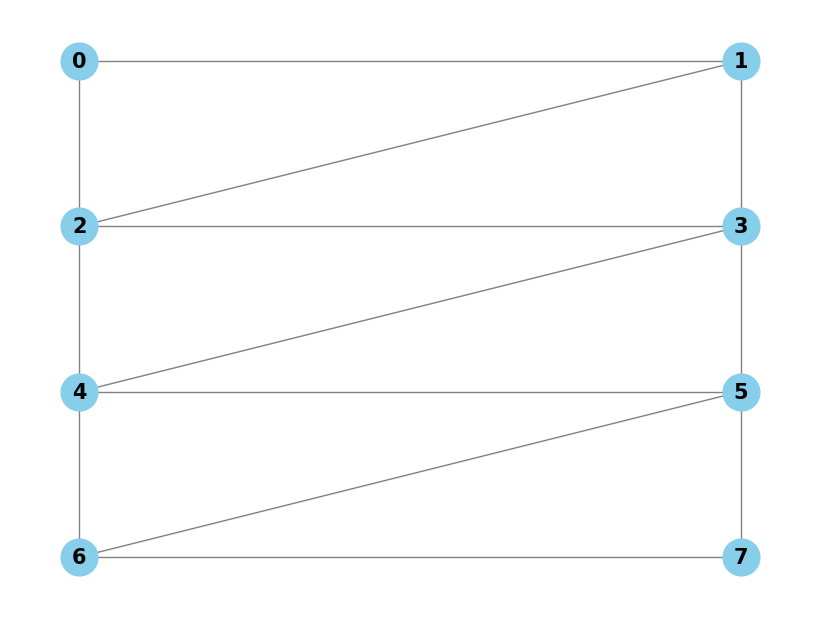

None


Matchings WITH relabeling: 5
Matchings: [{('101', '110'), ('010', '111')}, {('011', '101'), ('001', '010')}, {('110', '100'), ('001', '011'), ('000', '010'), ('111', '101')}, {('111', '110'), ('010', '011'), ('101', '100'), ('000', '001')}, {('011', '111')}]
Relabeled edges: {('111', '110'), ('000', '010'), ('111', '101'), ('101', '100'), ('011', '111'), ('001', '010'), ('101', '110'), ('011', '101'), ('010', '011'), ('000', '001'), ('110', '100'), ('001', '011'), ('010', '111')}

Matchings WITHOUT relabeling: 5
Matchings: [{('101', '110'), ('010', '100')}, {('011', '100'), ('001', '010')}, {('011', '101')}, {('101', '111'), ('100', '110'), ('000', '010'), ('001', '011')}, {('000', '001'), ('100', '101'), ('010', '011'), ('110', '111')}]
Number of qubits: 3

Hamming Cost Analysis:
With Relabeling: Total = 17, Edges = 13, Per Edge = 1.308
No Relabeling: Total = 19, Edges = 13, Per Edge = 1.462

Relabeled Graph:


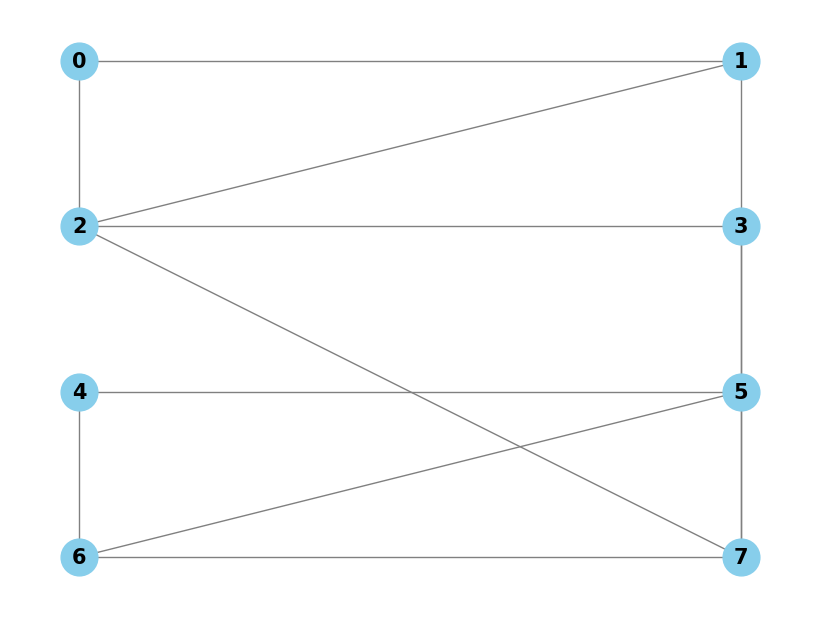

None


Sample Circuit - Matching WITH Relabeling (n_steps=1):


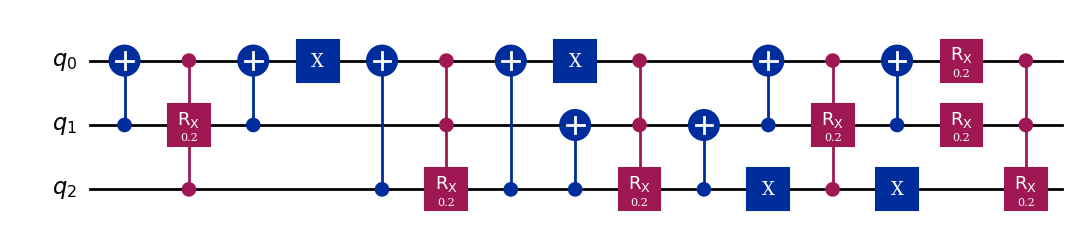


Sample Circuit - Matching WITHOUT Relabeling (n_steps=1):


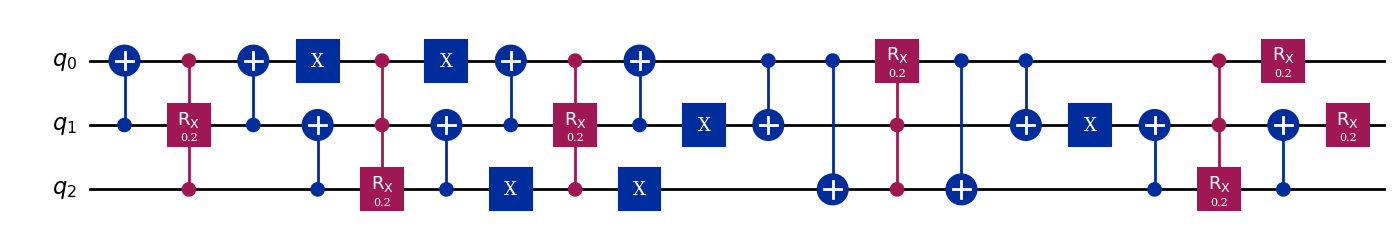


CX Gate Count Summary for Circulant Graph C8(1,2) (3 qubits):
n_steps  |   Matching w/ Relabel (No Opt/Opt)    | Matching No Relabel (No Opt/Opt)  | Pauli (No Opt/Opt) 
----------------------------------------------------------------------------------------------------
1        |   48/43                                |   52/47                            |   24/16  
2        |   96/86                                |  104/94                            |   48/32  
5        |  240/215                               |  260/235                           |  120/80  
10       |  480/430                               |  520/470                           |  240/160 
20       |  960/860                               | 1040/940                           |  480/320 
50       | 2400/2150                              | 2600/2350                          | 1200/800 
100      | 4800/4300                              | 5200/4700                          | 2400/1600
------------------------------------

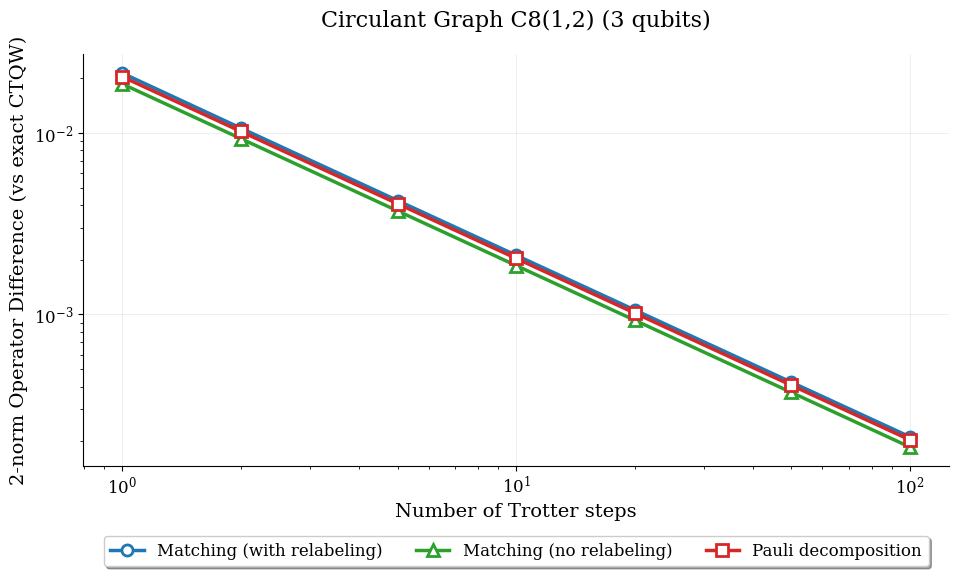

In [ ]:
circulant_8 = set()
n = 8
offsets_8 = [1, 2]
for i in range(n):
    v = format(i, '03b')
    for offset in offsets_8:
        neighbor_idx = (i + offset) % n
        neighbor = format(neighbor_idx, '03b')
        if v < neighbor:  # Avoid duplicates
            circulant_8.add((v, neighbor))
analyze_and_plot(circulant_8, "Circulant Graph C8(1,2) (3 qubits)")


Circulant Graph C16(1,3,5) (4 qubits)
Original edges: {('1010', '1111'), ('0001', '0100'), ('0101', '0110'), ('1000', '1101'), ('0001', '0110'), ('0100', '0101'), ('1000', '1001'), ('0110', '1011'), ('0010', '0101'), ('0101', '1010'), ('0011', '1000'), ('0110', '0111'), ('1011', '1100'), ('1001', '1100'), ('0000', '0001'), ('1100', '1101'), ('0111', '1100'), ('1110', '1111'), ('0011', '0100'), ('0100', '0111'), ('1001', '1010'), ('0010', '0011'), ('0111', '1010'), ('0010', '0111'), ('0001', '0010'), ('1010', '1011'), ('0110', '1001'), ('0011', '0110'), ('0100', '1001'), ('1101', '1110'), ('1100', '1111'), ('0101', '1000'), ('0000', '0101'), ('1010', '1101'), ('1011', '1110'), ('1001', '1110'), ('1000', '1011'), ('0000', '0011'), ('0111', '1000')}
Number of qubits: 4

Original Graph:


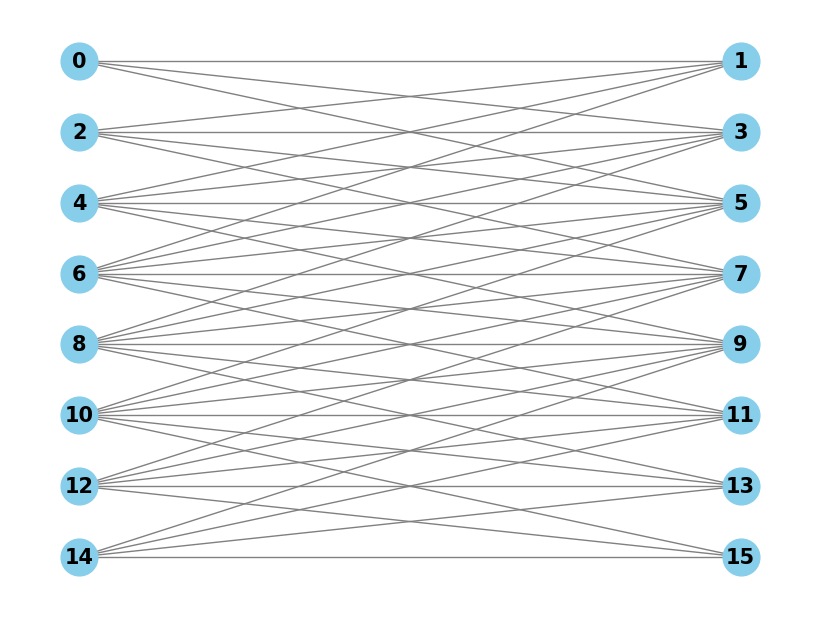

None


Matchings WITH relabeling: 9
Matchings: [{('0110', '1100'), ('0100', '0001'), ('1101', '1010'), ('1000', '0101'), ('1111', '0011'), ('1011', '0111'), ('1001', '0000')}, {('1111', '0110'), ('0101', '0000'), ('1100', '1011'), ('0010', '1000'), ('0111', '0100'), ('0011', '1001')}, {('1100', '0011'), ('1010', '0100'), ('1011', '0010'), ('0111', '1101'), ('1000', '0001')}, {('1110', '0111'), ('0011', '1010'), ('0010', '0100')}, {('0010', '1101'), ('1010', '0000'), ('0100', '1001')}, {('0110', '0010'), ('0111', '0011'), ('1101', '1001'), ('1111', '1011')}, {('1101', '0101')}, {('1110', '1111'), ('0011', '0010'), ('1011', '1010'), ('1001', '1000'), ('0110', '0111'), ('0000', '0001'), ('0100', '0101'), ('1100', '1101')}, {('1010', '1000'), ('1110', '1100')}]
Relabeled edges: {('0100', '0001'), ('0011', '0010'), ('0111', '0100'), ('0111', '1101'), ('0111', '0011'), ('1010', '0000'), ('1101', '1001'), ('1011', '0111'), ('0100', '0101'), ('0110', '0010'), ('1111', '1011'), ('0101', '0000'), ('11

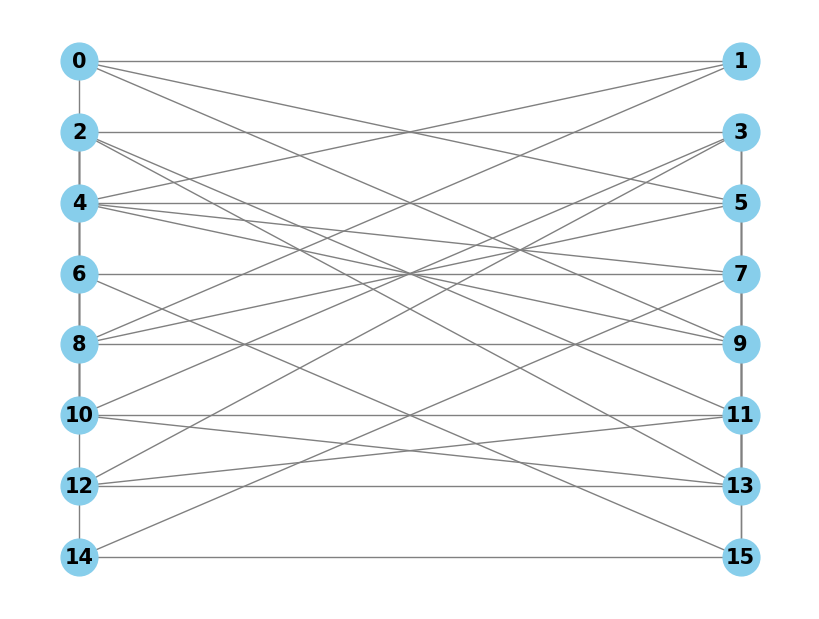

None


Sample Circuit - Matching WITH Relabeling (n_steps=1):


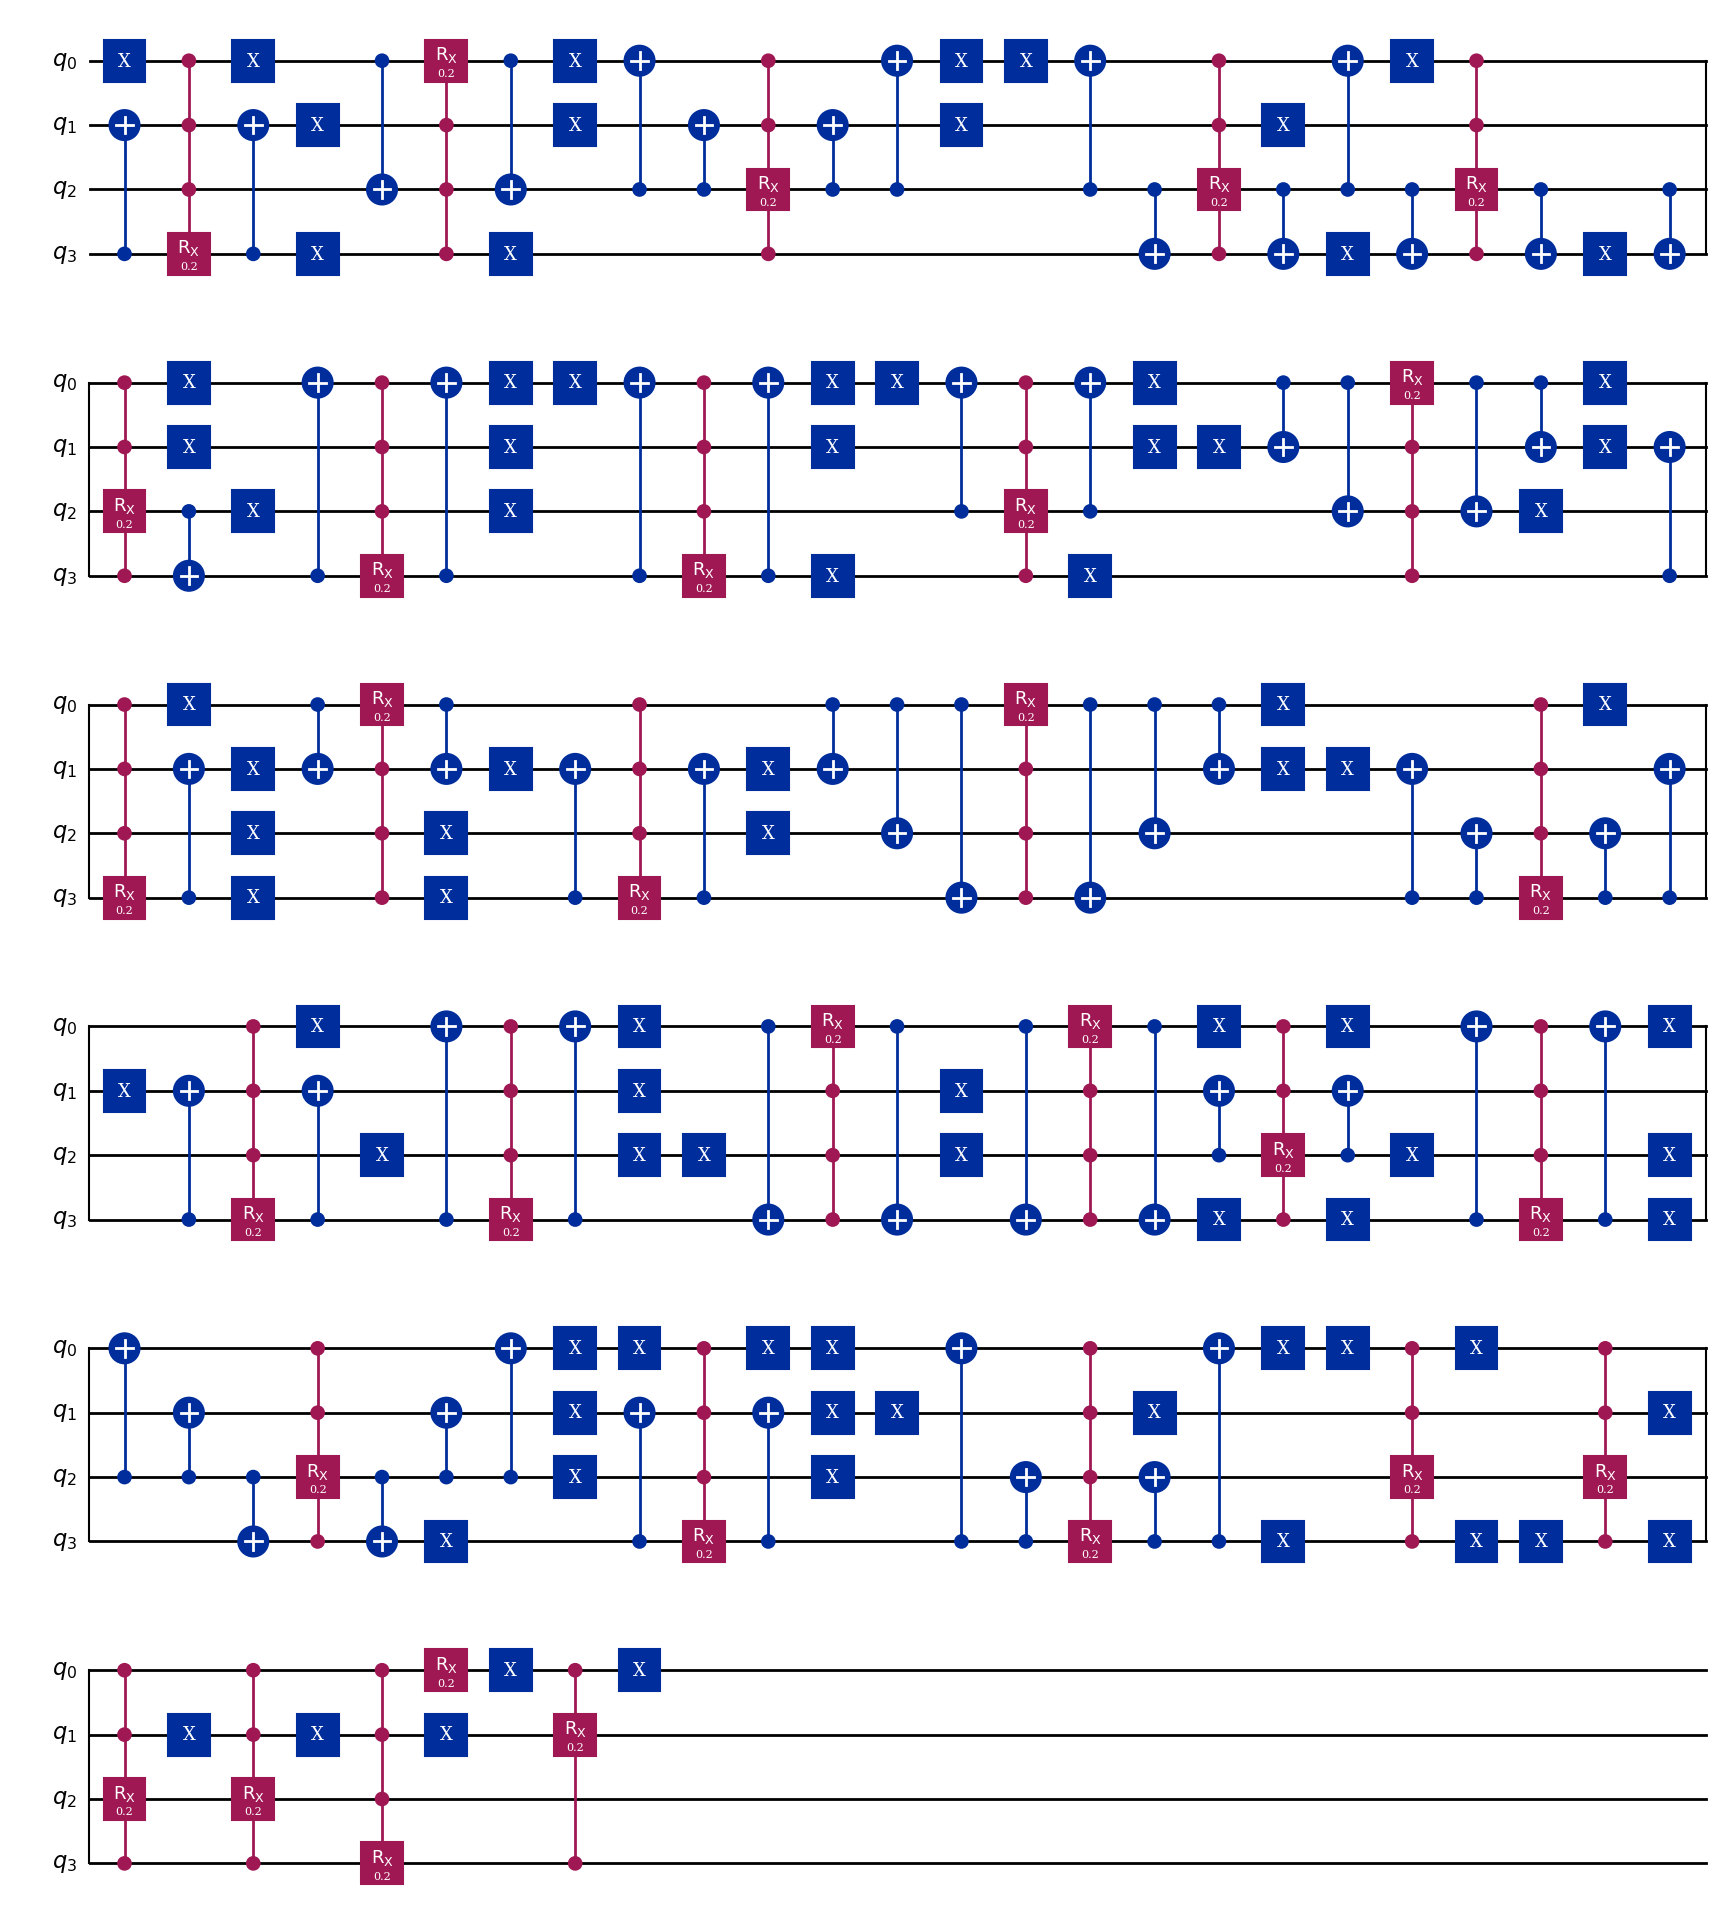


Sample Circuit - Matching WITHOUT Relabeling (n_steps=1):


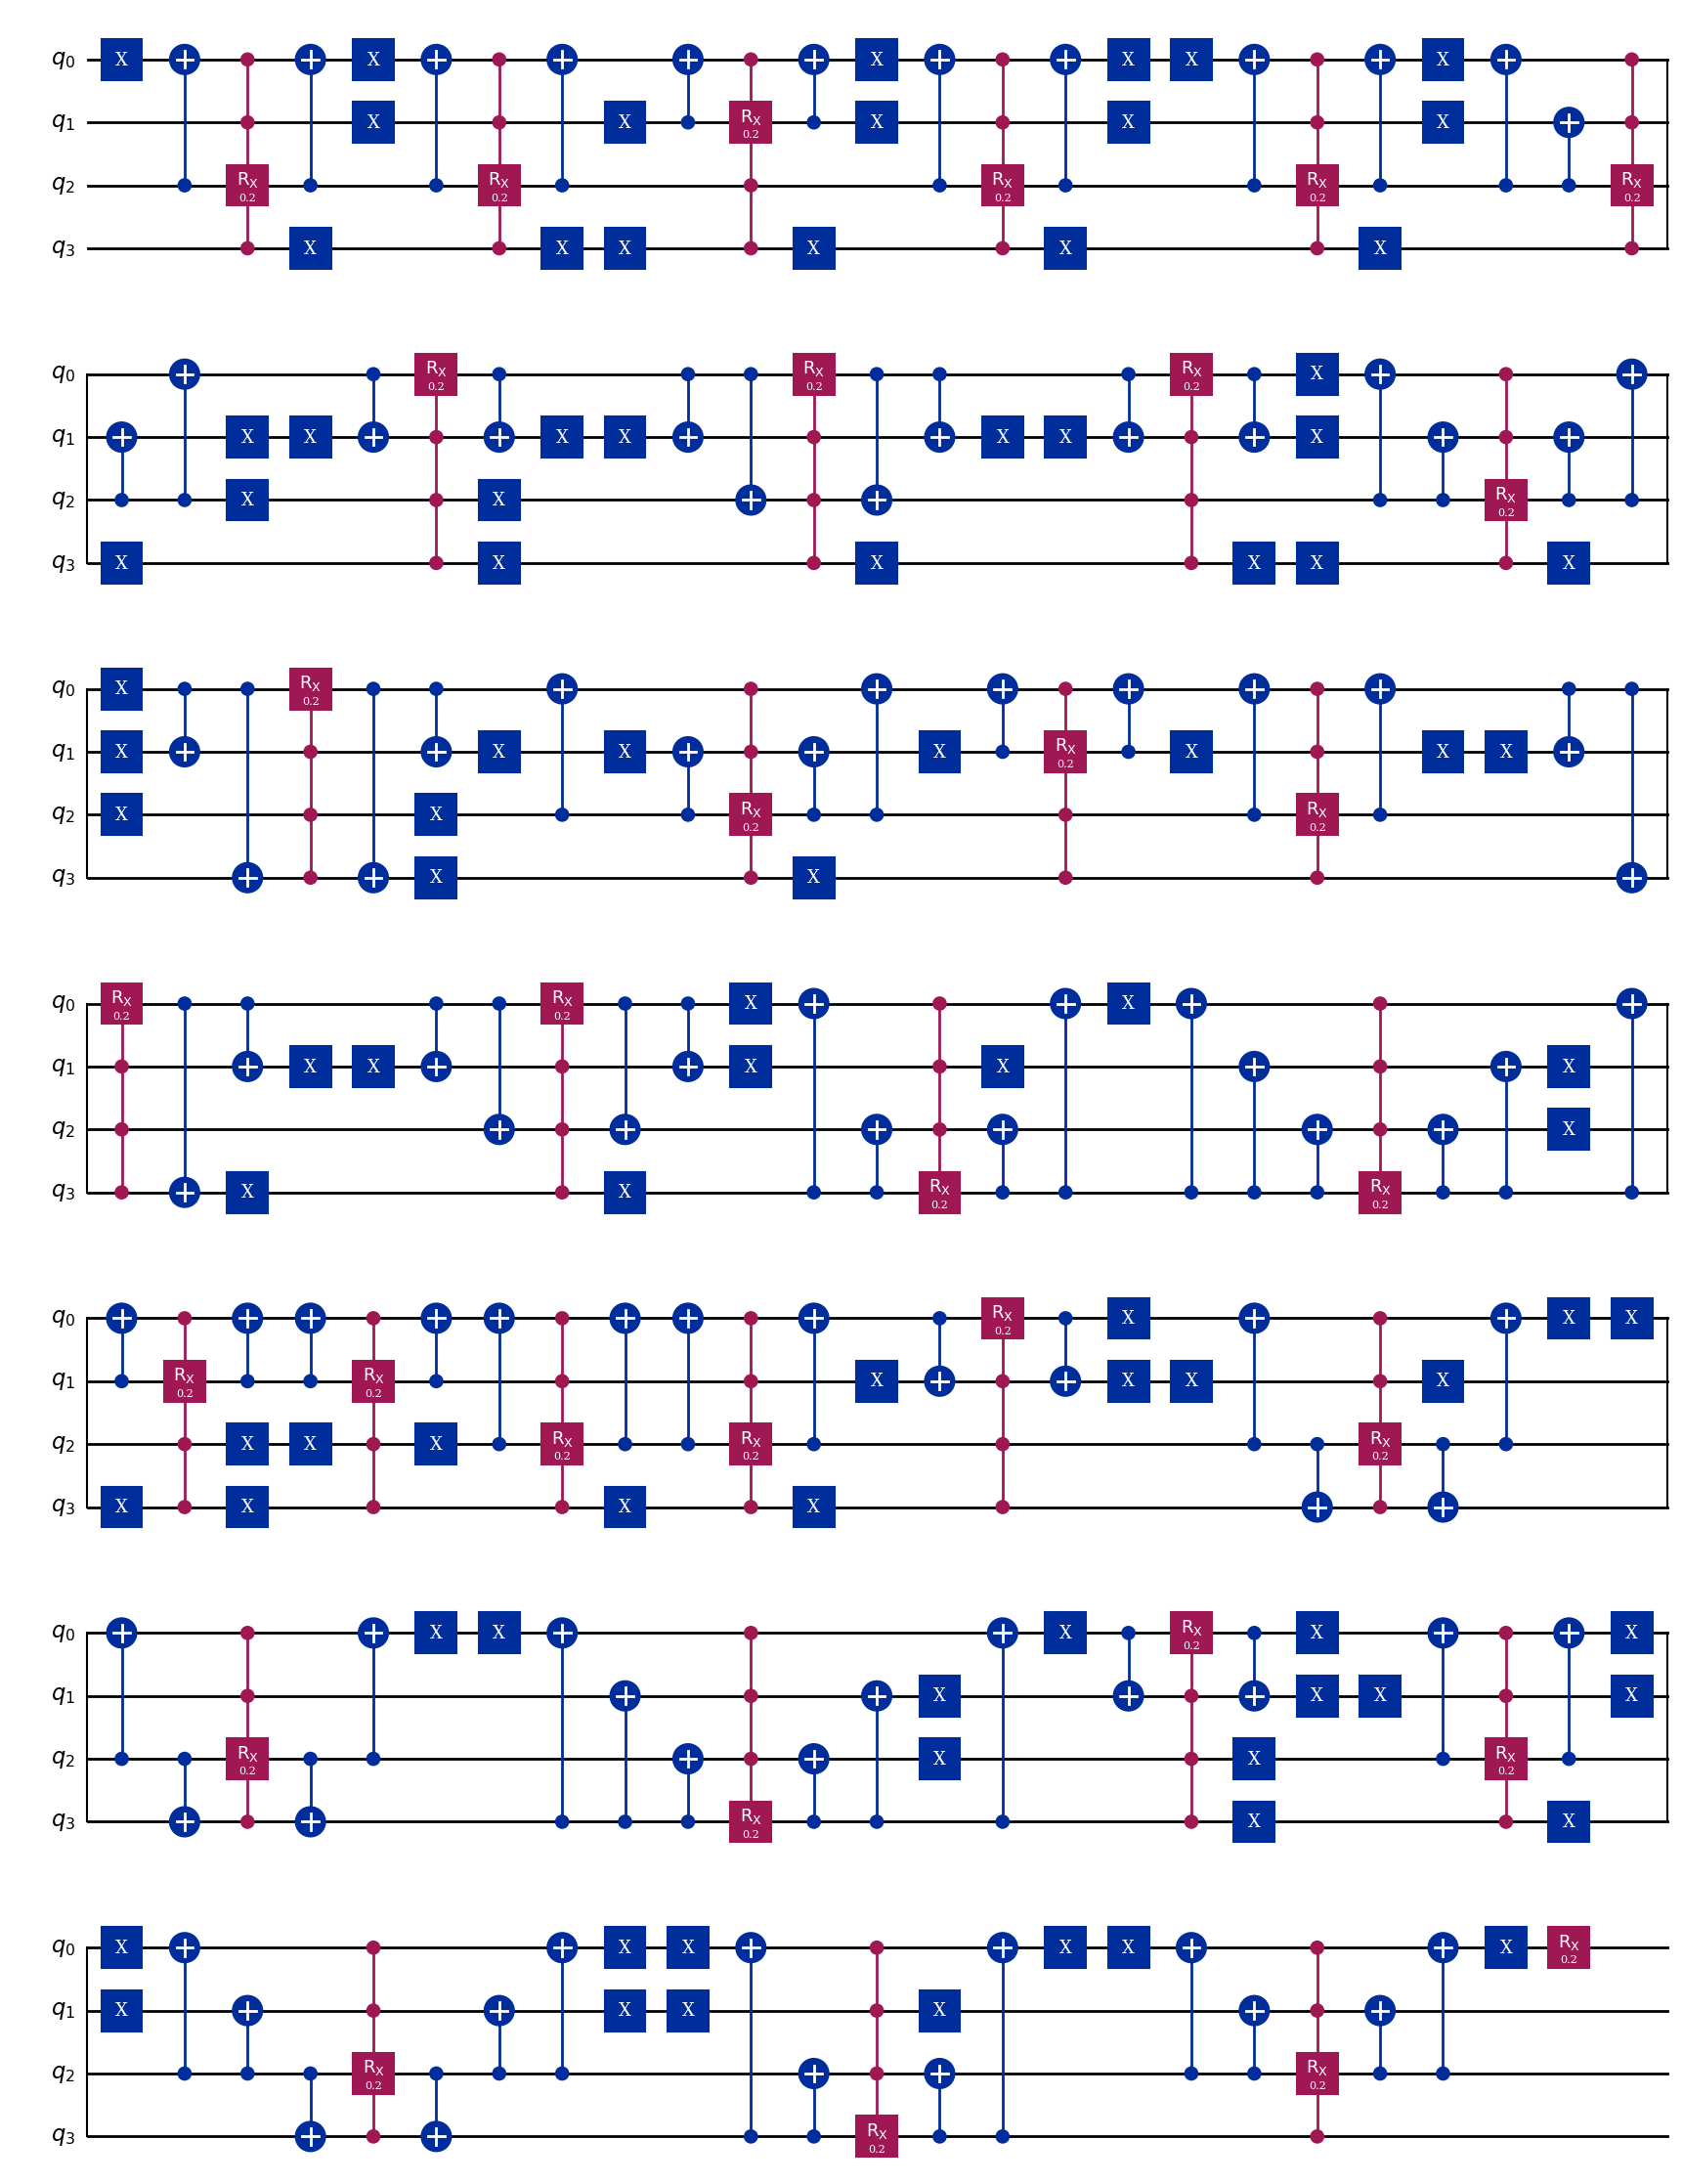


CX Gate Count Summary for Circulant Graph C16(1,3,5) (4 qubits):
n_steps  |   Matching w/ Relabel (No Opt/Opt)    | Matching No Relabel (No Opt/Opt)  | Pauli (No Opt/Opt) 
----------------------------------------------------------------------------------------------------
1        |  654/627                               |  718/674                           |   92/70  
2        | 1308/1254                              | 1436/1346                          |  184/140 
5        | 3270/3135                              | 3590/3362                          |  460/350 
10       | 6540/6270                              | 7180/6722                          |  920/700 
20       | 13080/12540                              | 14360/13442                          | 1840/1400
50       | 32700/31350                              | 35900/33602                          | 4600/3500
100      | 65400/62700                              | 71800/67202                          | 9200/7000
---------------------

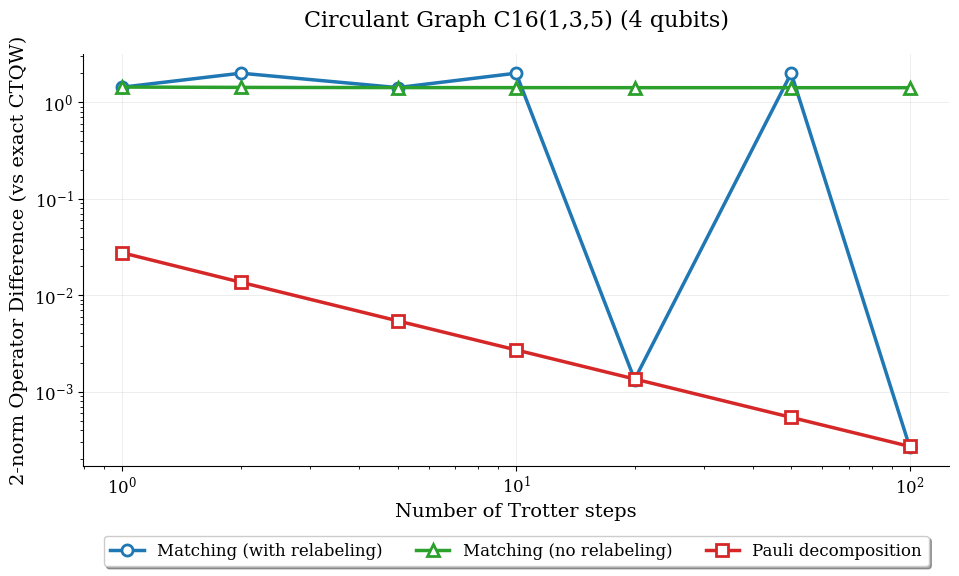

In [ ]:
circulant_16 = set()
n = 16
offsets_16 = [1, 3, 5]
for i in range(n):
    v = format(i, '04b')
    for offset in offsets_16:
        neighbor_idx = (i + offset) % n
        neighbor = format(neighbor_idx, '04b')
        if v < neighbor:  # Avoid duplicates
            circulant_16.add((v, neighbor))
analyze_and_plot(circulant_16, "Circulant Graph C16(1,3,5) (4 qubits)")